## Silver EDA (Deliverables 1.2.2 and 1.2.3)

This notebook performs data profiling, exploratory analysis, and feature behavior review on the Silver pump dataset. It focuses on comparing normal and abnormal operating behavior to understand how the sensors change around failure periods.

The key goals of this notebook are:

- To document data profiling and exploratory analysis for the Silver layer.
- To analyze feature behavior across normal and abnormal operating patterns.
- To generate supporting Silver-layer artifacts (tables, profiles, and charts) that help justify the later model design in the Gold layer.

Outputs from this notebook support the project write-up in Section C by:

- Providing evidence for the anomaly-screening approach described in C.2 and C.2.A.
- Supplying behavior profiles and feature effect-size information that are used to design the Stage 3 rule/profile/historical confirmation layer described in C.2.
- Providing visualizations that can be used in C.6 to communicate how sensor behavior differs between normal and abnormal operation.

In [1]:
print("hello")

hello


## Silver EDA Setup and Imports

In this section I am loading the libraries and project utilities needed for the Silver EDA stage.

The goal here is to get the notebook ready before I begin profiling and comparing the Silver dataset. That includes:
- standard Python libraries
- plotting libraries
- statistical helpers
- clustering and PCA tools
- project path and config utilities
- logging
- truth-record helpers
- artifact saving utilities
- experiment tracking support

At this point I am not analyzing the sensor behavior yet. I am just setting up the notebook so the rest of the exploratory work can run in a structured and repeatable way.

In [2]:
from __future__ import annotations

from dataclasses import dataclass, field
from datetime import datetime, timezone
from typing import Any, Dict, List, Optional, Sequence, Tuple, Union

from pathlib import Path
import yaml
import re

import logging
import wandb

import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 
import seaborn as sns 


from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from scipy.stats import skew as scipy_skew, kurtosis as scipy_kurtosis


import pyarrow.parquet as pq
import pyarrow as pa

import json 
import hashlib


# Custom Utilities Module
from utils.paths import get_paths
from utils.file_io import load_data, save_data, save_json, load_json
from utils.eda_logging import profile_dataframe
from utils.logging_setup import configure_logging, log_layer_paths
from utils.wandb_utils import finalize_wandb_stage

from utils.truths import (
    make_process_run_id,
    build_file_fingerprint,
    extract_truth_hash,
    identify_meta_columns,
    identify_feature_columns,
    initialize_layer_truth,
    update_truth_section,
    build_truth_record,
    save_truth_record,
    append_truth_index,
    stamp_truth_columns,
    load_truth_record,
    find_truth_record_by_hash,
    load_truth_record_by_hash,
    load_parent_truth_record_from_dataframe,
    get_truth_value,
    get_dataset_name_from_truth,
    get_truth_hash,
    get_parent_truth_hash,
    get_pipeline_mode_from_truth,
    get_artifact_path_from_truth,
)

from utils.pipeline_config_loader import (
    load_pipeline_config,
    build_truth_config_block,
    set_wandb_dir_from_config,
    export_config_snapshot,
)

from utils.postgres_util import get_engine_from_env
from utils.layer_postgres_writer import write_layer_dataframe, prepare_layer_dataframe


# Ledger 
from utils.ledger import Ledger

# Show more columns
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)



----

## Define a Simple Z-Score Helper for Plotting

This helper function standardizes a numeric series into z-score form.

I use this mainly for plotting and comparison work later in the notebook. The point is not to permanently transform the Silver dataset here. The point is to make different sensor series easier to compare on the same chart when their raw scales are very different.

In [3]:
def z_score(series: pd.Series) -> pd.Series:
    """
    Z-score normalize a numeric pandas Series.
    Returns a Series with the same index.
    If std is 0 or NaN (constant series), returns series - mean.
    """
    # Ensure Series is a float type
    series = series.astype(float)

    # Use nan-safe stats in case any NaNs sneak in
    mean_value = np.nanmean(series.to_numpy())
    std_value = np.nanstd(series.to_numpy())

    
    if std_value == 0 or np.isnan(std_value):
        # Make all values (effectively) the same or center only
        return pd.Series(
            np.where(series.notna(), 0.0, np.nan),
            index=series.index
        )
    
    return (series - mean_value) / std_value



----

## Load Paths, Configuration, and Runtime Settings

Here I load the resolved paths and configuration values that control how the Silver EDA notebook runs.

This step defines the main runtime context for the notebook, including:
- project folders
- Silver EDA version information
- cleaning recipe ID
- truth-store locations
- dataset identity placeholders
- artifact output folders
- runtime settings for plotting and analysis

I like doing this near the top because it keeps the rest of the notebook cleaner. Instead of hard-coding file paths and settings throughout the workflow, I define them once here and reuse them later.

In [4]:
paths = get_paths()

#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 

CONFIG_ROOT = paths.configs

#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 

CONFIG_RUN_MODE = "train"
CONFIG_PROFILE = "default"

#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### ####  

CONFIG = load_pipeline_config(
    config_root=CONFIG_ROOT,
    stage="silver_eda",
    dataset="pump",
    mode=CONFIG_RUN_MODE,
    profile=CONFIG_PROFILE,
    project_root=paths.root,
).data

#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### ####  

SILVER_EDA_CFG = CONFIG["silver_eda"]
PATHS = CONFIG["resolved_paths"]
FILENAMES = CONFIG["filenames"]
PIPELINE = CONFIG.get(
    "pipeline",
    {
        "execution_mode": "batch",
        "orchestration_mode": "notebook",
    },
)

#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### ####  

TRUTH_CONFIG = build_truth_config_block(CONFIG)
TRUTH_CONFIG["pipeline"] = PIPELINE

#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### ####  

# ---- Stage details ----
STAGE = "silver_eda"
LAYER_NAME = SILVER_EDA_CFG["layer_name"]
SILVER_VERSION = CONFIG["versions"]["silver_eda"]
CLEANING_RECIPE_ID = SILVER_EDA_CFG["cleaning_recipe_id"]
TRUTH_VERSION = CONFIG["versions"]["truth"]

PIPELINE_MODE = PIPELINE["execution_mode"]
RUN_MODE = CONFIG["runtime"]["mode"]

DATASET_NAME_CONFIG = CONFIG["dataset"]["name"]
DATASET_NAME = None

SILVER_TRUTH_HASH = None
SILVER_PARENT_TRUTH_HASH = None
SILVER_TRUTH_PATH = None
SILVER_PARENT_TRUTH_PATH = None
SILVER_PARENT_LAYER_NAME = "silver"

LABEL_SOURCE_COLUMN = None
LABEL_SOURCE_TYPE = None
LABEL_SOURCE_INFO = {}
CANONICAL_INFO = {}
FEATURE_SET_INFO = {}
QUALITY_INFO = {}
NEEDS_ONE_HOT_ENCODING = None
ONE_HOT_ENCODING_COLUMNS = []

#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### ####  

SILVER_PROCESS_RUN_ID = make_process_run_id(SILVER_EDA_CFG["process_run_id_prefix"])

# ---- W&B ----
WANDB_PROJECT = CONFIG["wandb"]["project"]
WANDB_ENTITY = CONFIG["wandb"]["entity"]
WANDB_RUN_NAME = f"{SILVER_VERSION}"

#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### ####  

# Thresholds
MIN_TIME_PARSE_SUCCESS_PERCENT = float(SILVER_EDA_CFG["min_time_parse_success_percent"])
MIN_STEP_PARSE_SUCCESS_PERCENT = float(SILVER_EDA_CFG["min_step_parse_success_percent"])

QUARANTINE_MISSING_PCT = float(SILVER_EDA_CFG["quarantine_missing_pct"])
CORRELATION_THRESHOLD = float(SILVER_EDA_CFG["correlation_threshold"])

USE_ROBUST_SCALER = bool(SILVER_EDA_CFG["use_robust_scaler"])

TOP_N_SENSORS_FOR_PLOTS = int(SILVER_EDA_CFG["top_n_sensors_for_plots"])
PAIRPLOT_SENSOR_CAP = int(SILVER_EDA_CFG["pairplot_sensor_cap"])
PAIRPLOT_SAMPLE_N = int(SILVER_EDA_CFG["pairplot_sample_n"])
TOP_PLOT_COLS = int(SILVER_EDA_CFG["top_plot_cols"])
TOP_CORR_COLS = int(SILVER_EDA_CFG["top_corr_cols"])

ROLLING_MINUTES = int(SILVER_EDA_CFG["rolling_minutes"])
LOOKBACK_HOURS = int(SILVER_EDA_CFG["lookback_hours"])
BASELINE_DAYS = int(SILVER_EDA_CFG["baseline_days"])
BASELINE_GAP_HOURS = int(SILVER_EDA_CFG["baseline_gap_hours"])
SUSTAIN_MINUTES = int(SILVER_EDA_CFG["sustain_minutes"])
TOP_SENSOR_PRE_HOURS = int(SILVER_EDA_CFG["top_sensor_pre_hours"])

PRE_WINDOW_STEPS = int(SILVER_EDA_CFG["pre_window_steps"])
POST_WINDOW_STEPS = int(SILVER_EDA_CFG["post_window_steps"])
MAX_ONSETS_TO_USE = int(SILVER_EDA_CFG["max_onsets_to_use"])
PCA_SAMPLE_ROW_COUNT = int(SILVER_EDA_CFG["pca_sample_row_count"])
IMPUTE_SAMPLE_ROW_COUNT = int(SILVER_EDA_CFG["impute_sample_row_count"])

#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### ####  

# ---- File names ----
BRONZE_TRAIN_DATA_FILE_NAME = FILENAMES["bronze_train_file_name"]
SILVER_TRAIN_DATA_FILE_NAME = FILENAMES["silver_train_file_name"]

FEATURE_REGISTRY_FILE_NAME = None
FEATURE_REGISTRY_PATH = None

# ---- Paths setup ----
BRONZE_TRAIN_DATA_PATH = Path(PATHS["data_bronze_train_dir"])
SILVER_TRAIN_DATA_PATH = Path(PATHS["data_silver_train_dir"])

SILVER_ARTIFACTS_PATH = Path(PATHS["artifacts_root"]) / "silver"
SILVER_EDA_ARTIFACTS_ROOT = Path(PATHS["artifacts_root"]) / "silver_eda"
SILVER_EDA_ARTIFACTS_PATH = None

ARTIFACTS_PATH = Path(PATHS["artifacts_root"])

TRUTHS_PATH = Path(PATHS["truths_dir"])
TRUTH_INDEX_PATH = Path(PATHS["truth_index_path"])

LOGS_PATH = Path(PATHS["logs_root"])

#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### ####  

required_columns = [
    "anomaly_flag",
    "event_step",
    "time_index",
    "meta__asset_id",
    "meta__run_id",
]

set_wandb_dir_from_config(CONFIG)

SILVER_TRAIN_DATA_PATH.mkdir(parents=True, exist_ok=True)
SILVER_ARTIFACTS_PATH.mkdir(parents=True, exist_ok=True)
SILVER_EDA_ARTIFACTS_ROOT.mkdir(parents=True, exist_ok=True)
TRUTHS_PATH.mkdir(parents=True, exist_ok=True)
LOGS_PATH.mkdir(parents=True, exist_ok=True)

----

## Start Logging for the Silver EDA Stage

Before I load the data, I want logging turned on so this notebook records what happened during the run.

This helps with debugging, traceability, and project discipline. If I need to confirm which input file was used or where a later step failed, the log gives me a cleaner record than notebook output alone.

In [5]:
# Logging Setup

# Create silver log path 
silver_log_path = paths.logs / "silver_eda.log"

# Initial Logger
configure_logging(
    "capstone",
    silver_log_path,
    level=logging.DEBUG,
    overwrite_handlers=True,
)

# Initiate Logger and log file
logger = logging.getLogger("capstone.silver_eda")

# Log load and initiation
logger.info("Silver EDA stage starting")

# Log paths loads
log_layer_paths(paths, current_layer="silver", logger=logger)


2026-03-22 07:47:26,517 | INFO | capstone.silver_eda | Silver EDA stage starting
2026-03-22 07:47:26,518 | INFO | capstone.silver_eda | Project Root Path Loaded: /workspace
2026-03-22 07:47:26,520 | INFO | capstone.silver_eda | Project Logging Path Loaded: /workspace/logs
2026-03-22 07:47:26,521 | INFO | capstone.silver_eda | Project Artifacts Path Loaded: /workspace/artifacts
2026-03-22 07:47:26,524 | INFO | capstone.silver_eda | Project Notebooks Path Loaded: /workspace/notebooks
2026-03-22 07:47:26,525 | INFO | capstone.silver_eda | Project Truths Path Loaded: /workspace/artifacts/truths
2026-03-22 07:47:26,527 | INFO | capstone.silver_eda | Project Data Path Loaded: /workspace/data
2026-03-22 07:47:26,529 | INFO | capstone.silver_eda | Previous Layer (Bronze) Path Loaded: /workspace/data/bronze
2026-03-22 07:47:26,530 | INFO | capstone.silver_eda | Previous Layer (Bronze) Training Path Loaded: /workspace/data/bronze/train
2026-03-22 07:47:26,532 | INFO | capstone.silver_eda | Previ

----

## Initialize Experiment Tracking

This step starts the Weights & Biases run for the Silver EDA stage.

I am using this mainly for run tracking and artifact registration. It helps document the notebook settings and saved outputs, but it does not change the exploratory logic itself.

In [6]:
# W&B

wandb_run = wandb.init(
    project=WANDB_PROJECT,
    entity=WANDB_ENTITY,
    name=WANDB_RUN_NAME,
    job_type="silver_eda",
    config={
        "silver_version": SILVER_VERSION,
        "cleaning_recipe_id": CLEANING_RECIPE_ID,
        "quarantine_missing_pct": QUARANTINE_MISSING_PCT,
        "min_time_parse_success_percent": MIN_TIME_PARSE_SUCCESS_PERCENT,
        "rolling_window": ROLLING_MINUTES,
        "silver_path": str(SILVER_TRAIN_DATA_PATH / SILVER_TRAIN_DATA_FILE_NAME),
        "silver_out_dir": str(SILVER_TRAIN_DATA_PATH),
    },
)
logger.info("W&B initialized: %s", wandb.run.name)


wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: dcoo230 (dcoo230-western-governors-university). Use `wandb login --relogin` to force relogin


2026-03-22 07:47:30,719 | INFO | capstone.silver_eda | W&B initialized: silver_eda__001


----

## Initialize the Silver EDA Ledger

Here I create the ledger that tracks the main steps taken during the Silver EDA notebook.

I treat the ledger as a structured run record. It gives me a cleaner summary of the exploratory workflow than relying only on printed notebook output, especially when I need to review or reference the notebook later.

In [7]:
# Ledger Setup

ledger = Ledger(stage=STAGE, recipe_id=CLEANING_RECIPE_ID)

ledger.add(
    kind="step",
    step="init",
    message="Initialized ledger",
    logger=logger
)


2026-03-22 07:47:31,221 | INFO | capstone.silver_eda | LEDGER | {'ts_utc': '2026-03-22T07:47:31.221004+00:00', 'stage': 'silver_eda', 'recipe': 'silver_eda__v001', 'kind': 'step', 'step': 'init', 'message': 'Initialized ledger', 'why': None, 'consequence': None, 'data': {}}


{'ts_utc': '2026-03-22T07:47:31.221004+00:00',
 'stage': 'silver_eda',
 'recipe': 'silver_eda__v001',
 'kind': 'step',
 'step': 'init',
 'message': 'Initialized ledger',
 'why': None,
 'consequence': None,
 'data': {}}

----

## Load the Silver Dataset for Exploratory Review

This is the point where I load the Silver dataset that came out of the earlier Silver preprocessing work.

The purpose of this notebook is not to rebuild Silver preprocessing. It is to inspect the resulting Silver data more closely so I can understand:
- overall structure
- missingness
- duplicate risk
- state behavior
- feature movement between normal and abnormal periods
- correlation and grouping patterns
- artifacts that may support later Gold modeling decisions

In [8]:

# Load Data

preferred_silver = SILVER_TRAIN_DATA_PATH / SILVER_TRAIN_DATA_FILE_NAME

if preferred_silver.exists():
    silver_data_path = preferred_silver
else:
    parquet_files = sorted(SILVER_TRAIN_DATA_PATH.glob("*.parquet"))
    if len(parquet_files) == 0:
        raise FileNotFoundError(f"No parquet files found in {SILVER_TRAIN_DATA_PATH}")
    if len(parquet_files) > 1: 
        logger.warning("Multiple Parquet Files found; Using First %s", parquet_files[0])
    silver_data_path = parquet_files[0]

if not silver_data_path.exists():
    raise FileNotFoundError(f"Silver parquet not found: {silver_data_path}")
    
dataframe = load_data(silver_data_path.parent, silver_data_path.name)



#### #### #### #### #### #### #### #### 

logger.info("Loaded Silver: %s | shape=%s", silver_data_path, dataframe.shape)
wandb_run.log({"silver_rows": int(dataframe.shape[0]), "silver_cols": int(dataframe.shape[1])})

ledger.add(
    kind="step",
    step="load_silver",
    message="Loaded Silver Parquet",
    why="Silver must be derived from reprodicible Silver Artifact",
    consequence="All silver outputs trace back to this file",
    data={"silver_path": str(silver_data_path), "shape": list(dataframe.shape), "cols": len(dataframe.columns)},
    logger=logger
)


#### #### #### #### #### #### #### #### 

display(dataframe.head(3))

2026-03-22 07:47:31,687 | INFO | capstone.file_io | Loading Parquet: /workspace/data/silver/train/pump__silver__train.parquet


2026-03-22 07:47:32,642 | INFO | capstone.silver_eda | Loaded Silver: /workspace/data/silver/train/pump__silver__train.parquet | shape=(220320, 73)
2026-03-22 07:47:32,644 | INFO | capstone.silver_eda | LEDGER | {'ts_utc': '2026-03-22T07:47:32.644741+00:00', 'stage': 'silver_eda', 'recipe': 'silver_eda__v001', 'kind': 'step', 'step': 'load_silver', 'message': 'Loaded Silver Parquet', 'why': 'Silver must be derived from reprodicible Silver Artifact', 'consequence': 'All silver outputs trace back to this file', 'data': {'silver_path': '/workspace/data/silver/train/pump__silver__train.parquet', 'shape': [220320, 73], 'cols': 73}}


,meta__asset_id,meta__dataset,meta__episode_id,meta__event_id,meta__ingested_at_utc,meta__parent_truth_hash,meta__pipeline_mode,meta__record_id,meta__run_id,meta__source_file,meta__source_row_id,meta__split,meta__truth_hash,event_time,event_step,time_index,event_date,anomaly_flag,is_anomaly,is_normal,status_normal_value,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,sensor_08,sensor_09,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,sensor_22,sensor_23,sensor_24,sensor_25,sensor_26,sensor_27,sensor_28,sensor_29,sensor_30,sensor_31,sensor_32,sensor_33,sensor_34,sensor_35,sensor_36,sensor_37,sensor_38,sensor_39,sensor_40,sensor_41,sensor_42,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_51,timestamp,machine_status
0,asset__001,pump,0,pump:asset__001:run__001:0,2026-03-22 00:55:01.594555+00:00,2b8644b616dda6148777160805e0e8cfba5a2aaf08fc56...,batch,14598431322315673869,run__001,sensor.csv,0,unsplit,150ec91684fac04d2ee1c41c1b9297bde4fcd92fa30a2f...,2018-04-01 00:00:00+00:00,0,0,2018-04-01 00:00:00+00:00,0,0,1,NORMAL,2.465394,47.09201,53.2118,46.31076,634.3750,76.45975,13.41146,16.13136,15.56713,15.05353,37.22740,47.52422,31.11716,1.681353,419.5747,461.8781,466.3284,2.565284,665.3993,398.9862,880.0001,498.8926,975.9409,627.6740,741.7151,848.0708,429.0377,785.1935,684.9443,594.4445,682.8125,680.4416,433.7037,171.9375,341.9039,195.0655,90.32386,40.36458,31.51042,70.57291,30.98958,31.770832,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,201.3889,2018-04-01 00:00:00,NORMAL
1,asset__001,pump,0,pump:asset__001:run__001:1,2026-03-22 00:55:01.594555+00:00,2b8644b616dda6148777160805e0e8cfba5a2aaf08fc56...,batch,15954729095895098000,run__001,sensor.csv,1,unsplit,150ec91684fac04d2ee1c41c1b9297bde4fcd92fa30a2f...,2018-04-01 00:01:00+00:00,1,1,2018-04-01 00:00:00+00:00,0,0,1,NORMAL,2.465394,47.09201,53.2118,46.31076,634.3750,76.45975,13.41146,16.13136,15.56713,15.05353,37.22740,47.52422,31.11716,1.681353,419.5747,461.8781,466.3284,2.565284,665.3993,398.9862,880.0001,498.8926,975.9409,627.6740,741.7151,848.0708,429.0377,785.1935,684.9443,594.4445,682.8125,680.4416,433.7037,171.9375,341.9039,195.0655,90.32386,40.36458,31.51042,70.57291,30.98958,31.770832,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,201.3889,2018-04-01 00:01:00,NORMAL
2,asset__001,pump,0,pump:asset__001:run__001:2,2026-03-22 00:55:01.594555+00:00,2b8644b616dda6148777160805e0e8cfba5a2aaf08fc56...,batch,10041703297090838359,run__001,sensor.csv,2,unsplit,150ec91684fac04d2ee1c41c1b9297bde4fcd92fa30a2f...,2018-04-01 00:02:00+00:00,2,2,2018-04-01 00:00:00+00:00,0,0,1,NORMAL,2.444734,47.35243,53.2118,46.39757,638.8889,73.54598,13.32465,16.03733,15.61777,15.01013,37.86777,48.17723,32.08894,1.708474,420.8480,462.7798,459.6364,2.500062,666.2234,399.9418,880.4237,501.3617,982.7342,631.1326,740.8031,849.8997,454.2390,778.5734,715.6266,661.5740,721.8750,694.7721,441.2635,169.9820,343.1955,200.9694,93.90508,41.40625,31.25000,69.53125,30.46875,31.770830,41.66666,39.351852,65.39352,51.21528,38.194443,155.9606,67.12963,203.7037,2018-04-01 00:02:00,NORMAL


----

## Initial Structural Review of the Silver Dataset

Before I start producing deeper artifacts, I want a first look at the Silver dataframe as it enters this notebook.

At this stage I am checking:
- shape
- column types
- general dataframe structure
- a quick numeric summary

This is not the deep interpretation step yet. It is more of a first trust check to make sure the Silver handoff looks usable before I move into profiling and EDA.

In [9]:
print("Silver training shape:", dataframe.shape)
dataframe.info()
display(dataframe.describe().T.head(10))

Silver training shape: (220320, 73)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220320 entries, 0 to 220319
Data columns (total 73 columns):
 #   Column                   Non-Null Count   Dtype              
---  ------                   --------------   -----              
 0   meta__asset_id           220320 non-null  object             
 1   meta__dataset            220320 non-null  category           
 2   meta__episode_id         220320 non-null  int64              
 3   meta__event_id           220320 non-null  object             
 4   meta__ingested_at_utc    220320 non-null  datetime64[us, UTC]
 5   meta__parent_truth_hash  220320 non-null  object             
 6   meta__pipeline_mode      220320 non-null  object             
 7   meta__record_id          220320 non-null  uint64             
 8   meta__run_id             220320 non-null  object             
 9   meta__source_file        220320 non-null  string             
 10  meta__source_row_id      220320 non-null  in

,count,mean,std,min,25%,50%,75%,max
meta__episode_id,220320.0,4.100272e+00,2.277931e+00,0.000000e+00,2.000000e+00,4.000000e+00,6.000000e+00,7.000000e+00
meta__record_id,220320.0,9.224243e+18,5.322367e+18,1.873763e+14,4.610703e+18,9.220552e+18,1.381850e+19,1.844674e+19
meta__source_row_id,220320.0,1.101595e+05,6.360105e+04,0.000000e+00,5.507975e+04,1.101595e+05,1.652392e+05,2.203190e+05
event_step,220320.0,1.101595e+05,6.360105e+04,0.000000e+00,5.507975e+04,1.101595e+05,1.652392e+05,2.203190e+05
time_index,220320.0,1.101595e+05,6.360105e+04,0.000000e+00,5.507975e+04,1.101595e+05,1.652392e+05,2.203190e+05
anomaly_flag,220320.0,6.574074e-02,2.478289e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
is_anomaly,220320.0,6.574074e-02,2.478289e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
is_normal,220320.0,9.342593e-01,2.478289e-01,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
sensor_00,210112.0,2.372221e+00,4.122274e-01,0.000000e+00,2.438831e+00,2.456539e+00,2.499826e+00,2.549016e+00
sensor_01,219951.0,4.759161e+01,3.296666e+00,0.000000e+00,4.631076e+01,4.813368e+01,4.947916e+01,5.672743e+01


### Ask

What is this first review helping me confirm?

### Answer

This check helps me answer a basic question: **did the Silver dataset arrive in a stable and usable form for exploratory analysis?**

At this point I am mainly looking for broad structural confirmation:
- the row and column counts make sense
- the dtypes do not look obviously broken
- the dataframe appears complete enough to analyze
- the Silver handoff looks consistent with what the earlier notebook should have produced

So this is more of a readiness check than a true interpretation step.

----

## Resolve the Silver Truth Record and Confirm Dataset Identity

Before I start building EDA artifacts, I want to confirm which Silver truth record this dataframe came from and what dataset identity it carries.

This matters because the EDA notebook should stay tied to the saved Silver output rather than treating the dataframe like an untracked standalone table. In this step I confirm:
- the Silver truth hash
- the dataset name
- the parent truth relationship
- the saved artifact references that this notebook may need later

In [10]:
SILVER_TRUTH_HASH = extract_truth_hash(dataframe)

if SILVER_TRUTH_HASH is None:
    raise ValueError("Could not resolve meta__truth_hash from Silver dataframe.")

SILVER_DATASET_NAME = (
    dataframe["meta__dataset"]
    .dropna()
    .astype("string")
    .str.strip()
)
SILVER_DATASET_NAME = SILVER_DATASET_NAME[SILVER_DATASET_NAME != ""]

if len(SILVER_DATASET_NAME) == 0:
    raise ValueError("Silver dataframe is missing usable meta__dataset values.")

SILVER_DATASET_NAME = str(SILVER_DATASET_NAME.iloc[0]).strip()

silver_truth = load_parent_truth_record_from_dataframe(
    dataframe=dataframe,
    truth_dir=TRUTHS_PATH,
    parent_layer_name="silver",
    dataset_name=SILVER_DATASET_NAME,
    column_name="meta__truth_hash",
)

DATASET_NAME = get_dataset_name_from_truth(silver_truth)
SILVER_TRUTH_HASH = get_truth_hash(silver_truth)
SILVER_PARENT_TRUTH_HASH = get_parent_truth_hash(silver_truth)

PIPELINE_MODE_FROM_TRUTH = get_pipeline_mode_from_truth(silver_truth)
if PIPELINE_MODE_FROM_TRUTH is not None:
    PIPELINE_MODE = PIPELINE_MODE_FROM_TRUTH

SILVER_TRUTH_PATH = (
    TRUTHS_PATH
    / "silver"
    / f"{DATASET_NAME}__silver__truth__{SILVER_TRUTH_HASH}.json"
)

LABEL_SOURCE_COLUMN = get_truth_value(
    silver_truth,
    "runtime_facts",
    "label_resolution",
    "label_source_column",
    required=False,
)

LABEL_SOURCE_TYPE = get_truth_value(
    silver_truth,
    "runtime_facts",
    "label_resolution",
    "label_source_type",
    required=False,
)

CANONICAL_INFO = silver_truth.get("runtime_facts", {}).get("canonical_info", {})
FEATURE_SET_INFO = silver_truth.get("runtime_facts", {}).get("feature_set", {})
QUALITY_INFO = silver_truth.get("runtime_facts", {}).get("quality_info", {})

NEEDS_ONE_HOT_ENCODING = bool(
    silver_truth.get("needs_one_hot_encoding", False)
)
ONE_HOT_ENCODING_COLUMNS = list(
    silver_truth.get("one_hot_encoding_columns", [])
)

feature_registry_dir = get_artifact_path_from_truth(
    silver_truth,
    "feature_registry_dir",
)
FEATURE_REGISTRY_FILE_NAME = f"{DATASET_NAME}__silver__feature_registry.json"
FEATURE_REGISTRY_PATH = Path(feature_registry_dir) / FEATURE_REGISTRY_FILE_NAME

SILVER_EDA_ARTIFACTS_PATH = SILVER_EDA_ARTIFACTS_ROOT / DATASET_NAME
SILVER_EDA_ARTIFACTS_PATH.mkdir(parents=True, exist_ok=True)

#### #### #### #### #### #### #### #### 

logger.info("Loaded Silver truth: %s", SILVER_TRUTH_PATH)
logger.info("Resolved Silver EDA dataset name from Silver truth: %s", DATASET_NAME)
logger.info("Resolved label source column from Silver truth: %s", LABEL_SOURCE_COLUMN)

print("Loaded Silver truth:", SILVER_TRUTH_PATH)
print("Silver truth hash:", SILVER_TRUTH_HASH)
print("Resolved Silver EDA dataset name:", DATASET_NAME)
print("Resolved label source column:", LABEL_SOURCE_COLUMN)

#### #### #### #### #### #### #### #### 

2026-03-22 07:47:34,725 | INFO | capstone.silver_eda | Loaded Silver truth: /workspace/artifacts/truths/silver/pump__silver__truth__150ec91684fac04d2ee1c41c1b9297bde4fcd92fa30a2f7fe5bcb2129fb76a22.json
2026-03-22 07:47:34,727 | INFO | capstone.silver_eda | Resolved Silver EDA dataset name from Silver truth: pump
2026-03-22 07:47:34,730 | INFO | capstone.silver_eda | Resolved label source column from Silver truth: machine_status


Loaded Silver truth: /workspace/artifacts/truths/silver/pump__silver__truth__150ec91684fac04d2ee1c41c1b9297bde4fcd92fa30a2f7fe5bcb2129fb76a22.json
Silver truth hash: 150ec91684fac04d2ee1c41c1b9297bde4fcd92fa30a2f7fe5bcb2129fb76a22
Resolved Silver EDA dataset name: pump
Resolved label source column: machine_status


----

## Load the Silver Feature Registry

Now I load the feature registry created earlier in the Silver pipeline.

This is important because the EDA notebook should not guess which columns are the core features. It should use the saved feature registry so the profiling and comparisons stay aligned with the selected Silver feature set.

In [11]:
if FEATURE_REGISTRY_PATH is None:
    raise ValueError("FEATURE_REGISTRY_PATH was not resolved from Silver truth before loading the feature registry.")

feature_registry = load_json(FEATURE_REGISTRY_PATH.parent, FEATURE_REGISTRY_PATH.name)

FEATURE_COLUMNS = feature_registry.get("feature_columns", [])


#### #### #### #### #### #### #### #### 

logger.info("Loaded Silver Feature Registry: %s", FEATURE_REGISTRY_PATH)
wandb_run.log({"feature_registry_keys": int(len(feature_registry))})

ledger.add(
    kind="step",
    step="load_silver_feature_registry",
    message="Loaded Silver Feature Registry JSON file using the path resolved from Silver truth.",
    why="Silver EDA should inherit resolved feature metadata from Silver Pre-EDA rather than rebuilding it from config.",
    consequence="Silver EDA uses the same resolved feature set and feature registry lineage as Silver Pre-EDA.",
    data={
        "feature_registry_path": str(FEATURE_REGISTRY_PATH),
        "keys": int(len(feature_registry)),
        "feature_count": int(len(FEATURE_COLUMNS)),
    },
    logger=logger,
)

#### #### #### #### #### #### #### #### 

2026-03-22 07:47:35,226 | INFO | capstone.file_io | Loading JSON: /workspace/artifacts/silver/pump/pump__silver__feature_registry.json
2026-03-22 07:47:35,241 | INFO | capstone.silver_eda | Loaded Silver Feature Registry: /workspace/artifacts/silver/pump/pump__silver__feature_registry.json
2026-03-22 07:47:35,245 | INFO | capstone.silver_eda | LEDGER | {'ts_utc': '2026-03-22T07:47:35.245135+00:00', 'stage': 'silver_eda', 'recipe': 'silver_eda__v001', 'kind': 'step', 'step': 'load_silver_feature_registry', 'message': 'Loaded Silver Feature Registry JSON file using the path resolved from Silver truth.', 'why': 'Silver EDA should inherit resolved feature metadata from Silver Pre-EDA rather than rebuilding it from config.', 'consequence': 'Silver EDA uses the same resolved feature set and feature registry lineage as Silver Pre-EDA.', 'data': {'feature_registry_path': '/workspace/artifacts/silver/pump/pump__silver__feature_registry.json', 'keys': 17, 'feature_count': 50}}


{'ts_utc': '2026-03-22T07:47:35.245135+00:00',
 'stage': 'silver_eda',
 'recipe': 'silver_eda__v001',
 'kind': 'step',
 'step': 'load_silver_feature_registry',
 'message': 'Loaded Silver Feature Registry JSON file using the path resolved from Silver truth.',
 'why': 'Silver EDA should inherit resolved feature metadata from Silver Pre-EDA rather than rebuilding it from config.',
 'consequence': 'Silver EDA uses the same resolved feature set and feature registry lineage as Silver Pre-EDA.',
 'data': {'feature_registry_path': '/workspace/artifacts/silver/pump/pump__silver__feature_registry.json',
  'keys': 17,
  'feature_count': 50}}

----

## Build a Quick Silver Overview Summary

This section creates a compact high-level overview of the Silver dataset.

The purpose is to save a simple structural snapshot that records:
- row count
- column count
- whether the required columns are present

I like having this as a saved artifact because it gives me one quick reference point for the basic state of the Silver data without needing to rerun the full notebook.

In [12]:
present = {}
for column_name in required_columns:
    present[column_name] = bool(column_name in dataframe.columns)

overview = {
    "rows": int(len(dataframe)),
    "cols": int(len(dataframe.columns)),
    "required_present": present,
}

logger.info("Overview: %s", overview)

save_json(
    overview,
    file_path=SILVER_EDA_ARTIFACTS_PATH,
    file_name="silver_eda__overview.json",
)

wandb.save(str(SILVER_EDA_ARTIFACTS_PATH / "silver_eda__overview.json"))

2026-03-22 07:47:35,775 | INFO | capstone.silver_eda | Overview: {'rows': 220320, 'cols': 73, 'required_present': {'anomaly_flag': True, 'event_step': True, 'time_index': True, 'meta__asset_id': True, 'meta__run_id': True}}
2026-03-22 07:47:35,803 | INFO | capstone.file_io | Saved JSON: /workspace/artifacts/silver_eda/pump/silver_eda__overview.json
wandb: WARNING Saving files without folders. If you want to preserve subdirectories pass base_path to wandb.save, i.e. wandb.save("/mnt/folder/file.h5", base_path="/mnt")


['/workspace/wandb/wandb/run-20260322_074729-13d2ev2p/files/pump/silver_eda__overview.json']

----

## Audit Missingness Across the Full Silver Dataset

This step profiles missing values across every column in the Silver dataframe.

Missingness matters here for two reasons:
- it helps describe the current quality of the Silver output
- it also helps guide later modeling and synthetic-data decisions

So this is not only a data-cleaning check. It is also part of understanding how stable each field is at this stage of the pipeline.

In [13]:
total_rows = int(len(dataframe))

null_rows = []
for column_name in dataframe.columns:
    null_count = int(dataframe[column_name].isna().sum())
    null_percent = float((null_count / total_rows) * 100.0) if total_rows > 0 else 0.0
    null_rows.append({
        "column": column_name,
        "null_count": null_count,
        "null_percent": null_percent,
    })

null_table = pd.DataFrame(null_rows).sort_values("null_percent", ascending=False)

null_all_path = SILVER_EDA_ARTIFACTS_PATH / "nulls__all_columns.csv"
null_table.to_csv(null_all_path, index=False)
wandb.save(str(null_all_path))

feature_null_table = null_table[null_table["column"].isin(FEATURE_COLUMNS)].copy()
feature_null_path = SILVER_EDA_ARTIFACTS_PATH / "nulls__feature_columns.csv"
feature_null_table.to_csv(feature_null_path, index=False)
wandb.save(str(feature_null_path))

null_table.head(15), feature_null_table.head(15)

(       column  null_count  null_percent
 70  sensor_51       15383      6.982117
 21  sensor_00       10208      4.633261
 28  sensor_07        5451      2.474129
 29  sensor_08        5107      2.317992
 27  sensor_06        4798      2.177741
 30  sensor_09        4595      2.085603
 22  sensor_01         369      0.167484
 50  sensor_30         261      0.118464
 49  sensor_29          72      0.032680
 52  sensor_32          68      0.030864
 38  sensor_18          46      0.020879
 37  sensor_17          46      0.020879
 42  sensor_22          41      0.018609
 45  sensor_25          36      0.016340
 36  sensor_16          31      0.014070,
        column  null_count  null_percent
 70  sensor_51       15383      6.982117
 21  sensor_00       10208      4.633261
 28  sensor_07        5451      2.474129
 29  sensor_08        5107      2.317992
 27  sensor_06        4798      2.177741
 30  sensor_09        4595      2.085603
 22  sensor_01         369      0.167484
 50  sensor_30 

### Ask

Why does missingness matter this much in the Silver EDA notebook?

### Answer

Because missingness is doing more than just telling me whether the data is incomplete.

In this project, missingness can matter in several ways:
- it may reveal weak or unstable features
- it may show state-specific behavior
- it may influence which features are safe to model
- it may affect how I choose imputation later

So I am not just counting nulls here. I am using missingness to understand which parts of the Silver dataset look strong and which parts need more caution.

----

## Check for Duplicate Rows and Duplicate Event IDs

This section checks whether the Silver dataset contains duplicate rows or duplicate event identifiers.

I want this checkpoint because duplicate rows can distort counts, plots, and later model behavior. Duplicate event IDs are especially important because they can indicate that the event-order structure is not as clean as it should be.

In [14]:
duplicate_row_count = int(dataframe.duplicated().sum())

duplicate_event_id_count = None
if "meta__event_id" in dataframe.columns:
    duplicate_event_id_count = int(dataframe["meta__event_id"].duplicated().sum())

dup_info = {
    "duplicate_row_count": duplicate_row_count,
    "duplicate_meta__event_id_count": duplicate_event_id_count,
}

save_json(dup_info, file_path=SILVER_EDA_ARTIFACTS_PATH, file_name="duplicates__summary.json")
wandb.save(str(SILVER_EDA_ARTIFACTS_PATH / "duplicates__summary.json"))

dup_info

2026-03-22 07:47:38,252 | INFO | capstone.file_io | Saved JSON: /workspace/artifacts/silver_eda/pump/duplicates__summary.json


{'duplicate_row_count': 0, 'duplicate_meta__event_id_count': 0}

----

## Profile Numeric and Categorical-Like Columns

Here I create the broader descriptive statistics for the Silver dataset.

This section helps summarize:
- numeric distribution behavior
- basic descriptive statistics
- categorical-like column cardinality

I use this as a more general profiling layer before I move into state-specific behavior and sensor-level comparisons.

In [15]:
numeric_columns = dataframe.select_dtypes(include=["number"]).columns.tolist()
numeric_describe = dataframe[numeric_columns].describe().T if len(numeric_columns) > 0 else pd.DataFrame()

numeric_stats_path = SILVER_EDA_ARTIFACTS_PATH / "column_stats__numeric_describe.csv"
numeric_describe.to_csv(numeric_stats_path)
wandb.save(str(numeric_stats_path))

categorical_like_columns = dataframe.select_dtypes(include=["object", "category", "string"]).columns.tolist()

cardinality_rows = []
for column_name in categorical_like_columns:
    unique_count = int(dataframe[column_name].nunique(dropna=True))
    non_null_count = int(dataframe[column_name].notna().sum())
    cardinality_rows.append({
        "column": column_name,
        "unique_count": unique_count,
        "non_null_count": non_null_count,
    })

cardinality_table = pd.DataFrame(cardinality_rows).sort_values("unique_count", ascending=False)

cardinality_path = SILVER_EDA_ARTIFACTS_PATH / "column_stats__categorical_cardinality.csv"
cardinality_table.to_csv(cardinality_path, index=False)
wandb.save(str(cardinality_path))

numeric_describe.head(10), cardinality_table.head(15)

(                        count          mean           std           min           25%           50%           75%           max
 meta__episode_id     220320.0  4.100272e+00  2.277931e+00  0.000000e+00  2.000000e+00  4.000000e+00  6.000000e+00  7.000000e+00
 meta__record_id      220320.0  9.224243e+18  5.322367e+18  1.873763e+14  4.610703e+18  9.220552e+18  1.381850e+19  1.844674e+19
 meta__source_row_id  220320.0  1.101595e+05  6.360105e+04  0.000000e+00  5.507975e+04  1.101595e+05  1.652392e+05  2.203190e+05
 event_step           220320.0  1.101595e+05  6.360105e+04  0.000000e+00  5.507975e+04  1.101595e+05  1.652392e+05  2.203190e+05
 time_index           220320.0  1.101595e+05  6.360105e+04  0.000000e+00  5.507975e+04  1.101595e+05  1.652392e+05  2.203190e+05
 anomaly_flag         220320.0  6.574074e-02  2.478289e-01  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  1.000000e+00
 is_anomaly           220320.0  6.574074e-02  2.478289e-01  0.000000e+00  0.000000e+00  0.000000e

----

## Define the Episode-by-State Summary Logic

This helper function builds a structured view of how operating states are distributed across episodes.

The point of this section is to move beyond row counts and look at the data in a more episode-aware way. That matters because this project is not just about isolated rows. It is also about how states behave within failure and recovery periods over time.

In [16]:
def get_episode_status_state_stats(
    dataframe: pd.DataFrame,
    status_column: str = "machine_status",
    episode_column: str = "meta__episode_id",
    state_order: list | None = None,
    include_null_episode: bool = False,
    state_map: dict | None = None,
    lowercase_states: bool = True,
    strip_states: bool = True,
    percent_suffix: str = "_percent",
) -> dict:
    required_columns = [status_column, episode_column]
    missing = [column for column in required_columns if column not in dataframe.columns]
    if missing:
        raise KeyError(f"Missing required columns: {missing}")

    work_dataframe = dataframe.copy()

    state_series = work_dataframe[status_column].copy()
    null_mask = state_series.isna()

    state_series = state_series.astype("string")

    if strip_states:
        state_series = state_series.str.strip()

    if lowercase_states:
        state_series = state_series.str.lower()

    if state_map is not None:
        state_series = state_series.map(state_map).fillna(state_series)

    state_series = state_series.where(~null_mask, pd.NA)

    normalized_status_column = f"{status_column}_normalized"
    work_dataframe[normalized_status_column] = state_series

    global_status_stats = (
        work_dataframe[normalized_status_column]
        .value_counts(dropna=False)
        .rename_axis("status_state")
        .reset_index(name="global_count")
    )

    total_rows = global_status_stats["global_count"].sum()
    global_status_stats["global_percent"] = (
        global_status_stats["global_count"] / total_rows * 100
    ).round(2)

    if include_null_episode:
        episode_dataframe = work_dataframe.copy()
    else:
        episode_dataframe = work_dataframe[
            work_dataframe[episode_column].notna()
        ].copy()

    episode_status_counts = (
        episode_dataframe.groupby([episode_column, normalized_status_column], dropna=False)
        .size()
        .unstack(fill_value=0)
    )

    if state_order is None:
        state_order = list(episode_status_counts.columns)

    for state in state_order:
        if state not in episode_status_counts.columns:
            episode_status_counts[state] = 0

    episode_status_counts = episode_status_counts[state_order]
    episode_status_counts = episode_status_counts.reset_index()

    status_columns = [column for column in episode_status_counts.columns if column != episode_column]

    episode_status_counts["episode_total_rows"] = episode_status_counts[status_columns].sum(axis=1)

    for state in status_columns:
        episode_status_counts[f"{state}{percent_suffix}"] = (
            episode_status_counts[state] / episode_status_counts["episode_total_rows"]
        )

    reordered_columns = [episode_column]
    for state in status_columns:
        reordered_columns.append(state)
        reordered_columns.append(f"{state}{percent_suffix}")
    reordered_columns.append("episode_total_rows")

    episode_status_counts = episode_status_counts[reordered_columns]
    episode_status_counts.columns.name = None
    episode_status_counts.index.name = None

    episode_status_means = pd.DataFrame(
        {
            "status_state": status_columns,
            "mean_rows_per_episode": [
                round(float(episode_status_counts[state].mean()), 2)
                for state in status_columns
            ],
        }
    )

    episode_status_percent_means = pd.DataFrame(
        {
            "status_state": status_columns,
            "mean_percent_per_episode": [
                float(episode_status_counts[f"{state}{percent_suffix}"].mean())
                for state in status_columns
            ],
        }
    )

    mean_total_rows = (
        round(episode_status_counts["episode_total_rows"].mean(), 2)
        if len(episode_status_counts)
        else 0.0
    )

    episode_totals = pd.DataFrame(
        {
            "metric": [
                "episode_count",
                "mean_total_rows_per_episode",
            ],
            "value": [
                int(episode_status_counts[episode_column].nunique()) if len(episode_status_counts) else 0,
                mean_total_rows,
            ],
        }
    )

    return {
        "global_status_stats": global_status_stats,
        "episode_status_counts": episode_status_counts,
        "episode_status_means": episode_status_means,
        "episode_status_percent_means": episode_status_percent_means,
        "episode_totals": episode_totals,
        "normalized_status_column": normalized_status_column,
        "status_columns": status_columns,
        "percent_suffix": percent_suffix,
    }

## Resolve the State Column and Build Episode-Level State Summaries

Now I apply the episode-state summary logic using the resolved state source column from Silver truth.

This section helps answer questions like:
- which state column should this notebook trust
- how many episodes are represented
- how state rows are distributed across those episodes
- how long normal, broken, and recovering periods tend to last

This gives me a more process-aware view of the Silver data than simple overall counts alone.

In [17]:
truth_state_column = None
FALLBACK_STATE_COL = "machine_status"

label_resolution = silver_truth.get("runtime_facts", {}).get("label_resolution", {})
truth_state_column = label_resolution.get("label_source_column")

if truth_state_column is not None and str(truth_state_column).strip():
    state_column = str(truth_state_column)
else:
    state_column = FALLBACK_STATE_COL

if state_column not in dataframe.columns:
    raise KeyError(
        f"Resolved state_col='{state_column}' not found in dataframe columns."
    )

logger.info("Resolved state_col from Silver truth: %s", state_column)
print("Resolved state_column:", state_column)


state_map = {
    "normal": "normal",
    "broken": "failure",
    "recovering": "recovery",
}

episode_status_stats = get_episode_status_state_stats(
    dataframe=dataframe,
    status_column=state_column,
    episode_column="meta__episode_id",
    state_order=["normal", "failure", "recovery"],
    include_null_episode=False,
    state_map=state_map,
    lowercase_states=True,
    strip_states=True,
)

global_status_stats = episode_status_stats["global_status_stats"]
episode_status_counts = episode_status_stats["episode_status_counts"]
episode_status_means = episode_status_stats["episode_status_means"]
episode_status_percent_means = episode_status_stats["episode_status_percent_means"]
episode_totals = episode_status_stats["episode_totals"]

display(global_status_stats)
display(episode_status_counts)
display(episode_status_means)
display(episode_status_percent_means)
display(episode_totals)

episode_status_counts_display = episode_status_counts.copy()
percent_columns = [column for column in episode_status_counts_display.columns if column.endswith("_percent")]
episode_status_counts_display[percent_columns] = episode_status_counts_display[percent_columns].round(6)

display(episode_status_counts_display)

2026-03-22 07:47:41,002 | INFO | capstone.silver_eda | Resolved state_col from Silver truth: machine_status


Resolved state_column: machine_status


,status_state,global_count,global_percent
0,normal,205836,93.43
1,recovery,14477,6.57
2,failure,7,0.00


,meta__episode_id,normal,normal_percent,failure,failure_percent,recovery,recovery_percent,episode_total_rows
0,0,17155,0.947790,1,0.000055,944,0.052155,18100
1,1,6410,0.673249,1,0.000105,3110,0.326646,9521
2,2,41697,0.969472,1,0.000023,1312,0.030505,43010
3,3,7159,0.921958,1,0.000129,605,0.077914,7765
4,4,49644,0.855415,1,0.000017,8390,0.144568,58035
5,5,4700,0.991143,1,0.000211,41,0.008646,4742
6,6,25267,0.997001,1,0.000039,75,0.002959,25343
7,7,53804,1.000000,0,0.000000,0,0.000000,53804


,status_state,mean_rows_per_episode
0,normal,25729.50
1,failure,0.88
2,recovery,1809.62


,status_state,mean_percent_per_episode
0,normal,0.919503
1,failure,0.000072
2,recovery,0.080424


,metric,value
0,episode_count,8.0
1,mean_total_rows_per_episode,27540.0


,meta__episode_id,normal,normal_percent,failure,failure_percent,recovery,recovery_percent,episode_total_rows
0,0,17155,0.947790,1,0.000055,944,0.052155,18100
1,1,6410,0.673249,1,0.000105,3110,0.326646,9521
2,2,41697,0.969472,1,0.000023,1312,0.030505,43010
3,3,7159,0.921958,1,0.000129,605,0.077914,7765
4,4,49644,0.855415,1,0.000017,8390,0.144568,58035
5,5,4700,0.991143,1,0.000211,41,0.008646,4742
6,6,25267,0.997001,1,0.000039,75,0.002959,25343
7,7,53804,1.000000,0,0.000000,0,0.000000,53804


In [18]:
episode_totals_lookup = (
    dict(zip(episode_totals["metric"], episode_totals["value"]))
    if isinstance(episode_totals, pd.DataFrame) and not episode_totals.empty
    else {}
)

episode_status_mean_lookup = (
    dict(zip(episode_status_means["status_state"], episode_status_means["mean_rows_per_episode"]))
    if isinstance(episode_status_means, pd.DataFrame) and not episode_status_means.empty
    else {}
)

episode_status_percent_mean_lookup = (
    dict(zip(episode_status_percent_means["status_state"], episode_status_percent_means["mean_percent_per_episode"]))
    if isinstance(episode_status_percent_means, pd.DataFrame) and not episode_status_percent_means.empty
    else {}
)

global_status_count_lookup = (
    dict(zip(global_status_stats["status_state"], global_status_stats["global_count"]))
    if isinstance(global_status_stats, pd.DataFrame) and not global_status_stats.empty
    else {}
)

global_status_percent_lookup = (
    dict(zip(global_status_stats["status_state"], global_status_stats["global_percent"]))
    if isinstance(global_status_stats, pd.DataFrame) and not global_status_stats.empty
    else {}
)

episode_status_counts_path = (
    SILVER_EDA_ARTIFACTS_PATH / f"{DATASET_NAME}__silver_eda__episode_status_counts.json"
)

episode_status_counts_records = (
    episode_status_counts
    .where(pd.notna(episode_status_counts), None)
    .to_dict(orient="records")
)

with open(episode_status_counts_path, "w", encoding="utf-8") as file:
    json.dump(episode_status_counts_records, file, indent=2)

print("Episode status counts path:", episode_status_counts_path)

EPISODE_STATUS_STATE_STATS_PAYLOAD = {
    "status_column": str(state_column),
    "episode_column": "meta__episode_id",
    "episode_count": int(episode_totals_lookup.get("episode_count", 0) or 0),
    "mean_total_rows_per_episode": float(
        episode_totals_lookup.get("mean_total_rows_per_episode", 0.0) or 0.0
    ),
    "global_status_stats": (
        global_status_stats.where(pd.notna(global_status_stats), None).to_dict(orient="records")
        if isinstance(global_status_stats, pd.DataFrame) and not global_status_stats.empty
        else []
    ),
    "episode_status_means": (
        episode_status_means.where(pd.notna(episode_status_means), None).to_dict(orient="records")
        if isinstance(episode_status_means, pd.DataFrame) and not episode_status_means.empty
        else []
    ),
    "episode_status_percent_means": (
        episode_status_percent_means.where(pd.notna(episode_status_percent_means), None).to_dict(orient="records")
        if isinstance(episode_status_percent_means, pd.DataFrame) and not episode_status_percent_means.empty
        else []
    ),
    "episode_totals": (
        episode_totals.where(pd.notna(episode_totals), None).to_dict(orient="records")
        if isinstance(episode_totals, pd.DataFrame) and not episode_totals.empty
        else []
    ),
    "episode_status_mean_lookup": {
        str(key): float(value) for key, value in episode_status_mean_lookup.items()
    },
    "episode_status_percent_mean_lookup": {
        str(key): float(value) for key, value in episode_status_percent_mean_lookup.items()
    },
    "global_status_count_lookup": {
        str(key): int(value) for key, value in global_status_count_lookup.items()
    },
    "global_status_percent_lookup": {
        str(key): float(value) for key, value in global_status_percent_lookup.items()
    },
}

ledger.add(
    kind="step",
    step="episode_status_state_stats",
    message="Computed global and per-episode status-state statistics from Silver episode IDs.",
    data={
        "status_column": str(state_column),
        "episode_column": "meta__episode_id",
        "episode_count": int(EPISODE_STATUS_STATE_STATS_PAYLOAD["episode_count"]),
        "mean_total_rows_per_episode": float(
            EPISODE_STATUS_STATE_STATS_PAYLOAD["mean_total_rows_per_episode"]
        ),
        "mean_rows_normal": float(episode_status_mean_lookup.get("normal", 0.0) or 0.0),
        "mean_rows_failure": float(episode_status_mean_lookup.get("failure", 0.0) or 0.0),
        "mean_rows_recovery": float(episode_status_mean_lookup.get("recovery", 0.0) or 0.0),
        "mean_percent_normal": float(episode_status_percent_mean_lookup.get("normal", 0.0) or 0.0),
        "mean_percent_failure": float(episode_status_percent_mean_lookup.get("failure", 0.0) or 0.0),
        "mean_percent_recovery": float(episode_status_percent_mean_lookup.get("recovery", 0.0) or 0.0),
        "global_count_normal": int(global_status_count_lookup.get("normal", 0) or 0),
        "global_count_failure": int(global_status_count_lookup.get("failure", 0) or 0),
        "global_count_recovery": int(global_status_count_lookup.get("recovery", 0) or 0),
        "global_percent_normal": float(global_status_percent_lookup.get("normal", 0.0) or 0.0),
        "global_percent_failure": float(global_status_percent_lookup.get("failure", 0.0) or 0.0),
        "global_percent_recovery": float(global_status_percent_lookup.get("recovery", 0.0) or 0.0),
        "episode_status_counts_path": str(episode_status_counts_path),
    },
    logger=logger,
)

2026-03-22 07:47:42,334 | INFO | capstone.silver_eda | LEDGER | {'ts_utc': '2026-03-22T07:47:42.334308+00:00', 'stage': 'silver_eda', 'recipe': 'silver_eda__v001', 'kind': 'step', 'step': 'episode_status_state_stats', 'message': 'Computed global and per-episode status-state statistics from Silver episode IDs.', 'why': None, 'consequence': None, 'data': {'status_column': 'machine_status', 'episode_column': 'meta__episode_id', 'episode_count': 8, 'mean_total_rows_per_episode': 27540.0, 'mean_rows_normal': 25729.5, 'mean_rows_failure': 0.88, 'mean_rows_recovery': 1809.62, 'mean_percent_normal': 0.9195034173479136, 'mean_percent_failure': 7.248551299873191e-05, 'mean_percent_recovery': 0.08042409713908762, 'global_count_normal': 205836, 'global_count_failure': 7, 'global_count_recovery': 14477, 'global_percent_normal': 93.43, 'global_percent_failure': 0.0, 'global_percent_recovery': 6.57, 'episode_status_counts_path': '/workspace/artifacts/silver_eda/pump/pump__silver_eda__episode_status_c

Episode status counts path: /workspace/artifacts/silver_eda/pump/pump__silver_eda__episode_status_counts.json


{'ts_utc': '2026-03-22T07:47:42.334308+00:00',
 'stage': 'silver_eda',
 'recipe': 'silver_eda__v001',
 'kind': 'step',
 'step': 'episode_status_state_stats',
 'message': 'Computed global and per-episode status-state statistics from Silver episode IDs.',
 'why': None,
 'consequence': None,
 'data': {'status_column': 'machine_status',
  'episode_column': 'meta__episode_id',
  'episode_count': 8,
  'mean_total_rows_per_episode': 27540.0,
  'mean_rows_normal': 25729.5,
  'mean_rows_failure': 0.88,
  'mean_rows_recovery': 1809.62,
  'mean_percent_normal': 0.9195034173479136,
  'mean_percent_failure': 7.248551299873191e-05,
  'mean_percent_recovery': 0.08042409713908762,
  'global_count_normal': 205836,
  'global_count_failure': 7,
  'global_count_recovery': 14477,
  'global_percent_normal': 93.43,
  'global_percent_failure': 0.0,
  'global_percent_recovery': 6.57,
  'episode_status_counts_path': '/workspace/artifacts/silver_eda/pump/pump__silver_eda__episode_status_counts.json'}}

### Ask

Why am I looking at state behavior by episode instead of only by total row count?

### Answer

Because row totals alone can hide how the process actually behaves over time.

Two datasets can have the same number of abnormal rows but very different episode patterns. One could have many short disruptions, while another could have fewer but longer broken periods. That difference matters for both modeling and synthetic-data design.

So this section is really helping answer: **what does the state structure look like across actual operational episodes, not just across all rows mixed together?**

----

## Build the Normal-State Feature Profile

Here I create a feature profile using only the rows labeled as normal.

This gives me a baseline view of what normal behavior looks like across the selected Silver features. I care about values like:
- mean
- spread
- lower and upper ranges
- quantiles

This normal profile becomes important later because it gives me a reference point for comparing abnormal and recovery behavior.

In [19]:
if "anomaly_flag" in dataframe.columns:
    normal_dataframe = dataframe[dataframe["anomaly_flag"] == 0].copy()
else:
    normal_dataframe = dataframe.copy()

profile_rows = []
for column_name in FEATURE_COLUMNS:
    if column_name not in normal_dataframe.columns:
        continue
    if not pd.api.types.is_numeric_dtype(normal_dataframe[column_name]):
        continue

    series = normal_dataframe[column_name].dropna()
    if len(series) == 0:
        continue

    profile_rows.append({
        "feature": column_name,
        "count": int(series.shape[0]),
        "mean": float(series.mean()),
        "std": float(series.std(ddof=1)) if series.shape[0] > 1 else 0.0,
        "min": float(series.min()),
        "p01": float(series.quantile(0.01)),
        "p05": float(series.quantile(0.05)),
        "p25": float(series.quantile(0.25)),
        "p50": float(series.quantile(0.50)),
        "p75": float(series.quantile(0.75)),
        "p95": float(series.quantile(0.95)),
        "p99": float(series.quantile(0.99)),
        "max": float(series.max()),
    })

normal_profile_table = pd.DataFrame(profile_rows)

if normal_profile_table.empty:
    print("No numeric features produced a profile for NORMAL (after filters).")
else:

    normal_profile_table = pd.DataFrame(profile_rows).sort_values("std", ascending=False)

    normal_profile_path = SILVER_EDA_ARTIFACTS_PATH / "feature_profile__normal.csv"
    normal_profile_table.to_csv(normal_profile_path, index=False)
    wandb.save(str(normal_profile_path))

normal_profile_table.head(15)

,feature,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
27,sensor_28,205820,834.805447,315.731104,4.319347,51.936918,78.948944,773.104650,940.18630,1019.285250,1153.126150,1260.008310,1841.1460
22,sensor_23,205820,915.207197,299.415820,0.000000,64.946174,95.083560,950.940125,981.54525,1090.722000,1098.354050,1110.298000,1227.5640
35,sensor_36,205820,594.512709,293.535541,2.260970,56.462810,95.837888,264.171375,771.91810,838.312425,877.123445,914.674382,983.9208
30,sensor_31,205820,851.400569,285.366194,23.958330,76.041660,138.541700,830.729100,911.45830,974.999900,1085.417000,1800.000000,1800.0000
31,sensor_32,205768,794.855086,261.595990,0.240716,91.755291,131.014785,746.356725,876.64740,944.530175,1013.162650,1208.683740,1839.2110
25,sensor_26,205816,781.439069,253.186763,43.154790,79.722690,108.199500,794.045825,854.18140,905.808700,980.877725,991.516805,1214.4200
20,sensor_21,205820,791.148867,233.151735,95.527660,125.100466,135.339190,875.547050,879.70660,882.195700,890.863130,901.662247,1107.5260
28,sensor_29,205764,573.007596,230.322912,0.636574,2.546297,57.203874,520.656700,565.69955,739.763775,811.349100,1033.983510,1466.2810
24,sensor_25,205800,644.565688,227.025417,0.000000,0.000000,0.000000,694.582675,740.24325,750.078025,761.340325,781.842200,839.5750
18,sensor_19,205820,586.169460,205.059043,0.000000,0.000000,0.000000,662.846075,665.68865,667.169800,672.734660,678.492481,878.9179


----

## Build the Abnormal-State Feature Profile

Now I create the same type of feature profile, but only for abnormal rows.

The goal here is to describe how the Silver features behave during the broken or abnormal state so I can compare that behavior against the normal profile instead of only inspecting raw charts.

In [20]:
if "anomaly_flag" in dataframe.columns:
    abnormal_dataframe = dataframe[dataframe["anomaly_flag"] == 1].copy()
else:
    abnormal_dataframe = dataframe.iloc[0:0].copy()

profile_rows = []
for column_name in FEATURE_COLUMNS:
    if column_name not in abnormal_dataframe.columns:
        continue
    if not pd.api.types.is_numeric_dtype(abnormal_dataframe[column_name]):
        continue

    series = abnormal_dataframe[column_name].dropna()
    if len(series) == 0:
        continue

    profile_rows.append({
        "feature": column_name,
        "count": int(series.shape[0]),
        "mean": float(series.mean()),
        "std": float(series.std(ddof=1)) if series.shape[0] > 1 else 0.0,
        "min": float(series.min()),
        "p01": float(series.quantile(0.01)),
        "p05": float(series.quantile(0.05)),
        "p25": float(series.quantile(0.25)),
        "p50": float(series.quantile(0.50)),
        "p75": float(series.quantile(0.75)),
        "p95": float(series.quantile(0.95)),
        "p99": float(series.quantile(0.99)),
        "max": float(series.max()),
    })

abnormal_profile_table = pd.DataFrame(profile_rows)

if abnormal_profile_table.empty:
    print("No numeric features produced a profile for ABNROMAL (after filters).")
else:

    abnormal_profile_table = pd.DataFrame(profile_rows).sort_values("std", ascending=False)

    abnormal_profile_path = SILVER_EDA_ARTIFACTS_PATH / "feature_profile__abnormal.csv"
    abnormal_profile_table.to_csv(abnormal_profile_path, index=False)
    wandb.save(str(abnormal_profile_path))

abnormal_profile_table.head(15)

,feature,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
49,sensor_51,11485,236.030213,384.381571,27.777779,27.777780,28.067130,31.828703,36.168980,84.201390,1000.000000,1000.000000,1000.000000
35,sensor_36,14484,572.019420,221.129962,189.309200,238.620739,286.246885,312.839450,682.178100,708.578900,892.277400,961.310269,984.060700
31,sensor_32,14484,938.235257,203.320260,65.572490,685.890927,738.954865,830.314950,908.962450,939.326425,1499.326800,1532.002950,1838.657000
30,sensor_31,14484,1032.744219,186.953533,88.541660,805.208300,887.578035,945.312400,989.062400,1031.250000,1512.942850,1800.000000,1800.000000
28,sensor_29,14484,621.480839,138.700250,3.209324,373.282285,491.282280,514.597800,534.186150,781.423650,804.980635,811.794152,873.346000
26,sensor_27,14484,522.353551,120.174888,0.000000,79.741949,451.472155,483.405850,503.626950,538.299125,849.159415,972.261220,1388.772000
4,sensor_04,14479,93.150915,118.100871,2.798032,2.798032,3.029514,3.336227,3.567708,203.029495,272.008102,471.660873,612.152800
27,sensor_28,14484,1091.627409,112.486311,113.088200,422.771525,1033.154350,1049.001500,1066.243500,1150.907500,1219.158250,1254.476560,1422.577000
22,sensor_23,14484,1027.793847,98.165359,62.517340,810.556580,938.345670,950.671750,1088.610500,1091.506000,1094.159000,1096.124530,1107.556000
34,sensor_35,14484,475.852274,96.559691,293.381500,333.839346,346.849270,370.878200,511.900900,548.275625,610.774620,694.479126,694.479126


----

## Build the Recovery-State Feature Profile

This section profiles the recovery rows separately.

I want recovery isolated because it may not behave exactly like normal or exactly like broken behavior. Treating it as its own state can help show whether some sensors return quickly, recover gradually, or still behave differently during the transition period.

In [21]:
if "anomaly_flag" in dataframe.columns:
    recovering_dataframe = dataframe[dataframe["anomaly_flag"] == 1].copy()
else:
    recovering_dataframe = dataframe.copy()


recovering_dataframe = recovering_dataframe[recovering_dataframe['machine_status'] == "RECOVERING"].copy()

profile_rows = []
for column_name in FEATURE_COLUMNS:
    if column_name not in recovering_dataframe.columns:
        continue
    if not pd.api.types.is_numeric_dtype(recovering_dataframe[column_name]):
        continue

    series = recovering_dataframe[column_name].dropna()
    if len(series) == 0:
        continue

    profile_rows.append({
        "feature": column_name,
        "count": int(series.shape[0]),
        "mean": float(series.mean()),
        "std": float(series.std(ddof=1)) if series.shape[0] > 1 else 0.0,
        "min": float(series.min()),
        "p01": float(series.quantile(0.01)),
        "p05": float(series.quantile(0.05)),
        "p25": float(series.quantile(0.25)),
        "p50": float(series.quantile(0.50)),
        "p75": float(series.quantile(0.75)),
        "p95": float(series.quantile(0.95)),
        "p99": float(series.quantile(0.99)),
        "max": float(series.max()),
    })

recovering_profile_table = pd.DataFrame(profile_rows)

if recovering_profile_table.empty:
    print("No numeric features produced a profile for RECOVERING (after filters).")
else:

    recovering_profile_table = recovering_profile_table.sort_values("std", ascending=False)

    recovering_profile_path = SILVER_EDA_ARTIFACTS_PATH / "feature_profile__recovering.csv"
    recovering_profile_table.to_csv(recovering_profile_path, index=False)
    wandb.save(str(normal_profile_path))

display(recovering_profile_table.head(15))

,feature,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
49,sensor_51,11479,236.030423,384.480131,27.777779,27.777780,28.067130,31.828703,36.168980,83.767360,1000.000000,1000.000000,1000.000000
35,sensor_36,14477,572.083997,221.124167,189.309200,238.619808,286.279120,312.853100,682.224400,708.582800,892.345880,961.332368,984.060700
31,sensor_32,14477,938.295231,203.315186,65.572490,685.963176,738.959480,830.339300,908.979500,939.325000,1499.351200,1532.005400,1838.657000
30,sensor_31,14477,1032.790560,186.957632,88.541660,806.791608,887.916620,945.312400,989.062400,1031.250000,1513.125200,1800.000000,1800.000000
28,sensor_29,14477,621.485895,138.645740,3.209324,373.831252,491.293460,514.596900,534.178500,781.422500,804.983320,811.804344,873.346000
26,sensor_27,14477,522.390231,120.129857,0.000000,80.330068,451.482360,483.405900,503.628500,538.296400,849.224440,972.265840,1388.772000
4,sensor_04,14472,93.034093,117.956704,2.798032,2.798032,3.029514,3.336227,3.567708,203.029495,272.008102,471.578684,611.689800
27,sensor_28,14477,1091.685628,112.294855,113.088200,424.047100,1033.168400,1049.014000,1066.251000,1150.907000,1219.160600,1254.481320,1422.577000
22,sensor_23,14477,1027.865195,97.875129,62.517340,810.660276,938.348140,950.676500,1088.613000,1091.506000,1094.159200,1096.125160,1107.556000
34,sensor_35,14477,475.853924,96.547072,293.381500,333.837512,346.845240,370.879900,511.901100,548.274600,610.729640,694.479126,694.479126


----

In [22]:
dataframe.head()


,meta__asset_id,meta__dataset,meta__episode_id,meta__event_id,meta__ingested_at_utc,meta__parent_truth_hash,meta__pipeline_mode,meta__record_id,meta__run_id,meta__source_file,meta__source_row_id,meta__split,meta__truth_hash,event_time,event_step,time_index,event_date,anomaly_flag,is_anomaly,is_normal,status_normal_value,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,sensor_08,sensor_09,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,sensor_22,sensor_23,sensor_24,sensor_25,sensor_26,sensor_27,sensor_28,sensor_29,sensor_30,sensor_31,sensor_32,sensor_33,sensor_34,sensor_35,sensor_36,sensor_37,sensor_38,sensor_39,sensor_40,sensor_41,sensor_42,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_51,timestamp,machine_status
0,asset__001,pump,0,pump:asset__001:run__001:0,2026-03-22 00:55:01.594555+00:00,2b8644b616dda6148777160805e0e8cfba5a2aaf08fc56...,batch,14598431322315673869,run__001,sensor.csv,0,unsplit,150ec91684fac04d2ee1c41c1b9297bde4fcd92fa30a2f...,2018-04-01 00:00:00+00:00,0,0,2018-04-01 00:00:00+00:00,0,0,1,NORMAL,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,15.56713,15.05353,37.22740,47.52422,31.11716,1.681353,419.5747,461.8781,466.3284,2.565284,665.3993,398.9862,880.0001,498.8926,975.9409,627.6740,741.7151,848.0708,429.0377,785.1935,684.9443,594.4445,682.8125,680.4416,433.7037,171.9375,341.9039,195.0655,90.32386,40.36458,31.51042,70.57291,30.98958,31.770832,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,201.3889,2018-04-01 00:00:00,NORMAL
1,asset__001,pump,0,pump:asset__001:run__001:1,2026-03-22 00:55:01.594555+00:00,2b8644b616dda6148777160805e0e8cfba5a2aaf08fc56...,batch,15954729095895098000,run__001,sensor.csv,1,unsplit,150ec91684fac04d2ee1c41c1b9297bde4fcd92fa30a2f...,2018-04-01 00:01:00+00:00,1,1,2018-04-01 00:00:00+00:00,0,0,1,NORMAL,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,15.56713,15.05353,37.22740,47.52422,31.11716,1.681353,419.5747,461.8781,466.3284,2.565284,665.3993,398.9862,880.0001,498.8926,975.9409,627.6740,741.7151,848.0708,429.0377,785.1935,684.9443,594.4445,682.8125,680.4416,433.7037,171.9375,341.9039,195.0655,90.32386,40.36458,31.51042,70.57291,30.98958,31.770832,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,201.3889,2018-04-01 00:01:00,NORMAL
2,asset__001,pump,0,pump:asset__001:run__001:2,2026-03-22 00:55:01.594555+00:00,2b8644b616dda6148777160805e0e8cfba5a2aaf08fc56...,batch,10041703297090838359,run__001,sensor.csv,2,unsplit,150ec91684fac04d2ee1c41c1b9297bde4fcd92fa30a2f...,2018-04-01 00:02:00+00:00,2,2,2018-04-01 00:00:00+00:00,0,0,1,NORMAL,2.444734,47.35243,53.2118,46.397570,638.8889,73.54598,13.32465,16.03733,15.61777,15.01013,37.86777,48.17723,32.08894,1.708474,420.8480,462.7798,459.6364,2.500062,666.2234,399.9418,880.4237,501.3617,982.7342,631.1326,740.8031,849.8997,454.2390,778.5734,715.6266,661.5740,721.8750,694.7721,441.2635,169.9820,343.1955,200.9694,93.90508,41.40625,31.25000,69.53125,30.46875,31.770830,41.66666,39.351852,65.39352,51.21528,38.194443,155.9606,67.12963,203.7037,2018-04-01 00:02:00,NORMAL
3,asset__001,pump,0,pump:asset__001:run__001:3,2026-03-22 00:55:01.594555+00:00,2b8644b616dda6148777160805e0e8cfba5a2aaf08fc56...,batch,2072036352569063261,run__001,sensor.csv,3,unsplit,150ec91684fac04d2ee1c41c1b9297bde4fcd92fa30a2f...,2018-04-01 00:03:00+00:00,3,3,2018-04-01 00:00:00+00:00,0,0,1,NORMAL,2.460474,47.09201,53.1684,46.397568,628.1250,76.98898,13.31742,16.24711,15.69734,15.08247,38.57977,48.65607,31.67221,1.579427,420.7494,462.8980,460.8858,2.509521,666.0114,399.1046,878.8917,499.0430,977.7520,625.4076,739.2722,847.7579,474.8731,779.5091,690.4011,686.1111,754.6875,683.3831,446.2493,166.4987,343.9586,193.1689,101.04060,41.92708,31.51042,72.13541,30.46875,31.510420,40.88541,39.062500,64.81481,51.21528,38.194440,155.9606,66.84028,203.1250,2018-04-01 00:03:00,NORMAL
4,asset__

## Standardize State Names and Build State-Specific Sensor Profiles

In this section I create a cleaner synthetic state label so the downstream profiling logic can work from a consistent set of state names:
- normal
- abnormal
- recovery

After that, I loop through each state and create detailed sensor profiles for the selected features. This gives me a reusable artifact set that summarizes feature behavior by state in a more machine-friendly and generator-friendly format.

In [23]:
truth_state_col = None
FALLBACK_STATE_COL = "machine_status"

label_resolution = silver_truth.get("runtime_facts", {}).get("label_resolution", {})
truth_state_col = label_resolution.get("label_source_column")

if truth_state_col is not None and str(truth_state_col).strip():
    state_col = str(truth_state_col)
else:
    state_col = FALLBACK_STATE_COL

if state_col not in dataframe.columns:
    raise KeyError(
        f"Resolved state_col='{state_col}' not found in dataframe columns."
    )

logger.info("Resolved state_col from Silver truth: %s", state_col)
print("Resolved state_col:", state_col)

state_col_synth = f"{state_col}__synthetic"

state_map = {
    "normal": "normal",
    "broken": "abnormal",
    "recovering": "recovery",
}

dataframe[state_col_synth] = (
    dataframe[state_col]
    .astype(str)
    .str.strip()
    .str.lower()
    .map(state_map)
)

# Safety: if anything didn't map, keep the cleaned original (so you can see it)
unmapped_mask = dataframe[state_col_synth].isna()
dataframe.loc[unmapped_mask, state_col_synth] = (
    dataframe.loc[unmapped_mask, state_col].astype(str).str.strip().str.lower()
)

print("Original states:", sorted(dataframe[state_col].dropna().astype(str).unique()))
print("Synthetic states:", sorted(dataframe[state_col_synth].dropna().unique()))

normal_mask = dataframe[state_col_synth].eq("normal")
abnormal_mask = dataframe[state_col_synth].eq("abnormal")
recovery_mask = dataframe[state_col_synth].eq("recovery")

print("normal:", int(normal_mask.sum()), "abnormal:", int(abnormal_mask.sum()), "recovery:", int(recovery_mask.sum()))

# Build the list of states (values)
#state_list = sorted(map(str, dataframe[state_col].dropna().unique()))
state_list = sorted(map(str, dataframe[state_col_synth].dropna().unique()))

# Profile loop
for state in state_list:
    #working_dataframe = dataframe.loc[dataframe[state_col].astype(str) == state].copy()
    working_dataframe = dataframe.loc[dataframe[state_col_synth] == state].copy()

    profile_rows = []

    for column_name in FEATURE_COLUMNS:
        if column_name not in working_dataframe.columns:
            continue
        if not pd.api.types.is_numeric_dtype(working_dataframe[column_name]):
            continue

        series = pd.to_numeric(working_dataframe[column_name], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
        if series.empty:
            continue

        p25 = float(series.quantile(0.25))
        p75 = float(series.quantile(0.75))
        iqr = float(p75 - p25)
        robust_std = float(iqr / 1.349) if iqr > 0 else 0.0

        # percentile bounds for generation guardrails
        p01 = float(series.quantile(0.01))
        p99 = float(series.quantile(0.99))

        # distribution hints
        skewness = float(scipy_skew(series.values, bias=False)) if series.shape[0] > 2 else np.nan
        kurt = float(scipy_kurtosis(series.values, bias=False, fisher=True)) if series.shape[0] > 3 else np.nan

        # simple family assignment
        if float(series.std(ddof=1)) if series.shape[0] > 1 else 0.0 <= 1e-8:
            family = "near_constant"
        elif np.isfinite(skewness) and skewness >= 1.0:
            family = "right_skewed"
        elif np.isfinite(skewness) and skewness <= -1.0:
            family = "left_skewed"
        else:
            family = "bounded_normal"

        profile_rows.append({
            "sensor": column_name,
            "state_scope": state,
            "count": int(series.shape[0]),
            "mean": float(series.mean()),
            "std": float(series.std(ddof=1)) if series.shape[0] > 1 else 0.0,
            "min": float(series.min()),
            "max": float(series.max()),
            "median": float(series.median()),
            "iqr": iqr,
            "p01": p01,
            "p05": float(series.quantile(0.05)),
            "p25": p25,
            "p50": float(series.quantile(0.50)),
            "p75": p75,
            "p95": float(series.quantile(0.95)),
            "p99": p99,
            "skewness": skewness,
            "kurtosis": kurt,
            "robust_std": robust_std,
            "distribution_family": family,
            "lower_bound": p01,
            "upper_bound": p99,
        })


    working_profile_table = pd.DataFrame(profile_rows)
    
    if working_profile_table.empty:
        print(f"No numeric features produced a profile for {state} (after filters).")
        continue

    working_profile_table = working_profile_table.sort_values("std", ascending=False)

    safe_state = re.sub(r"[^A-Za-z0-9._-]+", "_", str(state)).strip("_")
    out_name = f"{DATASET_NAME}__{LAYER_NAME}__feature_profile__{safe_state}_loop.csv"
    out_name_synth = f"feature_profile_{safe_state}.csv"
    out_path = SILVER_EDA_ARTIFACTS_PATH / out_name
    out_path_synth = SILVER_EDA_ARTIFACTS_PATH / out_name_synth

    working_profile_table.to_csv(out_path, index=False)
    working_profile_table.to_csv(out_path_synth, index=False)

    if safe_state == "normal":
        feature_profile_normal_path = out_path_synth
    elif safe_state == "abnormal":
        feature_profile_abnormal_path = out_path_synth
    else: 
        feature_profile_recovery_path = out_path_synth

    wandb.log({f"profile_preview/{safe_state}": wandb.Table(dataframe=working_profile_table.head(50))})

    display(working_profile_table.head(15))

2026-03-22 07:47:48,307 | INFO | capstone.silver_eda | Resolved state_col from Silver truth: machine_status


Resolved state_col: machine_status
Original states: ['BROKEN', 'NORMAL', 'RECOVERING']
Synthetic states: ['abnormal', 'normal', 'recovery']
normal: 205836 abnormal: 7 recovery: 14477


,sensor,state_scope,count,mean,std,min,max,median,iqr,p01,p05,p25,p50,p75,p95,p99,skewness,kurtosis,robust_std,distribution_family,lower_bound,upper_bound
22,sensor_23,abnormal,7,880.236439,350.858217,96.389370,1093.5790,982.506900,94.539500,147.264470,350.764869,950.025200,982.506900,1044.564700,1092.95320,1093.453840,-2.480152,6.361207,70.081171,near_constant,147.264470,1093.453840
27,sensor_28,abnormal,7,971.222886,318.859092,258.063200,1161.1310,1063.003000,92.186500,303.969368,487.594040,1032.997500,1063.003000,1125.184000,1159.11320,1160.727440,-2.493879,6.402939,68.336916,near_constant,303.969368,1160.727440
25,sensor_26,abnormal,7,758.191443,279.571756,156.318900,981.4561,854.072200,156.616650,191.823498,333.841890,750.564900,854.072200,907.181550,971.07292,979.379464,-2.114260,4.928184,116.098332,near_constant,191.823498,979.379464
20,sensor_21,abnormal,7,774.759829,272.080421,158.060100,885.1603,880.826400,12.130200,200.078274,368.150970,868.752900,880.826400,880.883100,883.88977,884.906194,-2.640055,6.976518,8.991994,near_constant,200.078274,884.906194
28,sensor_29,abnormal,7,611.022457,242.469651,109.466200,784.2626,724.812400,215.424400,135.974764,242.009020,556.941800,724.812400,772.366200,784.06757,784.223594,-1.821834,3.478926,159.691920,near_constant,135.974764,784.223594
24,sensor_25,abnormal,7,630.564943,219.361618,143.102900,759.8998,719.843800,91.155750,173.544326,295.310030,652.199150,719.843800,743.354900,755.74066,759.067972,-2.432902,6.114356,67.572832,near_constant,173.544326,759.067972
18,sensor_19,abnormal,7,584.490443,209.762520,108.949000,669.1102,665.415800,7.505750,141.546352,271.935760,658.236650,665.415800,665.742400,668.15920,668.920000,-2.642160,6.985288,5.563936,near_constant,141.546352,668.920000
35,sensor_36,abnormal,7,438.463814,205.940421,250.911300,812.8298,367.861500,232.331850,252.977568,261.242640,293.245100,367.861500,525.576950,754.05035,801.073910,1.202699,0.521281,172.225241,near_constant,252.977568,801.073910
23,sensor_24,abnormal,7,549.198700,196.466198,103.793700,628.2361,625.123000,9.884650,134.446794,257.059170,616.867200,625.123000,626.751850,627.87685,628.164250,-2.642317,6.986034,7.327391,near_constant,134.446794,628.164250
26,sensor_27,abnormal,7,446.495074,190.367880,21.317520,570.8168,502.595500,46.254650,48.738893,158.424384,484.556600,502.595500,530.811250,565.06277,569.665994,-2.476645,6.351502,34.288102,near_constant,48.738893,569.665994


,sensor,state_scope,count,mean,std,min,max,median,iqr,p01,p05,p25,p50,p75,p95,p99,skewness,kurtosis,robust_std,distribution_family,lower_bound,upper_bound
27,sensor_28,normal,205820,834.805447,315.731104,4.319347,1841.1460,940.18630,246.180600,51.936918,78.948944,773.104650,940.18630,1019.285250,1153.126150,1260.008310,-1.281339,1.054851,182.491179,near_constant,51.936918,1260.008310
22,sensor_23,normal,205820,915.207197,299.415820,0.000000,1227.5640,981.54525,139.781875,64.946174,95.083560,950.940125,981.54525,1090.722000,1098.354050,1110.298000,-2.149939,3.105727,103.618884,near_constant,64.946174,1110.298000
35,sensor_36,normal,205820,594.512709,293.535541,2.260970,983.9208,771.91810,574.141050,56.462810,95.837888,264.171375,771.91810,838.312425,877.123445,914.674382,-0.626473,-1.289883,425.604930,near_constant,56.462810,914.674382
30,sensor_31,normal,205820,851.400569,285.366194,23.958330,1800.0000,911.45830,144.270800,76.041660,138.541700,830.729100,911.45830,974.999900,1085.417000,1800.000000,-0.950618,2.880065,106.946479,near_constant,76.041660,1800.000000
31,sensor_32,normal,205768,794.855086,261.595990,0.240716,1839.2110,876.64740,198.173450,91.755291,131.014785,746.356725,876.64740,944.530175,1013.162650,1208.683740,-1.276655,2.335709,146.903966,near_constant,91.755291,1208.683740
25,sensor_26,normal,205816,781.439069,253.186763,43.154790,1214.4200,854.18140,111.762875,79.722690,108.199500,794.045825,854.18140,905.808700,980.877725,991.516805,-1.937502,2.504966,82.848684,near_constant,79.722690,991.516805
20,sensor_21,normal,205820,791.148867,233.151735,95.527660,1107.5260,879.70660,6.648650,125.100466,135.339190,875.547050,879.70660,882.195700,890.863130,901.662247,-2.308604,3.524269,4.928577,near_constant,125.100466,901.662247
28,sensor_29,normal,205764,573.007596,230.322912,0.636574,1466.2810,565.69955,219.107075,2.546297,57.203874,520.656700,565.69955,739.763775,811.349100,1033.983510,-0.832871,1.051090,162.421850,near_constant,2.546297,1033.983510
24,sensor_25,normal,205800,644.565688,227.025417,0.000000,839.5750,740.24325,55.495350,0.000000,0.000000,694.582675,740.24325,750.078025,761.340325,781.842200,-2.240303,3.317714,41.138139,near_constant,0.000000,781.842200
18,sensor_19,normal,205820,586.169460,205.059043,0.000000,878.9179,665.68865,4.323725,0.000000,0.000000,662.846075,665.68865,667.169800,672.734660,678.492481,-2.335918,3.639733,3.205133,near_constant,0.000000,678.492481


,sensor,state_scope,count,mean,std,min,max,median,iqr,p01,p05,p25,p50,p75,p95,p99,skewness,kurtosis,robust_std,distribution_family,lower_bound,upper_bound
49,sensor_51,recovery,11479,236.030423,384.480131,27.777779,1000.000000,36.168980,51.938657,27.777780,28.067130,31.828703,36.168980,83.767360,1000.000000,1000.000000,1.467474,0.186356,38.501599,near_constant,27.777780,1000.000000
35,sensor_36,recovery,14477,572.083997,221.124167,189.309200,984.060700,682.224400,395.729700,238.619808,286.279120,312.853100,682.224400,708.582800,892.345880,961.332368,-0.138859,-1.415998,293.350408,near_constant,238.619808,961.332368
31,sensor_32,recovery,14477,938.295231,203.315186,65.572490,1838.657000,908.979500,108.985700,685.963176,738.959480,830.339300,908.979500,939.325000,1499.351200,1532.005400,1.810668,3.740598,80.789993,near_constant,685.963176,1532.005400
30,sensor_31,recovery,14477,1032.790560,186.957632,88.541660,1800.000000,989.062400,85.937600,806.791608,887.916620,945.312400,989.062400,1031.250000,1513.125200,1800.000000,2.506604,6.867139,63.704670,near_constant,806.791608,1800.000000
28,sensor_29,recovery,14477,621.485895,138.645740,3.209324,873.346000,534.178500,266.825600,373.831252,491.293460,514.596900,534.178500,781.422500,804.983320,811.804344,0.007414,-0.630415,197.795107,near_constant,373.831252,811.804344
26,sensor_27,recovery,14477,522.390231,120.129857,0.000000,1388.772000,503.628500,54.890500,80.330068,451.482360,483.405900,503.628500,538.296400,849.224440,972.265840,1.334641,8.637880,40.689770,near_constant,80.330068,972.265840
4,sensor_04,recovery,14472,93.034093,117.956704,2.798032,611.689800,3.567708,199.693268,2.798032,3.029514,3.336227,3.567708,203.029495,272.008102,471.578684,0.936114,0.056232,148.030592,near_constant,2.798032,471.578684
27,sensor_28,recovery,14477,1091.685628,112.294855,113.088200,1422.577000,1066.251000,101.893000,424.047100,1033.168400,1049.014000,1066.251000,1150.907000,1219.160600,1254.481320,-4.565696,33.870781,75.532246,near_constant,424.047100,1254.481320
22,sensor_23,recovery,14477,1027.865195,97.875129,62.517340,1107.556000,1088.613000,140.829500,810.660276,938.348140,950.676500,1088.613000,1091.506000,1094.159200,1096.125160,-4.301119,32.638821,104.395478,near_constant,810.660276,1096.125160
34,sensor_35,recovery,14477,475.853924,96.547072,293.381500,694.479126,511.901100,177.394700,333.837512,346.845240,370.879900,511.901100,548.274600,610.729640,694.479126,0.047638,-1.153711,131.500890,near_constant,333.837512,694.479126


### Ask

Why am I creating a synthetic state mapping if I already have a state column?

### Answer

Because the original state labels are useful, but they may not be in the exact format I want for later profiling and synthetic-data support work.

By mapping them into a simpler normalized set, I make it easier to:
- compare states consistently
- build state-based feature profiles
- create later artifacts that depend on a predictable state vocabulary

So this is mostly a standardization step, not a replacement of the original source meaning.

----

## Build Normal-State Sensor Correlation Pairs

This section calculates pairwise correlations across the normal-state sensor data.

I am focusing on the normal slice here because I want a picture of how the sensors tend to move together under regular operating conditions. That gives me a more stable reference than starting from abnormal behavior first.

In [24]:
# Correlation Pairs (Normal Only)

# NORMAL slice
normal_df = dataframe.loc[dataframe[state_col_synth].eq("normal"), FEATURE_COLUMNS].copy()

# Ensure numeric
for column in normal_df.columns:
    normal_df[column] = pd.to_numeric(normal_df[column], errors="coerce")

normal_df = normal_df.dropna(axis=1, how="all")

# Correlations
pearson = normal_df.corr(method="pearson")
spearman = normal_df.corr(method="spearman")

rows = []
cols = list(pearson.columns)

for i, a in enumerate(cols):
    for j in range(i + 1, len(cols)):
        b = cols[j]
        p = pearson.loc[a, b]
        s = spearman.loc[a, b]
        if pd.isna(p) and pd.isna(s):
            continue

        rows.append({
            "sensor_a": a,
            "sensor_b": b,
            "pearson_corr": float(p) if pd.notna(p) else np.nan,
            "spearman_corr": float(s) if pd.notna(s) else np.nan,
            "abs_pearson_corr": float(abs(p)) if pd.notna(p) else np.nan,
            "abs_spearman_corr": float(abs(s)) if pd.notna(s) else np.nan,
            "same_direction_flag": bool(p >= 0) if pd.notna(p) else None,
            "state_scope": "normal",
        })

sensor_correlation_pairs_normal_df = pd.DataFrame(rows).sort_values(
    ["abs_pearson_corr", "abs_spearman_corr"],
    ascending=[False, False],
).reset_index(drop=True)

sensor_correlation_pairs_normal_path = SILVER_EDA_ARTIFACTS_PATH / "sensor_correlation_pairs_normal.csv"
save_data(sensor_correlation_pairs_normal_df, SILVER_EDA_ARTIFACTS_PATH, sensor_correlation_pairs_normal_path.name)

print("Saved:", sensor_correlation_pairs_normal_path)
display(sensor_correlation_pairs_normal_df.head(20))

2026-03-22 07:48:42,134 | INFO | capstone.file_io | Saving DataFrame to CSV: /workspace/artifacts/silver_eda/pump/sensor_correlation_pairs_normal.csv
2026-03-22 07:48:42,167 | INFO | capstone.file_io | Saved: sensor_correlation_pairs_normal.csv | shape=(1225, 8) | columns=['sensor_a', 'sensor_b', 'pearson_corr', 'spearman_corr', 'abs_pearson_corr', 'abs_spearman_corr', 'same_direction_flag', 'state_scope']


Saved: /workspace/artifacts/silver_eda/pump/sensor_correlation_pairs_normal.csv


,sensor_a,sensor_b,pearson_corr,spearman_corr,abs_pearson_corr,abs_spearman_corr,same_direction_flag,state_scope
0,sensor_19,sensor_20,0.998249,0.714789,0.998249,0.714789,True,normal
1,sensor_20,sensor_21,0.997072,0.661191,0.997072,0.661191,True,normal
2,sensor_19,sensor_21,0.995984,0.683330,0.995984,0.683330,True,normal
3,sensor_14,sensor_16,0.990317,0.584084,0.990317,0.584084,True,normal
4,sensor_19,sensor_22,0.989231,0.658622,0.989231,0.658622,True,normal
5,sensor_19,sensor_24,0.987787,0.459820,0.987787,0.459820,True,normal
6,sensor_20,sensor_22,0.987463,0.618627,0.987463,0.618627,True,normal
7,sensor_21,sensor_24,0.987150,0.448985,0.987150,0.448985,True,normal
8,sensor_22,sensor_23,0.987068,0.847271,0.987068,0.847271,True,normal
9,sensor_20,sensor_24,0.986146,0.445164,0.986146,0.445164,True,normal


----

## Group Sensors into Correlation-Based Subsystems

Now I use the stronger normal-state correlation relationships to group sensors into simple connected components.

The point of this step is to identify sensors that appear to move together strongly enough that they may belong to the same subsystem or behavioral grouping. This is not claiming proven physical causality. It is a practical way to organize the features based on their observed normal-state behavior.

In [25]:
# Group map from correlations via simple threshold components
# Build groups from correlation pairs (graph connected components)
MIN_ABS_CORR_FOR_GROUP = 0.60

pairs = sensor_correlation_pairs_normal_df.copy()
pairs["strength"] = pairs["abs_pearson_corr"].fillna(pairs["abs_spearman_corr"])

pairs = pairs.loc[pairs["strength"] >= MIN_ABS_CORR_FOR_GROUP].copy()

# Union-find / disjoint set
parent = {}

def find(x):
    parent.setdefault(x, x)
    if parent[x] != x:
        parent[x] = find(parent[x])
    return parent[x]

def union(a, b):
    ra, rb = find(a), find(b)
    if ra != rb:
        parent[rb] = ra

# Union edges
for _, r in pairs.iterrows():
    union(str(r["sensor_a"]), str(r["sensor_b"]))

# Ensure all sensors exist (even singletons)
for s in FEATURE_COLUMNS:
    find(str(s))

# Build groups
groups = {}
for s in FEATURE_COLUMNS:
    root = find(str(s))
    groups.setdefault(root, []).append(str(s))

# Create group map df
group_rows = []
for idx, members in enumerate(sorted(groups.values(), key=lambda m: (-len(m), m[0])), start=1):
    group_name = f"group_{idx:03d}"
    members = sorted(members)
    for pos, sensor in enumerate(members):
        group_rows.append({
            "group_name": group_name,
            "sensor": sensor,
            "group_method": f"corr_components_abs>={MIN_ABS_CORR_FOR_GROUP}",
            "group_size": len(members),
            "group_role": "leader" if pos == 0 else "member",
            "group_priority": idx,
        })

sensor_group_map_normal_df = pd.DataFrame(group_rows).sort_values(
    ["group_priority", "sensor"]
).reset_index(drop=True)

sensor_group_map_normal_path = SILVER_EDA_ARTIFACTS_PATH / "sensor_group_map_normal.csv"
save_data(sensor_group_map_normal_df, SILVER_EDA_ARTIFACTS_PATH, sensor_group_map_normal_path.name)

print("Saved:", sensor_group_map_normal_path)
display(sensor_group_map_normal_df.head(25))
print("Groups:", sensor_group_map_normal_df["group_name"].nunique())

2026-03-22 07:48:42,677 | INFO | capstone.file_io | Saving DataFrame to CSV: /workspace/artifacts/silver_eda/pump/sensor_group_map_normal.csv


2026-03-22 07:48:42,700 | INFO | capstone.file_io | Saved: sensor_group_map_normal.csv | shape=(50, 6) | columns=['group_name', 'sensor', 'group_method', 'group_size', 'group_role', 'group_priority']


Saved: /workspace/artifacts/silver_eda/pump/sensor_group_map_normal.csv


,group_name,sensor,group_method,group_size,group_role,group_priority
0,group_001,sensor_14,corr_components_abs>=0.6,21,leader,1
1,group_001,sensor_16,corr_components_abs>=0.6,21,member,1
2,group_001,sensor_17,corr_components_abs>=0.6,21,member,1
3,group_001,sensor_18,corr_components_abs>=0.6,21,member,1
4,group_001,sensor_19,corr_components_abs>=0.6,21,member,1
5,group_001,sensor_20,corr_components_abs>=0.6,21,member,1
6,group_001,sensor_21,corr_components_abs>=0.6,21,member,1
7,group_001,sensor_22,corr_components_abs>=0.6,21,member,1
8,group_001,sensor_23,corr_components_abs>=0.6,21,member,1
9,group_001,sensor_24,corr_components_abs>=0.6,21,member,1


Groups: 17


----

## Build Fault Propagation Pairings from Strong Sensor Relationships

This section converts the stronger correlation relationships into a simple sensor-pairing artifact.

The idea here is to create an explainable approximation of which sensors may move together during a fault or may be useful as secondary evidence when a related primary sensor shifts. This is especially helpful for later synthetic-data and rule-support work.

In [26]:
# Fault propagation pairings (from strong correlations + group membership)
# Build fault propagation pairings (NORMAL only, from correlation + group membership)
MIN_ABS_CORR_FOR_PAIR = 0.65

# sensor -> group lookup
sensor_to_group = dict(zip(sensor_group_map_normal_df["sensor"], sensor_group_map_normal_df["group_name"]))

pair_rows = []
pairs = sensor_correlation_pairs_normal_df.copy()
pairs["strength"] = pairs["abs_pearson_corr"].fillna(pairs["abs_spearman_corr"])
pairs = pairs.loc[pairs["strength"] >= MIN_ABS_CORR_FOR_PAIR].copy()

for _, r in pairs.iterrows():
    a = str(r["sensor_a"])
    b = str(r["sensor_b"])
    strength = float(r["strength"]) if pd.notna(r["strength"]) else 0.0

    same_group = (sensor_to_group.get(a) is not None) and (sensor_to_group.get(a) == sensor_to_group.get(b))
    evidence = min(1.0, strength + (0.15 if same_group else 0.0))

    if evidence >= 0.85:
        lag = 0
    elif evidence >= 0.70:
        lag = 1
    elif evidence >= 0.55:
        lag = 2
    else:
        lag = 3

    # Build both directions so propagation works either way
    for primary, secondary in [(a, b), (b, a)]:
        pair_rows.append({
            "sensor_primary": primary,
            "sensor_secondary": secondary,
            "relationship_type": "same_subsystem_coupled" if same_group else "correlated_coupled",
            "fault_coupling_strength": evidence,
            "recommended_secondary_fault": "variance_burst",  # safe default; generator can override per primary fault
            "lag_cycles": lag,
            "same_group_flag": same_group,
            "evidence_score": evidence,
        })

sensor_fault_pairings_normal_df = pd.DataFrame(pair_rows).sort_values(
    ["evidence_score", "fault_coupling_strength", "sensor_primary", "sensor_secondary"],
    ascending=[False, False, True, True],
).reset_index(drop=True)

sensor_fault_pairings_normal_path = SILVER_EDA_ARTIFACTS_PATH / "sensor_fault_pairings_normal.csv"
save_data(sensor_fault_pairings_normal_df, SILVER_EDA_ARTIFACTS_PATH, sensor_fault_pairings_normal_path.name)

print("Saved:", sensor_fault_pairings_normal_path)
display(sensor_fault_pairings_normal_df.head(25))

2026-03-22 07:48:43,277 | INFO | capstone.file_io | Saving DataFrame to CSV: /workspace/artifacts/silver_eda/pump/sensor_fault_pairings_normal.csv
2026-03-22 07:48:43,299 | INFO | capstone.file_io | Saved: sensor_fault_pairings_normal.csv | shape=(368, 8) | columns=['sensor_primary', 'sensor_secondary', 'relationship_type', 'fault_coupling_strength', 'recommended_secondary_fault', 'lag_cycles', 'same_group_flag', 'evidence_score']


Saved: /workspace/artifacts/silver_eda/pump/sensor_fault_pairings_normal.csv


,sensor_primary,sensor_secondary,relationship_type,fault_coupling_strength,recommended_secondary_fault,lag_cycles,same_group_flag,evidence_score
0,sensor_00,sensor_04,same_subsystem_coupled,1.0,variance_burst,0,True,1.0
1,sensor_04,sensor_00,same_subsystem_coupled,1.0,variance_burst,0,True,1.0
2,sensor_14,sensor_16,same_subsystem_coupled,1.0,variance_burst,0,True,1.0
3,sensor_14,sensor_17,same_subsystem_coupled,1.0,variance_burst,0,True,1.0
4,sensor_14,sensor_18,same_subsystem_coupled,1.0,variance_burst,0,True,1.0
5,sensor_14,sensor_19,same_subsystem_coupled,1.0,variance_burst,0,True,1.0
6,sensor_14,sensor_20,same_subsystem_coupled,1.0,variance_burst,0,True,1.0
7,sensor_14,sensor_21,same_subsystem_coupled,1.0,variance_burst,0,True,1.0
8,sensor_14,sensor_22,same_subsystem_coupled,1.0,variance_burst,0,True,1.0
9,sensor_14,sensor_23,same_subsystem_coupled,1.0,variance_burst,0,True,1.0


----

## Compare Normal and Abnormal Feature Behavior with Effect Size

Here I compare the normal and abnormal feature profiles using a simple effect-size-style measure.

This helps answer a more targeted EDA question:

**which features move the most between normal and abnormal behavior, and in what direction?**

That gives me a ranked list of features that look most behaviorally different during abnormal operation.

In [27]:
comparison_rows = []

normal_lookup = normal_profile_table.set_index("feature") if "feature" in normal_profile_table.columns else pd.DataFrame()
abnormal_lookup = abnormal_profile_table.set_index("feature") if "feature" in abnormal_profile_table.columns else pd.DataFrame()

for feature_name in FEATURE_COLUMNS:
    if feature_name not in normal_lookup.index:
        continue
    if feature_name not in abnormal_lookup.index:
        continue

    normal_mean = float(normal_lookup.loc[feature_name, "mean"])
    normal_std = float(normal_lookup.loc[feature_name, "std"])
    abnormal_mean = float(abnormal_lookup.loc[feature_name, "mean"])

    if normal_std == 0.0:
        effect_size = np.nan
    else:
        effect_size = (abnormal_mean - normal_mean) / normal_std

    comparison_rows.append({
        "feature": feature_name,
        "normal_mean": normal_mean,
        "normal_std": normal_std,
        "abnormal_mean": abnormal_mean,
        "effect_size": float(effect_size) if pd.notna(effect_size) else np.nan,
        "direction": "up" if pd.notna(effect_size) and effect_size > 0 else ("down" if pd.notna(effect_size) and effect_size < 0 else "flat/unknown"),
    })

effect_table = pd.DataFrame(comparison_rows)
effect_table["abs_effect_size"] = effect_table["effect_size"].abs()
effect_table = effect_table.sort_values("abs_effect_size", ascending=False)

effect_path = SILVER_EDA_ARTIFACTS_PATH / "feature_behavior__effect_size.csv"
effect_table.to_csv(effect_path, index=False)
wandb.save(str(effect_path))

TOP_FEATURES = effect_table["feature"].head(25).tolist()
TOP_FEATURES, effect_table.head(25)

(['sensor_07',
  'sensor_09',
  'sensor_08',
  'sensor_04',
  'sensor_00',
  'sensor_06',
  'sensor_10',
  'sensor_02',
  'sensor_11',
  'sensor_12',
  'sensor_01',
  'sensor_03',
  'sensor_05',
  'sensor_38',
  'sensor_40',
  'sensor_48',
  'sensor_49',
  'sensor_13',
  'sensor_47',
  'sensor_44',
  'sensor_46',
  'sensor_45',
  'sensor_28',
  'sensor_43',
  'sensor_31'],
       feature  normal_mean  normal_std  abnormal_mean  effect_size direction  abs_effect_size
 7   sensor_07    16.165959    0.600457       8.499192   -12.768221      down        12.768221
 9   sensor_09    15.086662    0.572969       8.824861   -10.928684      down        10.928684
 8   sensor_08    15.478129    0.588606       9.120788   -10.800675      down        10.800675
 4   sensor_04   625.673284   50.822684      93.150915   -10.478045      down        10.478045
 0   sensor_00     2.420476    0.242472       0.057073    -9.747123      down         9.747123
 6   sensor_06    13.865073    0.864943       5.787772

----

In [28]:
comparison_rows = []

normal_lookup = normal_profile_table.set_index("feature") if "feature" in normal_profile_table.columns else pd.DataFrame()
abnormal_lookup = abnormal_profile_table.set_index("feature") if "feature" in abnormal_profile_table.columns else pd.DataFrame()

for feature_name in FEATURE_COLUMNS:
    if feature_name not in normal_lookup.index:
        continue
    if feature_name not in abnormal_lookup.index:
        continue

    normal_mean = float(normal_lookup.loc[feature_name, "mean"])
    normal_std = float(normal_lookup.loc[feature_name, "std"])
    abnormal_mean = float(abnormal_lookup.loc[feature_name, "mean"])

    if normal_std == 0.0:
        effect_size = np.nan
    else:
        effect_size = (abnormal_mean - normal_mean) / normal_std

    comparison_rows.append({
        "feature": feature_name,
        "normal_mean": normal_mean,
        "normal_std": normal_std,
        "abnormal_mean": abnormal_mean,
        "effect_size": float(effect_size) if pd.notna(effect_size) else np.nan,
        "direction": "up" if pd.notna(effect_size) and effect_size > 0 else ("down" if pd.notna(effect_size) and effect_size < 0 else "flat/unknown"),
    })

effect_table = pd.DataFrame(comparison_rows)
effect_table["abs_effect_size"] = effect_table["effect_size"].abs()
effect_table = effect_table.sort_values("abs_effect_size", ascending=False)

effect_path = SILVER_EDA_ARTIFACTS_PATH / "feature_behavior__effect_size.csv"
effect_table.to_csv(effect_path, index=False)
wandb.save(str(effect_path))

TOP_FEATURES = effect_table["feature"].head(25).tolist()
TOP_FEATURES, effect_table.head(25)

(['sensor_07',
  'sensor_09',
  'sensor_08',
  'sensor_04',
  'sensor_00',
  'sensor_06',
  'sensor_10',
  'sensor_02',
  'sensor_11',
  'sensor_12',
  'sensor_01',
  'sensor_03',
  'sensor_05',
  'sensor_38',
  'sensor_40',
  'sensor_48',
  'sensor_49',
  'sensor_13',
  'sensor_47',
  'sensor_44',
  'sensor_46',
  'sensor_45',
  'sensor_28',
  'sensor_43',
  'sensor_31'],
       feature  normal_mean  normal_std  abnormal_mean  effect_size direction  abs_effect_size
 7   sensor_07    16.165959    0.600457       8.499192   -12.768221      down        12.768221
 9   sensor_09    15.086662    0.572969       8.824861   -10.928684      down        10.928684
 8   sensor_08    15.478129    0.588606       9.120788   -10.800675      down        10.800675
 4   sensor_04   625.673284   50.822684      93.150915   -10.478045      down        10.478045
 0   sensor_00     2.420476    0.242472       0.057073    -9.747123      down         9.747123
 6   sensor_06    13.865073    0.864943       5.787772

### Ask

What does the effect-size table help me understand?

### Answer

It helps me move from “this feature looks different” to “how different does it look relative to its normal variation?”

That matters because a raw mean shift alone can be misleading. A feature that changes by a certain amount may be very important if it is usually stable, but less important if it already varies a lot under normal conditions.

So this table helps rank features by how strongly they separate normal and abnormal behavior in a more comparable way.

----

## Create a Correlation Heatmap for the Top Features

After identifying the strongest behavior-shift features, I use the top subset to build a cleaner correlation heatmap.

This gives me a more focused view of how the highest-interest features relate to each other under normal conditions. It is a simpler visual summary than reviewing the full correlation table by itself.

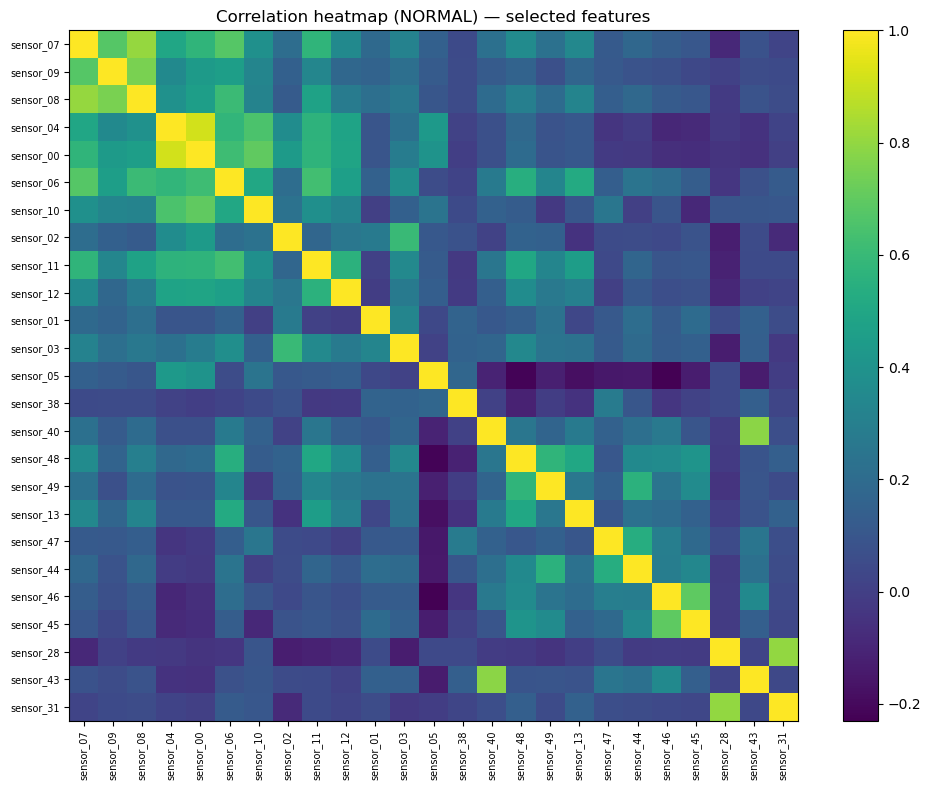

,sensor_07,sensor_09,sensor_08,sensor_04,sensor_00,sensor_06,sensor_10,sensor_02,sensor_11,sensor_12,sensor_01,sensor_03,sensor_05,sensor_38,sensor_40,sensor_48,sensor_49,sensor_13,sensor_47,sensor_44,sensor_46,sensor_45,sensor_28,sensor_43,sensor_31
sensor_07,1.000,0.676,0.806,0.496,0.573,0.678,0.388,0.207,0.576,0.352,0.189,0.313,0.147,0.044,0.222,0.364,0.228,0.344,0.117,0.180,0.133,0.104,-0.089,0.079,0.024
sensor_09,0.676,1.000,0.752,0.354,0.439,0.457,0.329,0.148,0.333,0.179,0.161,0.218,0.123,0.053,0.125,0.162,0.069,0.172,0.111,0.085,0.069,0.037,0.009,0.056,0.046
sensor_08,0.806,0.752,1.000,0.391,0.459,0.610,0.318,0.124,0.478,0.280,0.221,0.263,0.100,0.051,0.200,0.303,0.199,0.323,0.137,0.186,0.123,0.102,-0.022,0.082,0.054
sensor_04,0.496,0.354,0.391,1.000,0.915,0.577,0.650,0.368,0.565,0.484,0.095,0.225,0.429,0.011,0.072,0.184,0.084,0.109,-0.040,-0.010,-0.092,-0.085,-0.027,-0.050,0.017
sensor_00,0.573,0.439,0.459,0.915,1.000,0.619,0.701,0.439,0.571,0.490,0.092,0.286,0.400,-0.004,0.069,0.198,0.087,0.106,-0.019,-0.024,-0.063,-0.069,-0.045,-0.057,0.002
sensor_06,0.678,0.457,0.610,0.577,0.619,1.000,0.509,0.211,0.627,0.466,0.154,0.380,0.057,0.019,0.276,0.542,0.328,0.522,0.137,0.241,0.211,0.133,-0.036,0.073,0.124
sensor_10,0.388,0.329,0.318,0.650,0.701,0.509,1.000,0.234,0.382,0.326,0.002,0.149,0.244,0.045,0.151,0.127,-0.026,0.100,0.252,0.001,0.093,-0.088,0.095,0.100,0.103
sensor_02,0.207,0.148,0.124,0.368,0.439,0.211,0.234,1.000,0.177,0.256,0.277,0.602,0.109,0.078,0.011,0.159,0.149,-0.048,0.049,0.055,0.043,0.083,-0.127,0.049,-0.086
sensor_11,0.576,0.333,0.478,0.565,0.571,0.627,0.382,0.177,1.000,0.561,0.008,0.350,0.123,-0.027,0.252,0.502,0.328,0.453,0.039,0.169,0.093,0.102,-0.111,0.044,0.048
sensor_12,0.352,0.179,0.280,0.484,0.490,0.466,0.326,0.256,0.561,1.000,-0.009,0.277,0.138,-0.023,0.140,0.367,0.267,0.304,0.004,0.111,0.068,0.076,-0.095,0.010,0.021


In [29]:
CORRELATION_FEATURES = TOP_FEATURES[:]

correlation_dataframe = normal_dataframe[CORRELATION_FEATURES].copy()
correlation_matrix = correlation_dataframe.corr(method="pearson")

corr_path = SILVER_EDA_ARTIFACTS_PATH / "correlation__normal.csv"
correlation_matrix.to_csv(corr_path)
wandb.save(str(corr_path))

# Heatmap
plt.figure(figsize=(10, 8))
plt.imshow(correlation_matrix.values, aspect="auto")
plt.title("Correlation heatmap (NORMAL) — selected features")
plt.colorbar()
plt.xticks(range(len(CORRELATION_FEATURES)), CORRELATION_FEATURES, rotation=90, fontsize=7)
plt.yticks(range(len(CORRELATION_FEATURES)), CORRELATION_FEATURES, fontsize=7)
plt.tight_layout()

heatmap_path = SILVER_EDA_ARTIFACTS_PATH / "correlation__normal_heatmap.png"
plt.savefig(heatmap_path, dpi=200)
plt.show()

wandb.save(str(heatmap_path))

correlation_matrix.round(3)

----

## Compare Normal and Abnormal Feature Distributions

This section creates distribution plots for the top features using normal and abnormal slices.

The goal here is to visually inspect whether the most important features from the effect-size table actually show meaningful separation in their value distributions. Sometimes the table suggests a difference, and the plots help confirm whether that difference looks broad, narrow, shifted, or heavily overlapping.

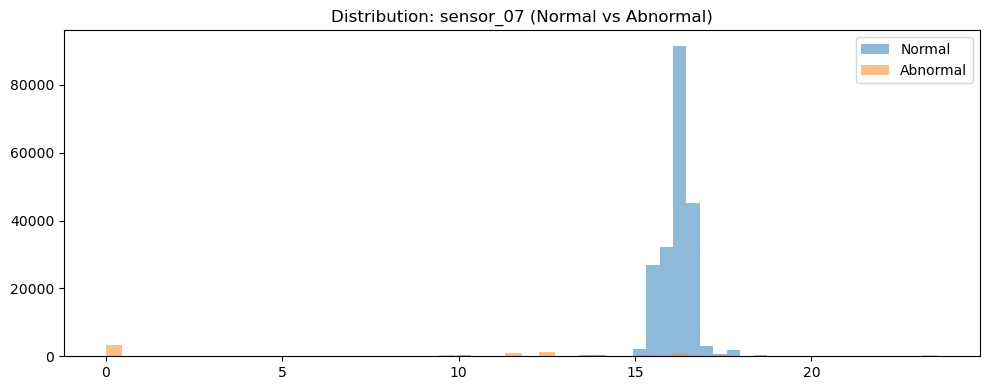

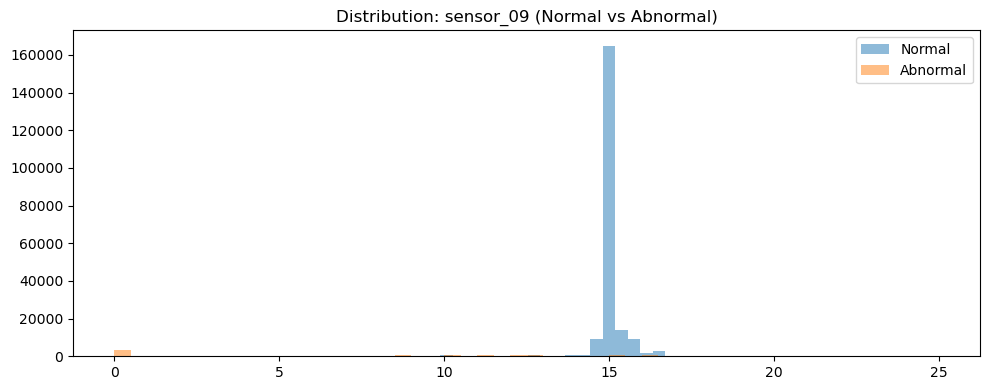

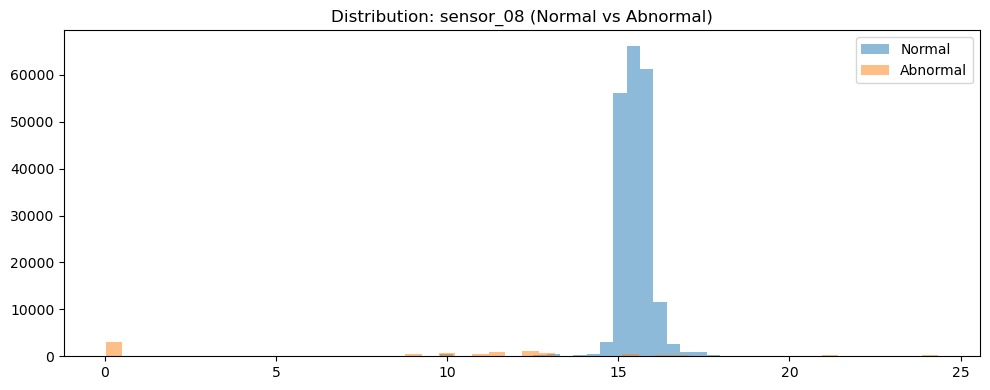

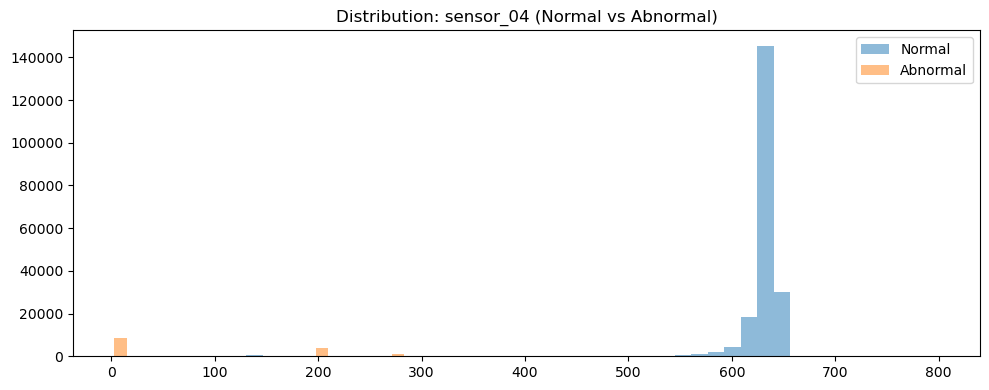

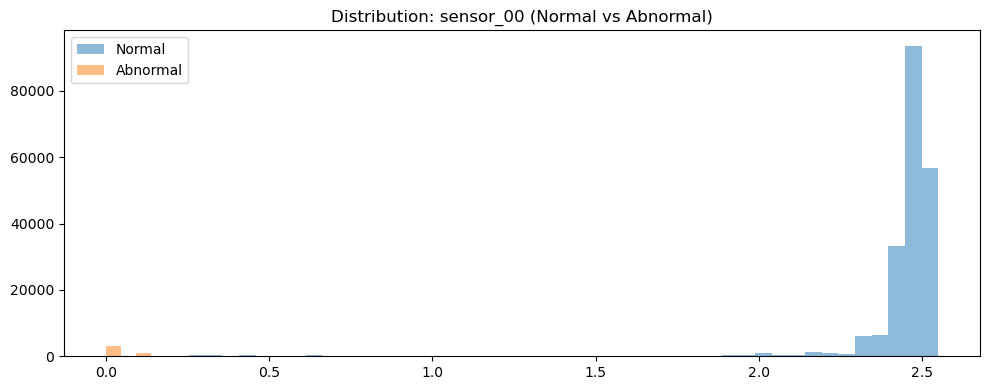

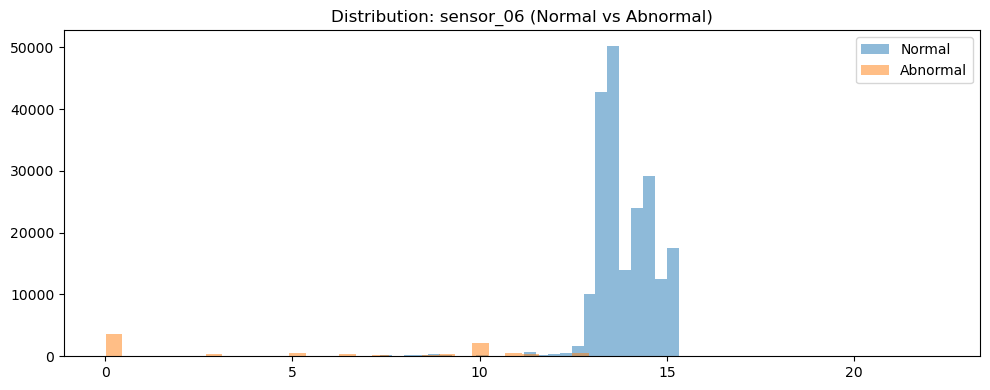

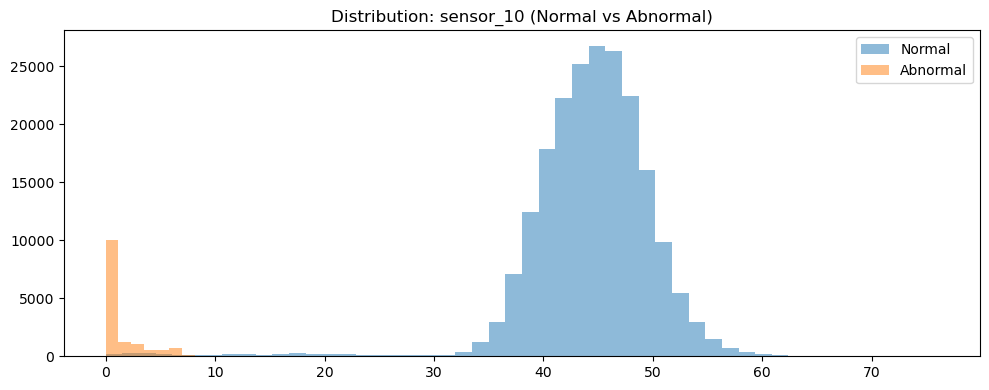

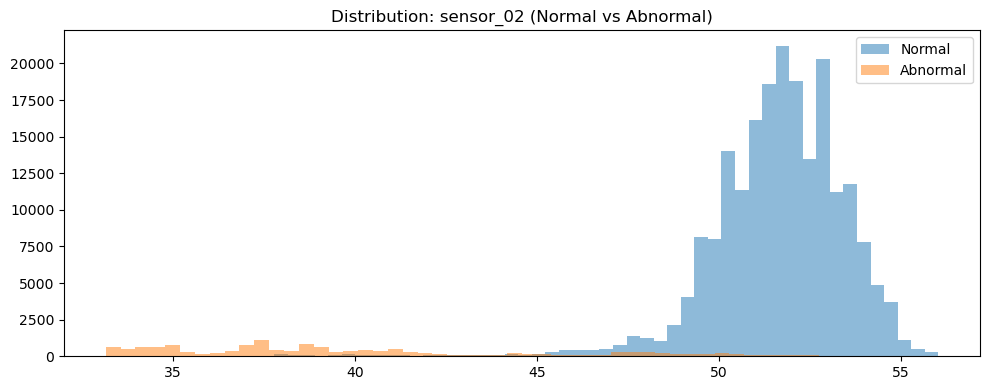

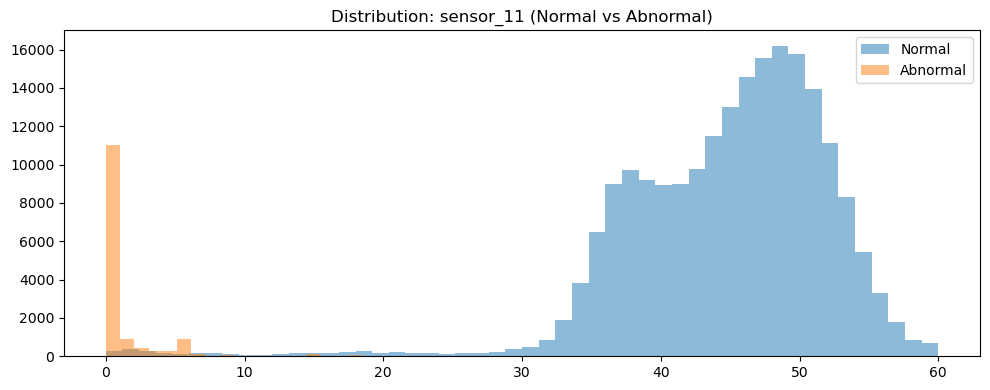

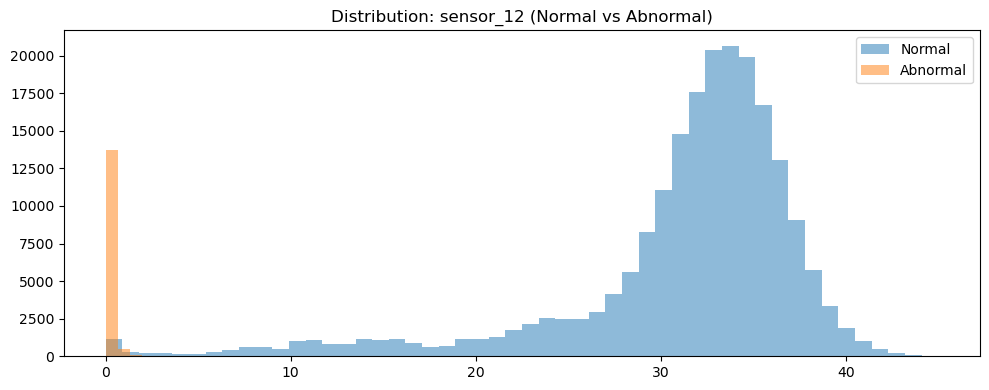

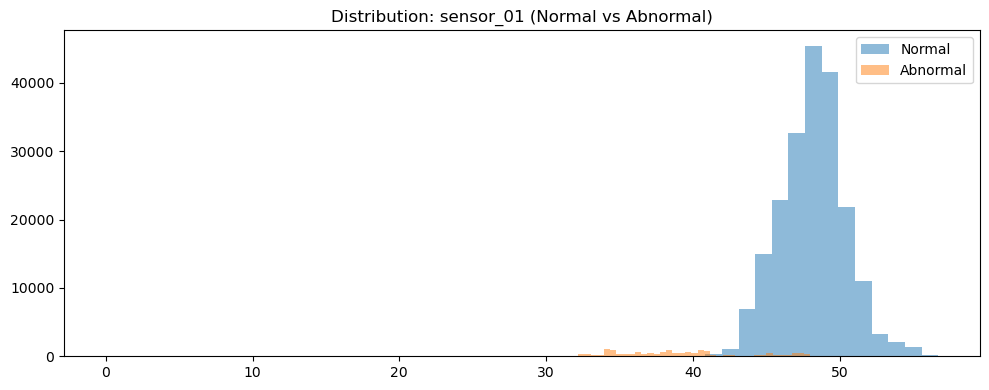

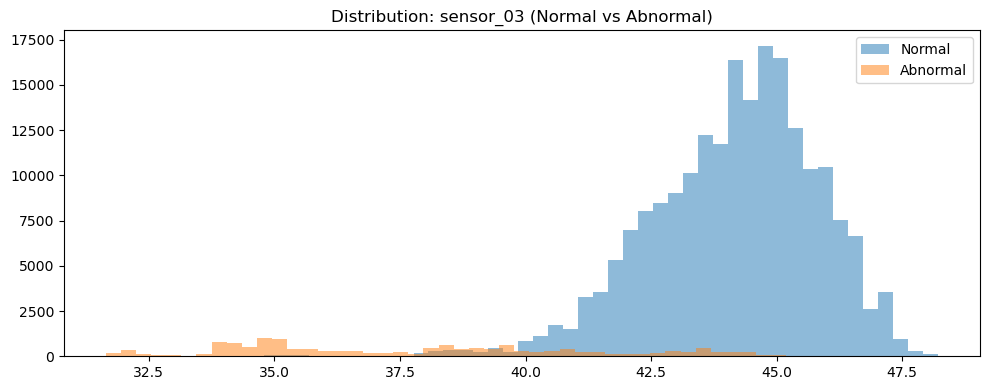

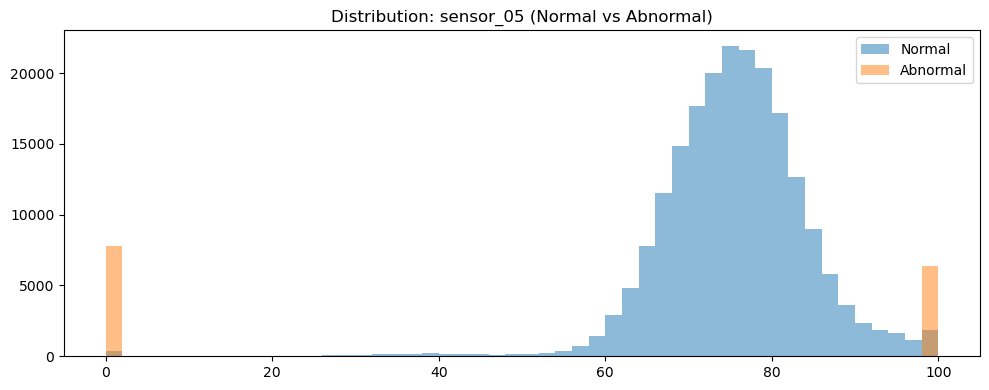

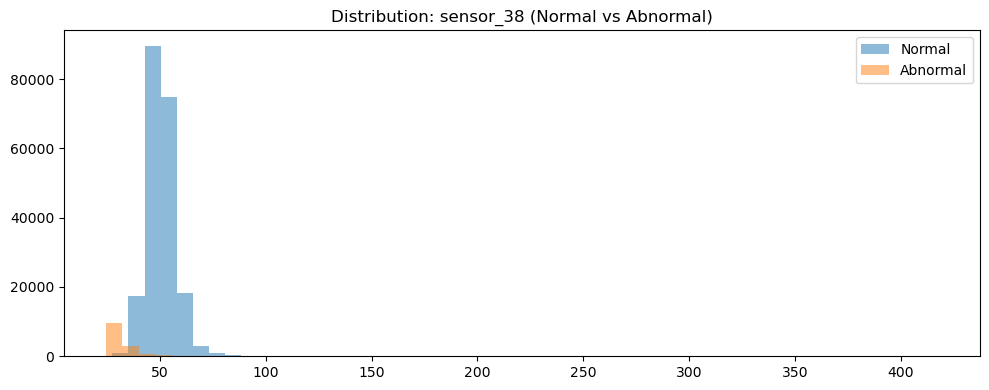

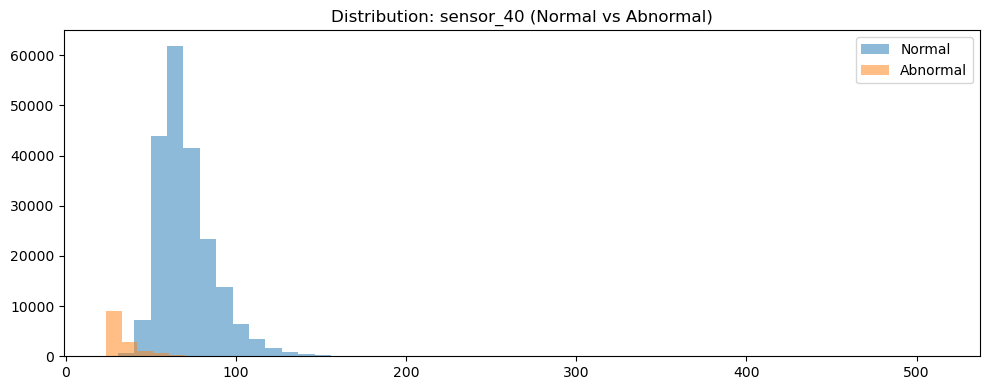

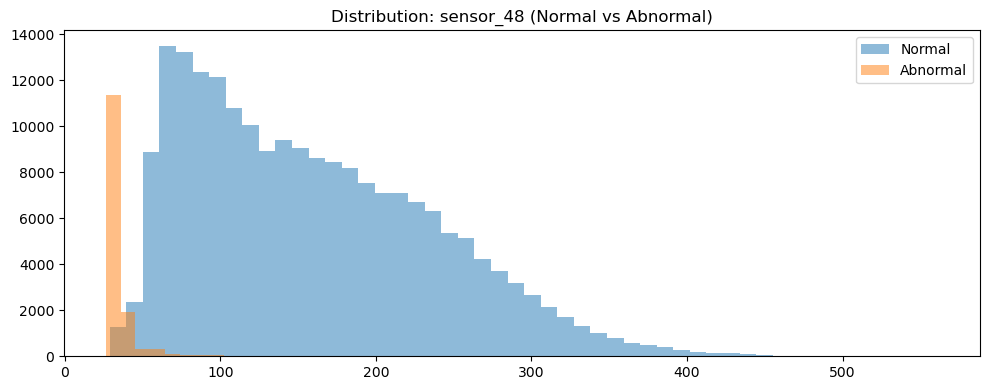

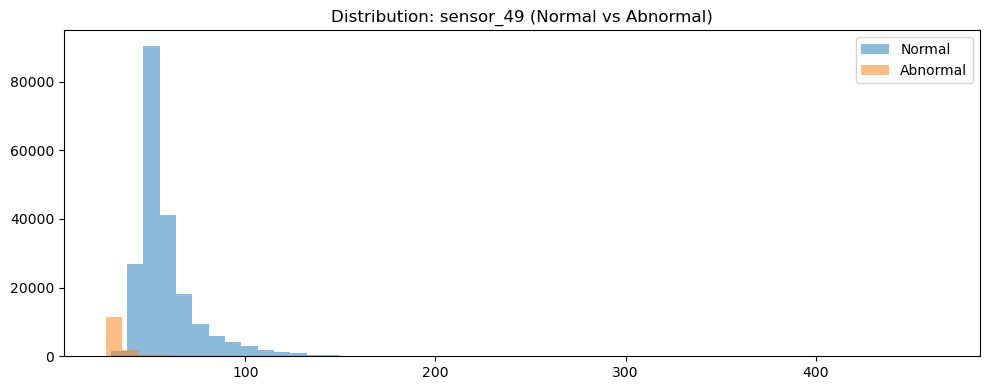

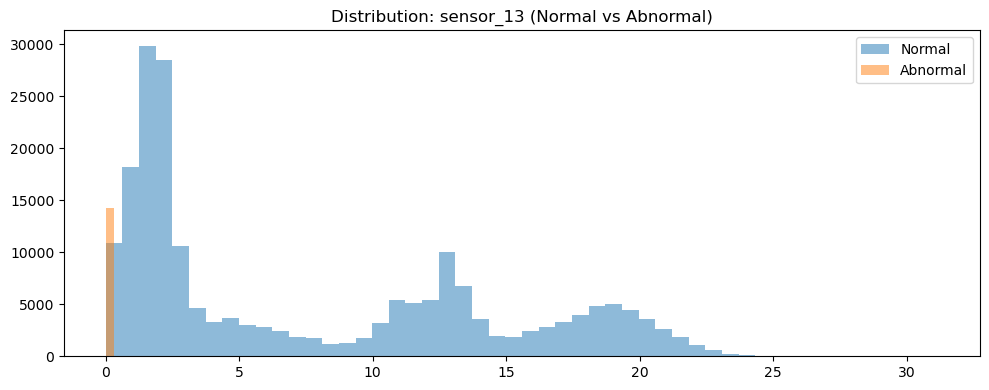

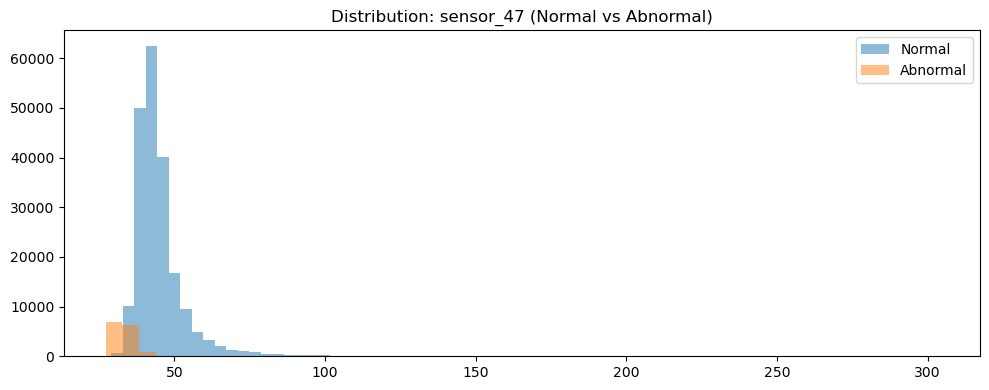

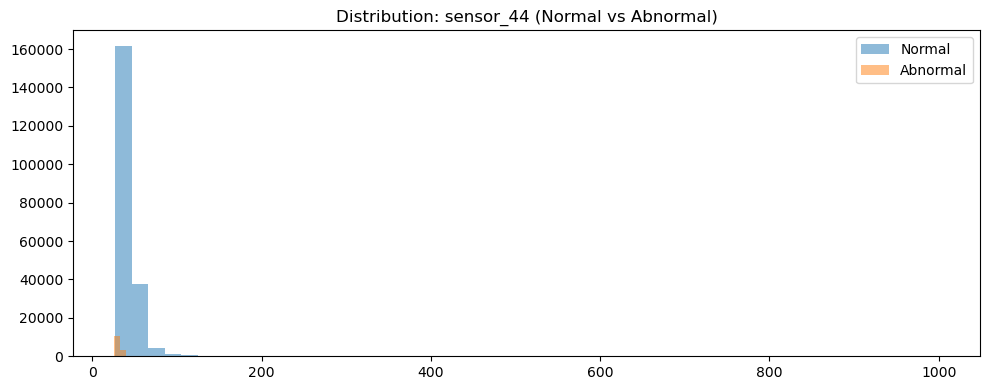

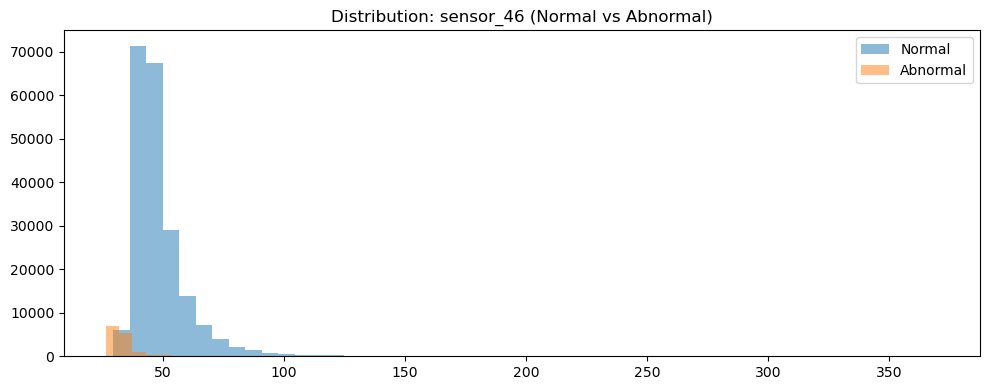

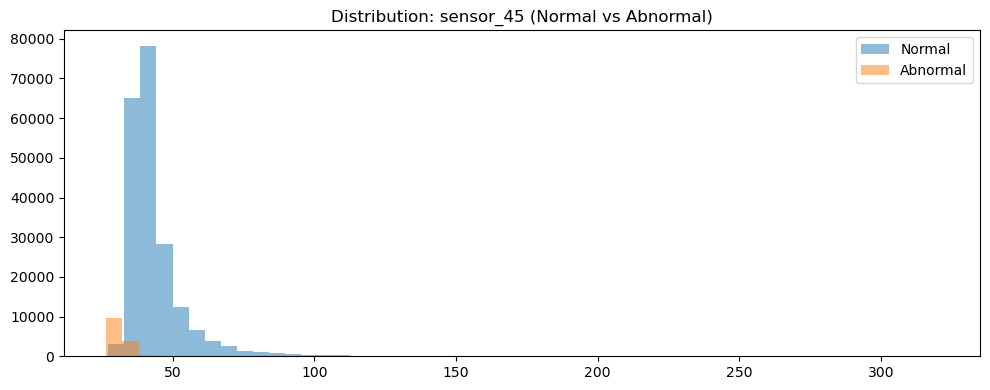

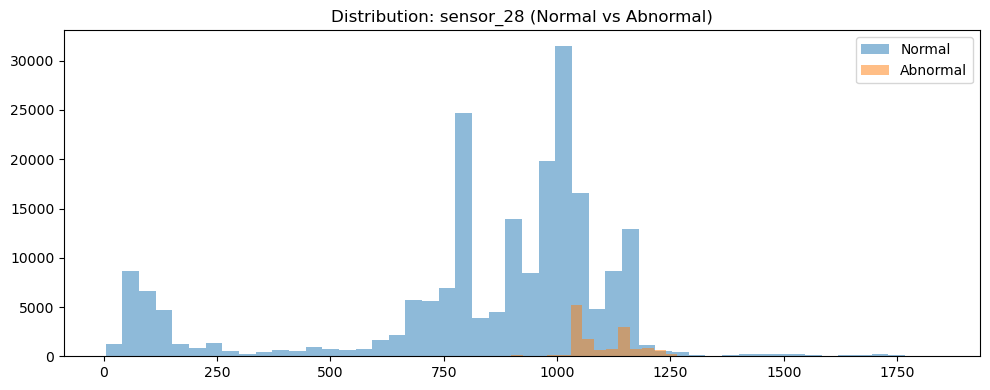

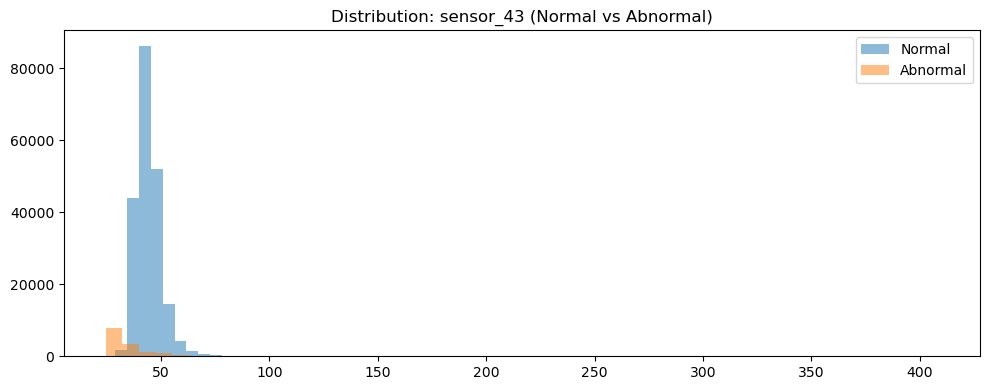

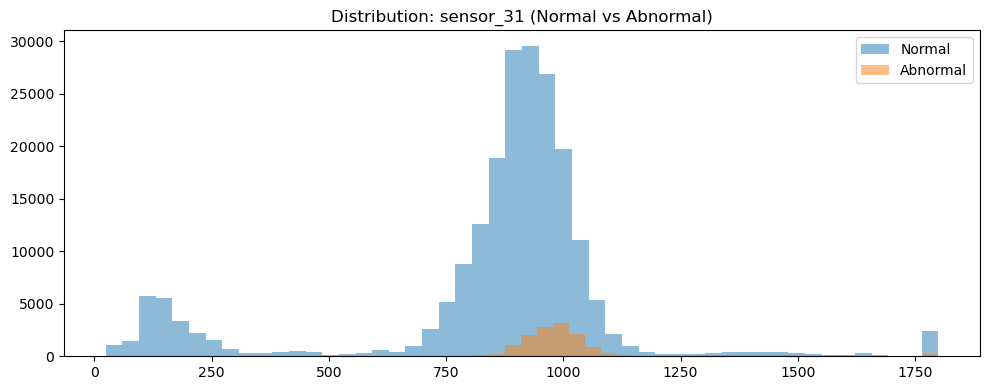

In [30]:
plot_features = TOP_FEATURES[:] if len(TOP_FEATURES) > 0 else FEATURE_COLUMNS[:]

for feature_name in plot_features:
    if feature_name not in dataframe.columns:
        continue
    if not pd.api.types.is_numeric_dtype(dataframe[feature_name]):
        continue

    plt.figure(figsize=(10, 4))

    series_normal = normal_dataframe[feature_name].dropna()
    series_abnormal = abnormal_dataframe[feature_name].dropna()

    # Use hist with alpha via default; do not set colors explicitly
    plt.hist(series_normal.values, bins=50, alpha=0.5, label="Normal")
    plt.hist(series_abnormal.values, bins=50, alpha=0.5, label="Abnormal")

    plt.title(f"Distribution: {feature_name} (Normal vs Abnormal)")
    plt.legend()
    plt.tight_layout()

    out_path = SILVER_EDA_ARTIFACTS_PATH / f"distribution__{feature_name}.png"
    plt.savefig(out_path, dpi=200)
    plt.show()

    wandb.save(str(out_path))

### Ask

What should I look for in these normal vs abnormal distribution plots?

### Answer

I mainly want to see whether the two states overlap heavily or whether they separate in a way that could actually help anomaly detection.

A few useful patterns are:
- a clear shift in center
- a wider abnormal spread
- a one-sided tail increase
- a tighter normal range with a noisier abnormal range

These plots do not prove that one feature should be modeled by itself, but they do help show which features seem most behaviorally informative.

----

## Overlay the Top Features Across Time

This plot puts the top features onto one shared z-scored time-based view.

I use this to see whether the strongest behavior-shift features also show visible movement around the anomaly periods when viewed across the sequence of observations. Since the features are z-scored, the point is comparison of movement shape rather than comparison of raw units.

In [ ]:
plot_features = TOP_FEATURES[:] if len(TOP_FEATURES) > 0 else FEATURE_COLUMNS[:]

plt.figure(figsize=(12, 6))

x_axis = dataframe["time_index"] if "time_index" in dataframe.columns else np.arange(len(dataframe))

for feature_name in plot_features:
    if feature_name not in dataframe.columns:
        continue
    if not pd.api.types.is_numeric_dtype(dataframe[feature_name]):
        continue
    series = dataframe[feature_name].copy()
    series = series.fillna(series.median())
    plt.plot(x_axis, z_score(series), label=feature_name)

# Mark anomalies if present
if "anomaly_flag" in dataframe.columns:
    anomaly_positions = dataframe.index[dataframe["anomaly_flag"] == 1].tolist()
    if len(anomaly_positions) > 0:
        # draw sparse markers to avoid heavy rendering
        marker_positions = anomaly_positions[::max(1, len(anomaly_positions)//200)]
        plt.scatter(x_axis.iloc[marker_positions] if hasattr(x_axis, "iloc") else np.array(x_axis)[marker_positions],
                    np.zeros(len(marker_positions)),
                    marker="x",
                    label="anomaly_flag=1 (markers at y=0)")

plt.title("Top feature overlay (z-scored)")
plt.legend(fontsize=7)
plt.tight_layout()

overlay_path = SILVER_EDA_ARTIFACTS_PATH / "timeseries__top_features_overlay.png"
plt.savefig(overlay_path, dpi=200)
plt.show()

wandb.save(str(overlay_path))

/tmp/ipykernel_279668/1592621151.py:29: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/tmp/ipykernel_279668/1592621151.py:32: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(overlay_path, dpi=200)
/opt/miniconda/envs/capstone/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


----

## Plot Each Top Feature Against Broken or Anomalous Periods

This section looks at the top features one at a time across the timeline and marks where broken or anomalous periods occur.

I like this view because it is easier to read than the shared overlay when I want to see how a single feature behaves around the abnormal periods. It helps show whether the feature spikes, drifts, drops, or stays noisy near the failure windows.

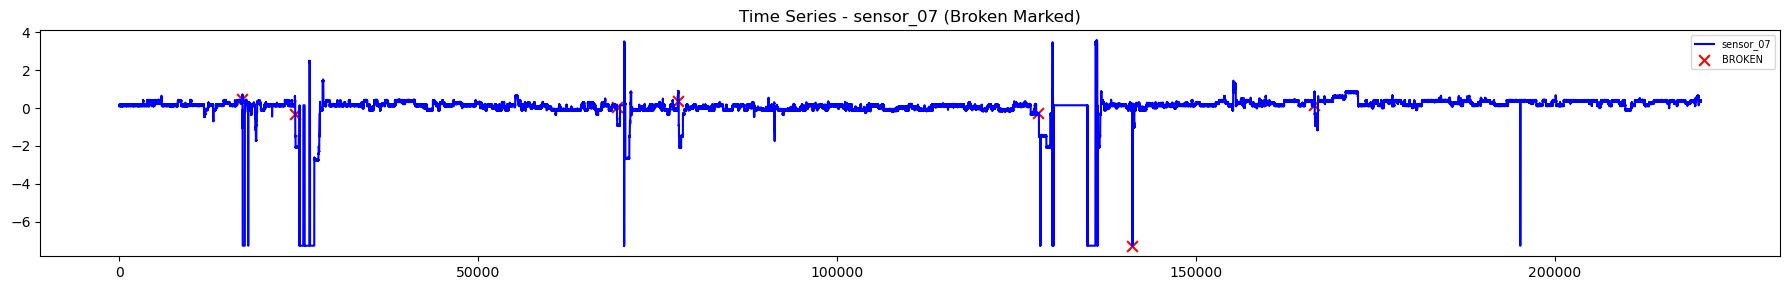

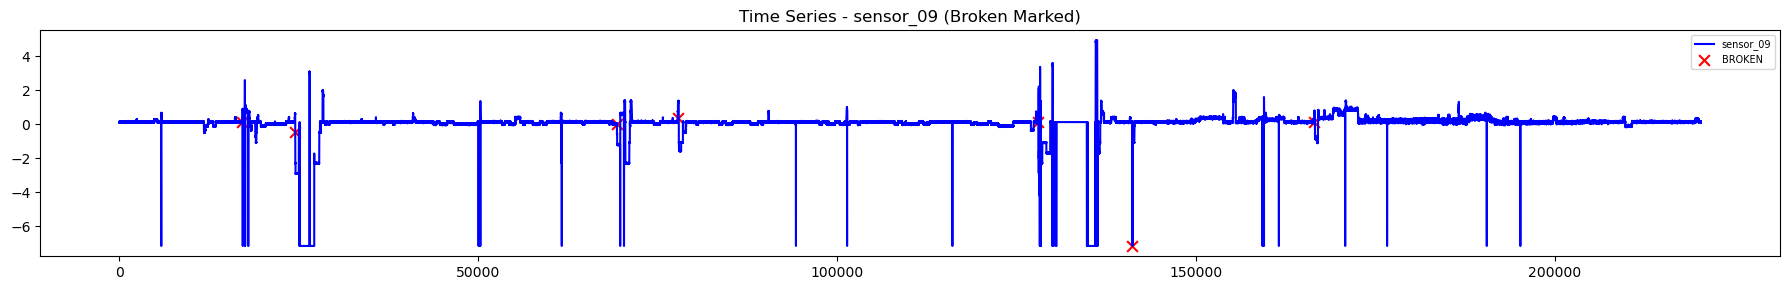

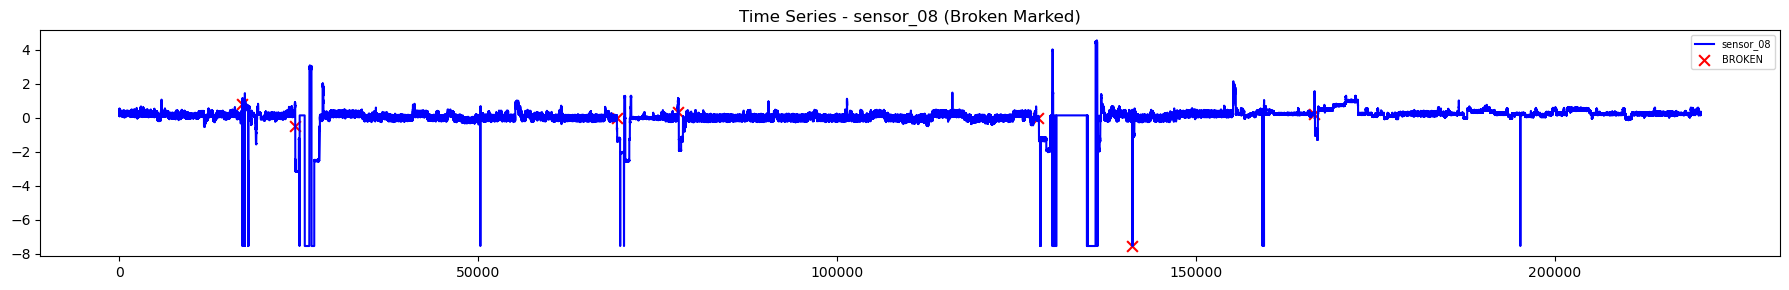

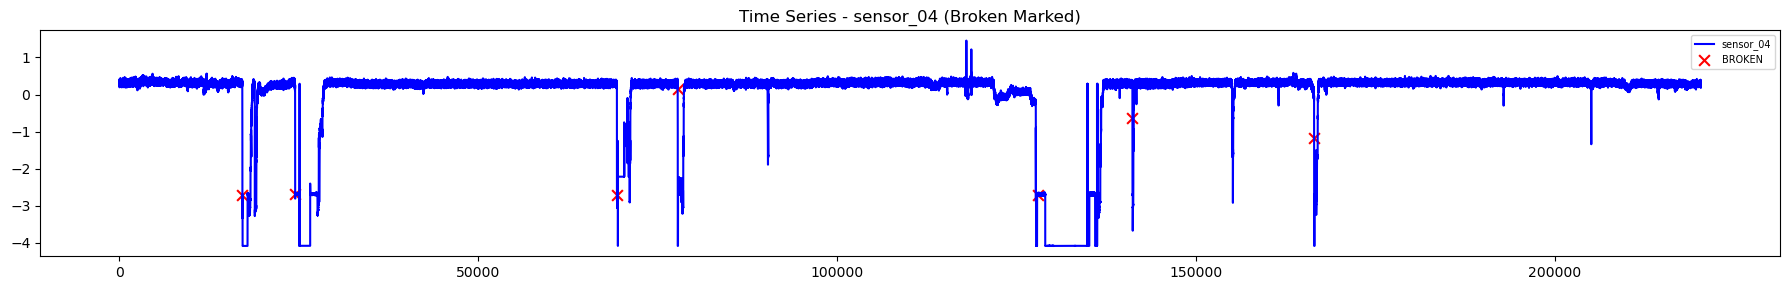

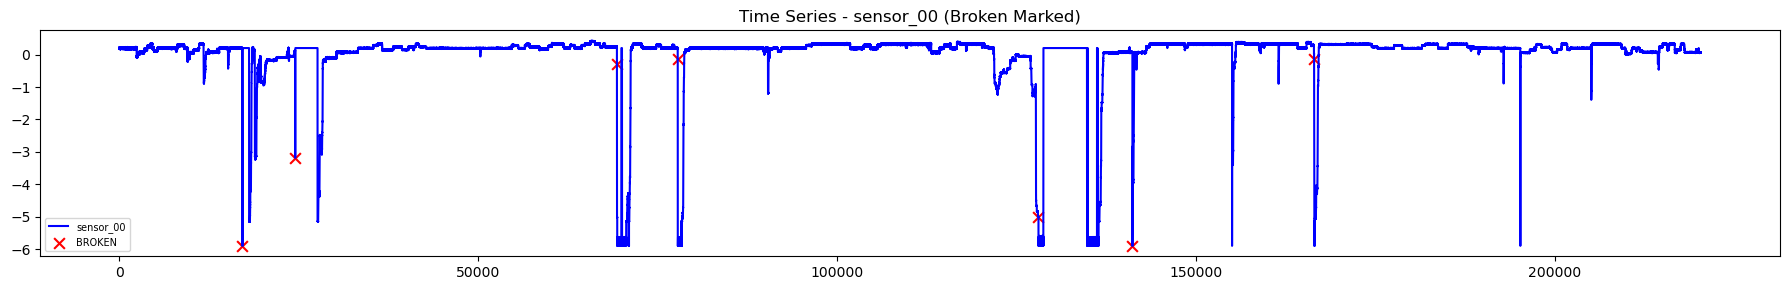

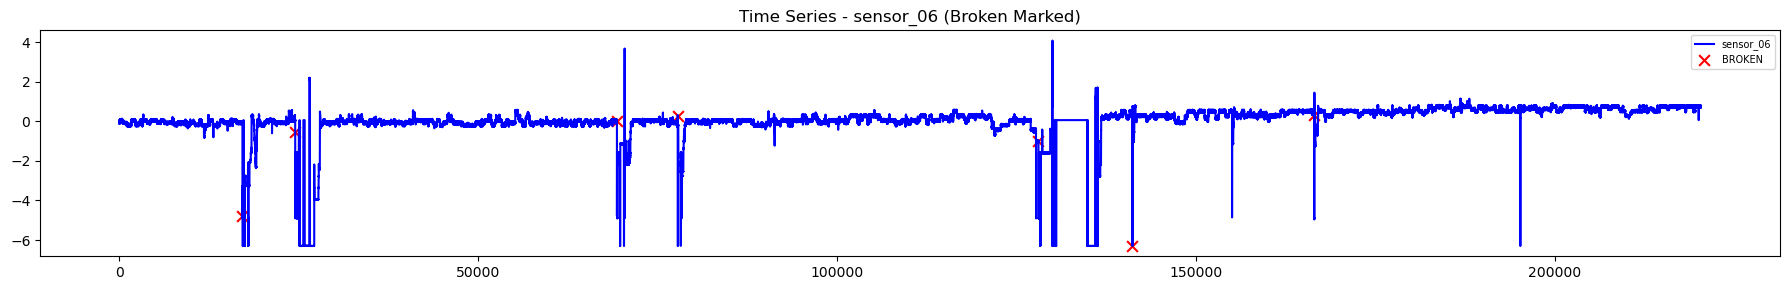

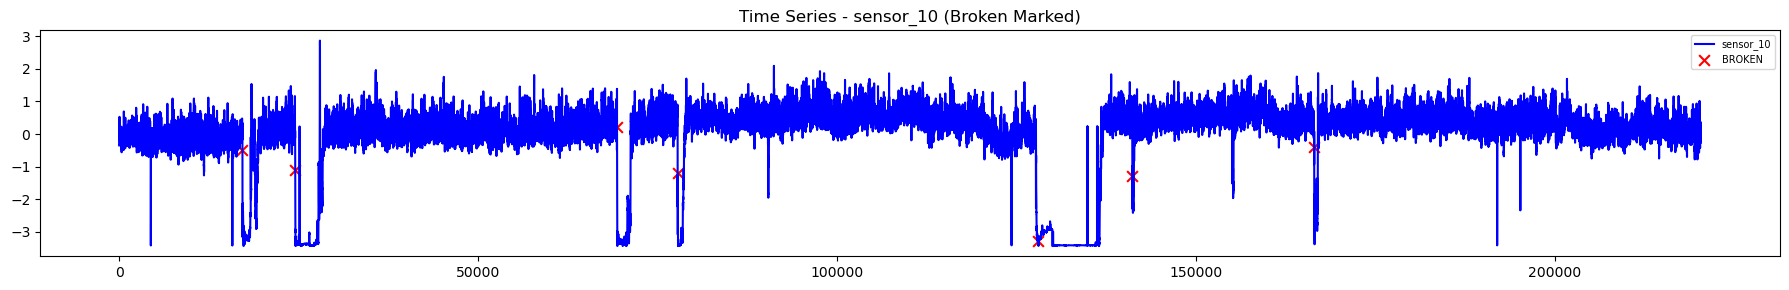

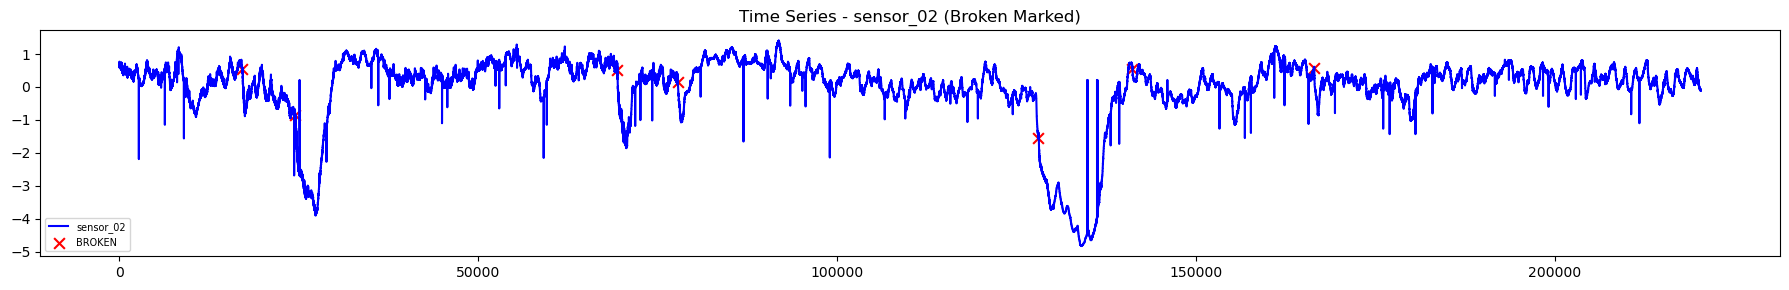

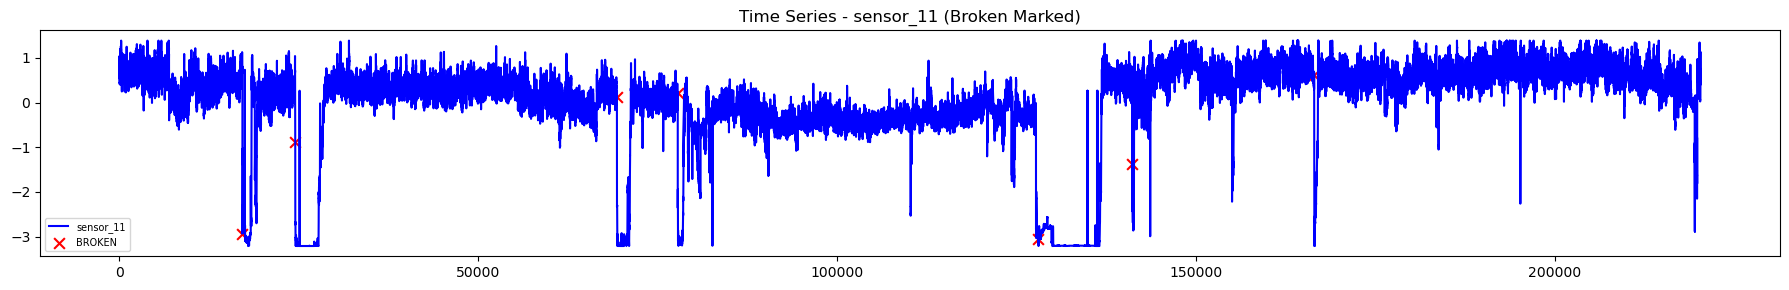

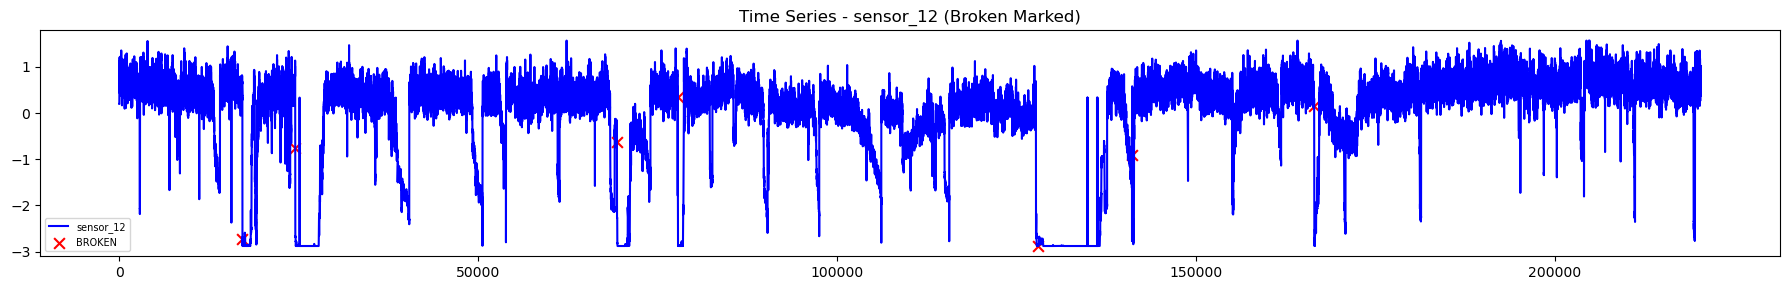

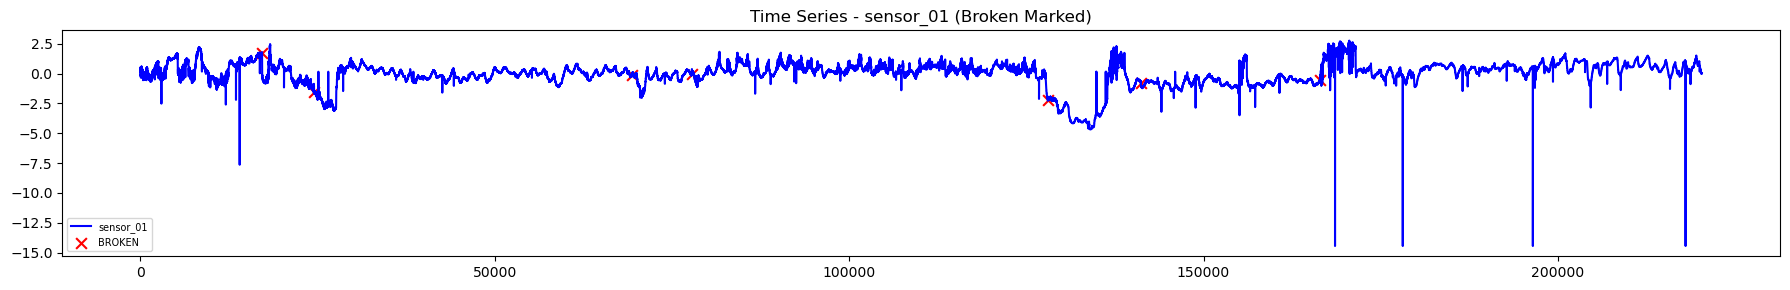

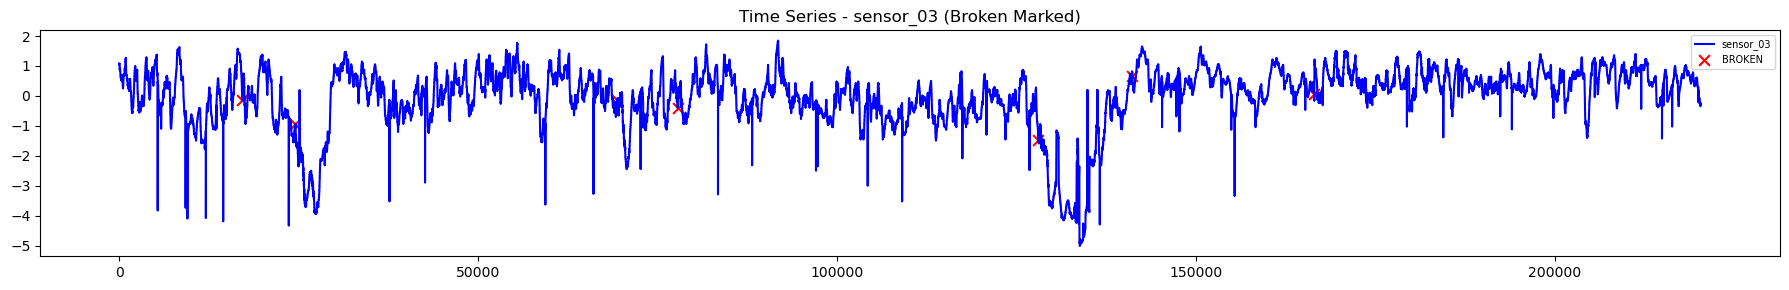

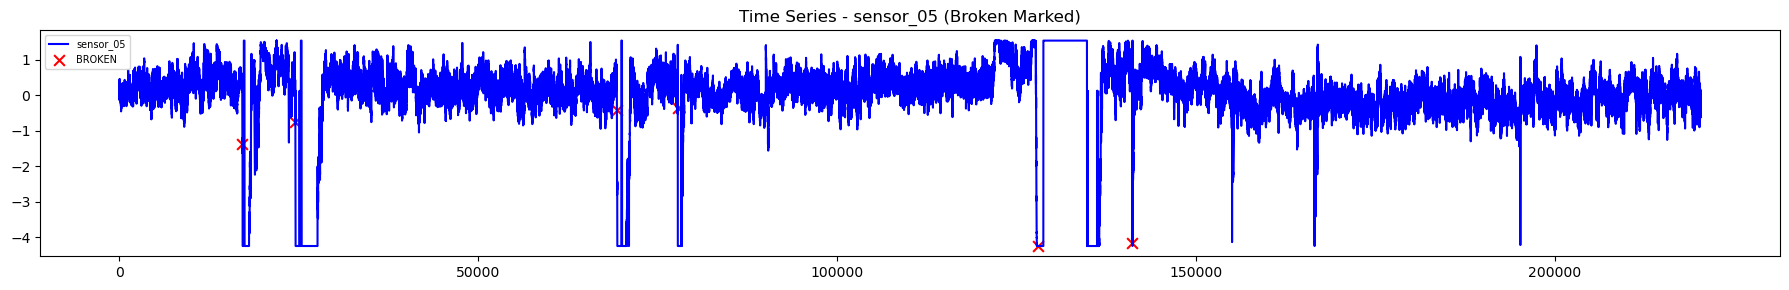

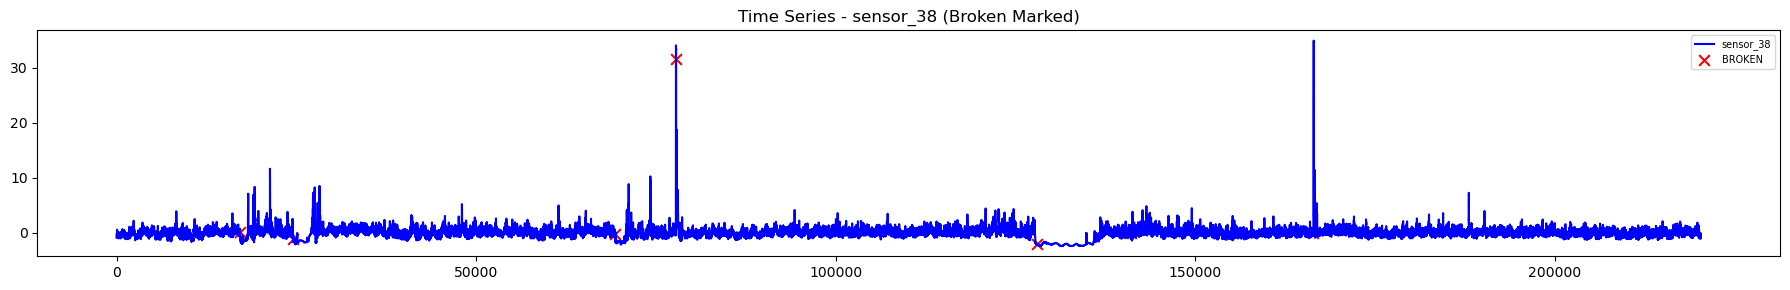

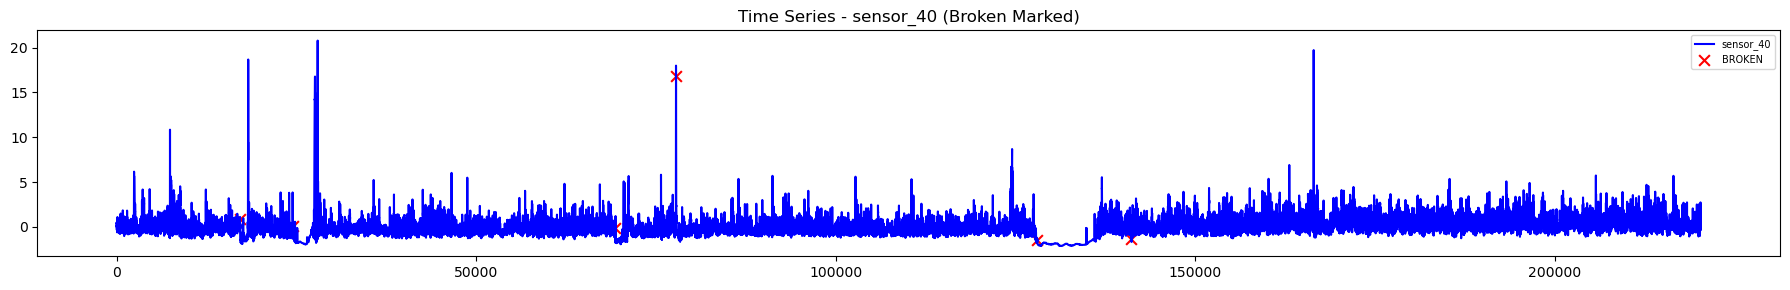

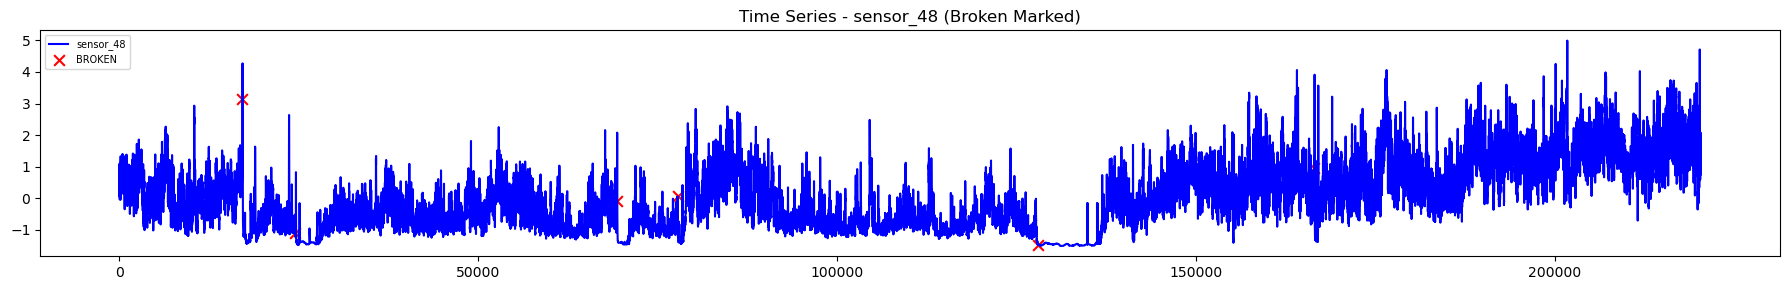

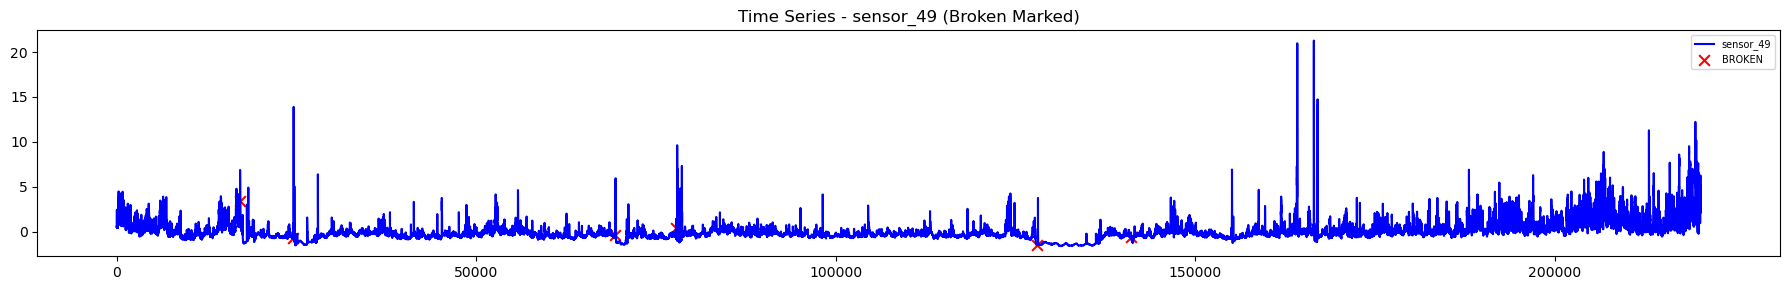

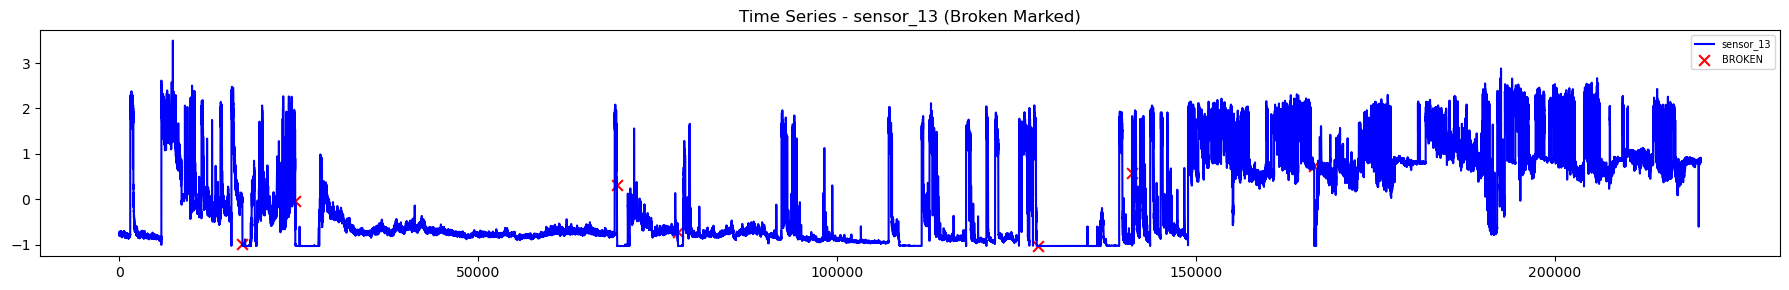

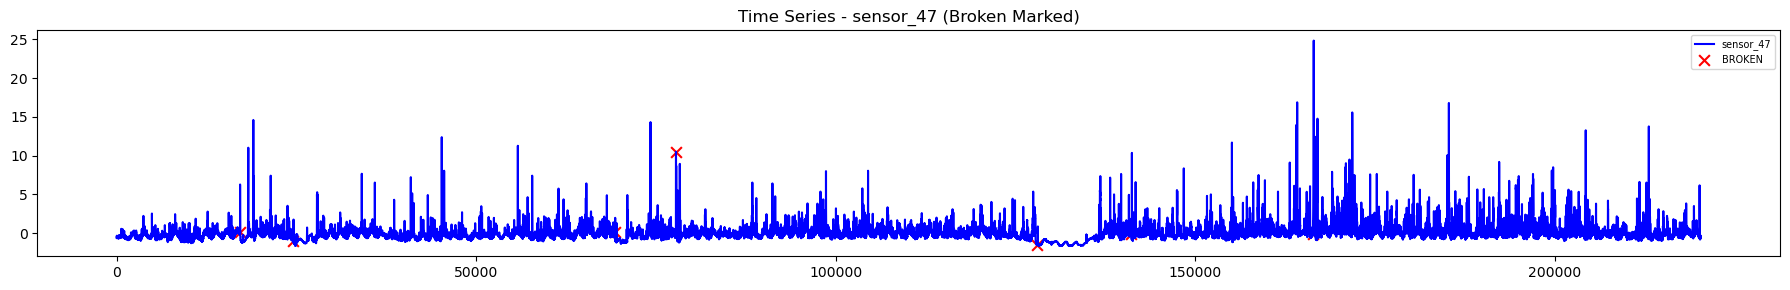

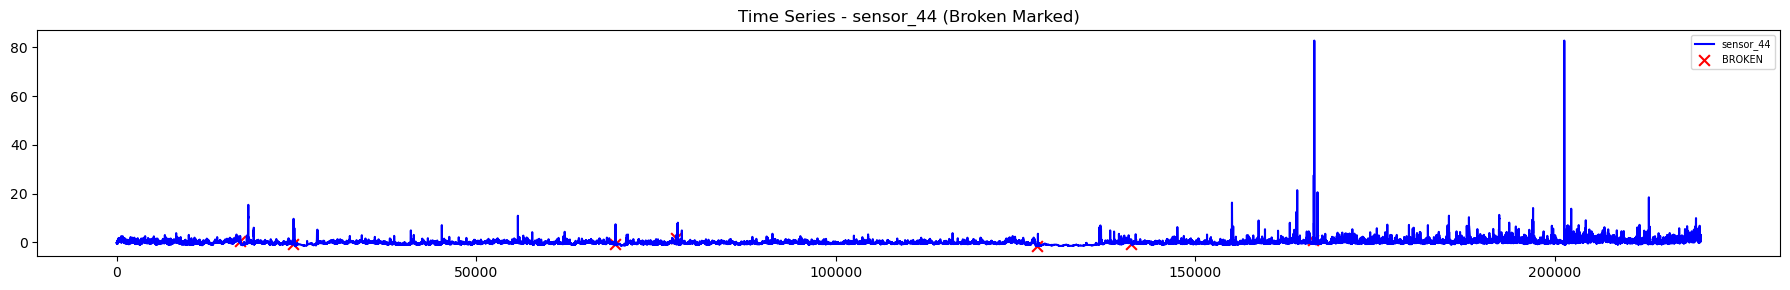

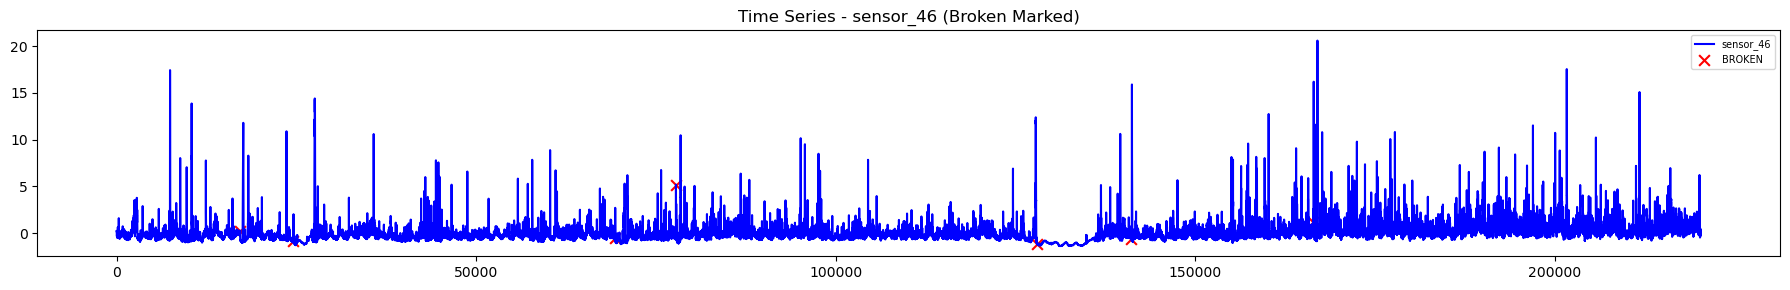

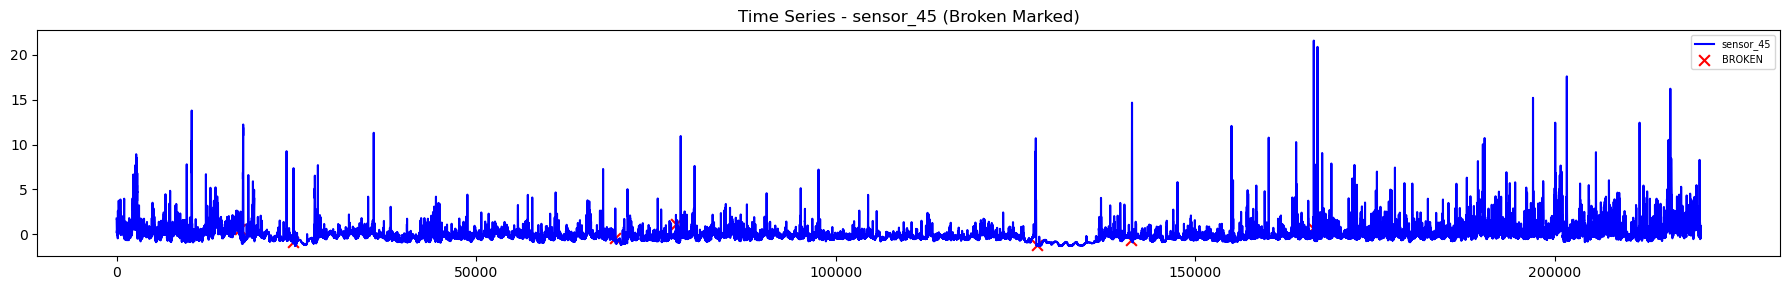

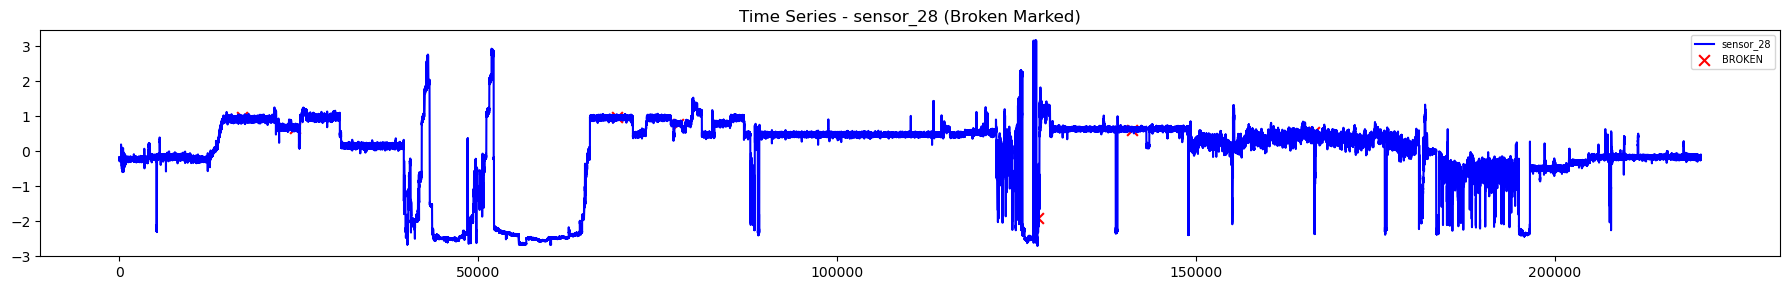

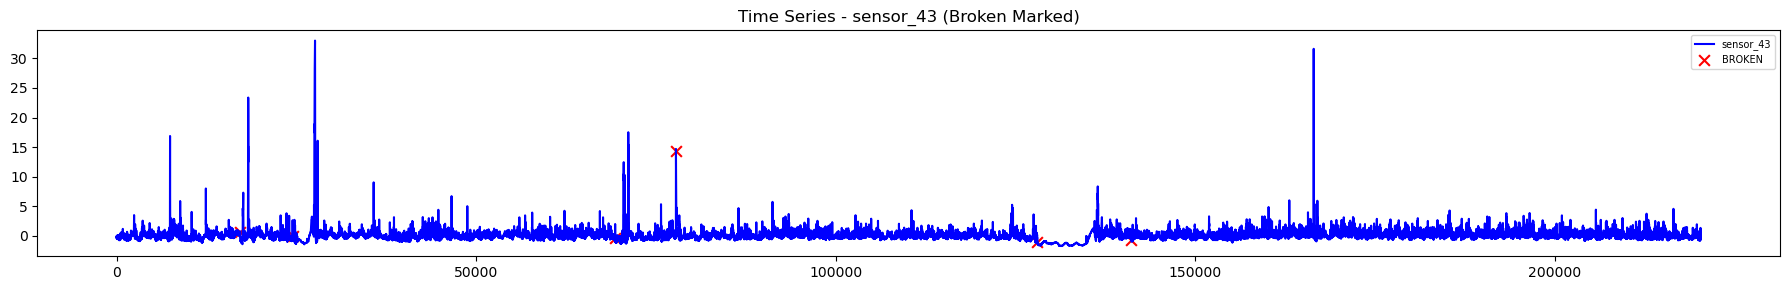

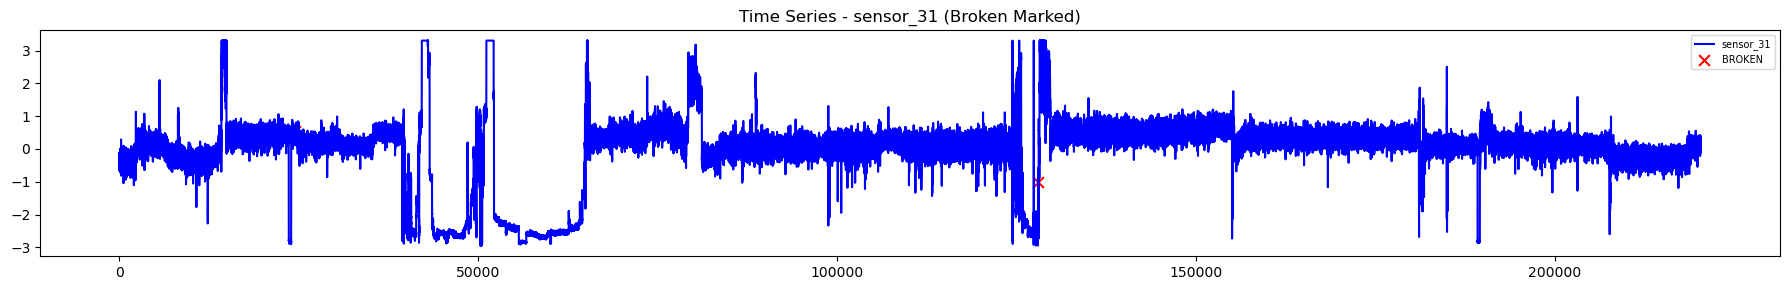

In [ ]:
plot_features = TOP_FEATURES[:] if len(TOP_FEATURES) > 0 else FEATURE_COLUMNS[:]

if "machine_status" in dataframe.columns:
    broken_mask = dataframe["machine_status"].eq("BROKEN")
elif "anomaly_flag" in dataframe.columns:
    broken_mask = dataframe["anomaly_flag"].eq(1)
else:
    broken_mask = pd.Series(False, index=dataframe.index)   

x_axis = dataframe["time_index"] if "time_index" in dataframe.columns else np.arange(len(dataframe))

broken_positions = np.flatnonzero(broken_mask.to_numpy())

for feature_name in plot_features:
    if feature_name not in dataframe.columns:
        continue
    if not pd.api.types.is_numeric_dtype(dataframe[feature_name]):
        continue

    series = dataframe[feature_name].copy()
    median_value = series.median()
    if pd.isna(median_value):
        median_value = 0
    series = series.fillna(median_value)

    # For Normalized Values, Use this:
    # For Raw Values, Comment This and Uncomment Below
    plot_series = z_score(series)

    # For Raw Values, use this:
    # For Normalize, Comment This and Uncomment Above
    # plot_series = series.to_numpy()

    plt.figure(figsize=(18, 3))
    plt.plot(x_axis, plot_series, color="blue", label=feature_name)

    if len(broken_positions) > 0:
        step = max(1, len(broken_positions) // 200)
        marker_positions = broken_positions[::step]

        x_marker_values = (
            x_axis.iloc[marker_positions]
            if hasattr(x_axis, "iloc")
            else np.asarray(x_axis)[marker_positions]
        )
        y_marker_values = np.asarray(plot_series)[marker_positions]

        plt.scatter(
            x_marker_values,
            y_marker_values,
            color="red",
            marker="x",
            s=60,
            label="BROKEN"
        )

    plt.title(f"Time Series - {feature_name} (Broken Marked)")
    plt.legend(fontsize=7)
    plt.tight_layout()

    feature_plot_path = SILVER_EDA_ARTIFACTS_PATH / f"timeseries__{feature_name}__broken_marked.png"
    plt.savefig(feature_plot_path, dpi=200)
    plt.show()
    plt.close()

    wandb.save(str(feature_plot_path))
    

----

## Cluster Numeric Features by Correlation Distance

Here I use correlation distance and agglomerative clustering to group numeric features into broader similarity clusters.

This is another way of organizing the Silver feature space. Instead of ranking features by abnormal shift, this section groups features by how similarly they tend to move under normal behavior. That can be helpful for subsystem thinking, redundancy checks, and later feature interpretation.

In [ ]:
# Use NORMAL correlation for clustering

ALL_FEATURES = [column for column in FEATURE_COLUMNS if column in dataframe.columns and pd.api.types.is_numeric_dtype(dataframe[column])]

cluster_features = ALL_FEATURES[:]  # all numeric features
cluster_dataframe = normal_dataframe[cluster_features].copy()

# Fill missing with median so correlation works
for feature_name in cluster_features:
    cluster_dataframe[feature_name] = cluster_dataframe[feature_name].fillna(cluster_dataframe[feature_name].median())

correlation_matrix = cluster_dataframe.corr(method="pearson").fillna(0.0)

# Convert correlation to distance (0 = identical, 1 = unrelated)
distance_matrix = 1.0 - correlation_matrix.abs()

# Choose a small number of clusters to start (you can tune)
cluster_count = 6 if len(cluster_features) >= 6 else max(2, len(cluster_features))

model = AgglomerativeClustering(
    n_clusters=cluster_count,
    metric="precomputed",
    linkage="average",
)

labels = model.fit_predict(distance_matrix.values)

cluster_rows = []
for feature_name, cluster_label in zip(cluster_features, labels):
    cluster_rows.append({
        "feature": feature_name,
        "cluster_id": int(cluster_label),
    })

cluster_table = pd.DataFrame(cluster_rows).sort_values(["cluster_id", "feature"])

cluster_path = SILVER_EDA_ARTIFACTS_PATH / "clusters__correlation_agglomerative.csv"
cluster_table.to_csv(cluster_path, index=False)
wandb.save(str(cluster_path))

cluster_table.head(30)

,feature,cluster_id
0,sensor_00,0
4,sensor_04,0
5,sensor_05,0
6,sensor_06,0
7,sensor_07,0
8,sensor_08,0
9,sensor_09,0
10,sensor_10,0
11,sensor_11,0
12,sensor_12,0


----

## Detect and Align Anomaly Onsets

This section finds the start points of anomaly periods and then aligns windows around those onsets.

The main idea here is to answer a timing question:

**what do the key features tend to do right before and right after an anomaly begins?**

By aligning multiple onset windows together, I can look for repeated pre-failure or onset behavior patterns instead of only looking at one episode at a time.

2026-03-22 07:42:26,910 | INFO | capstone.silver_eda | Anomaly onsets found: 7


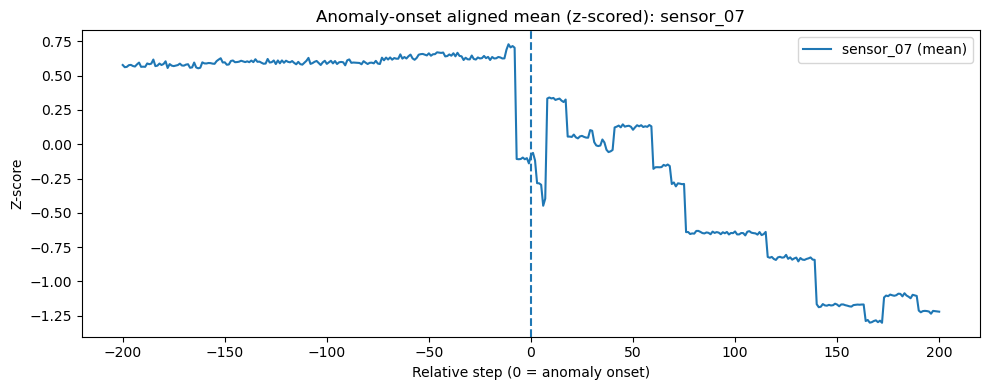

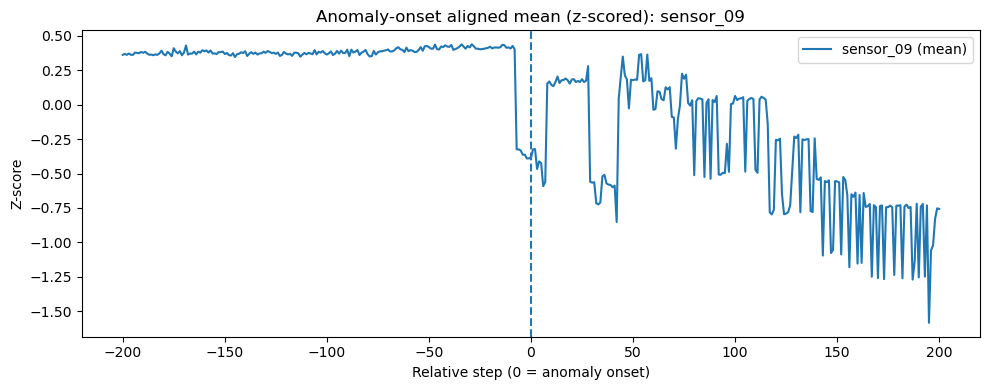

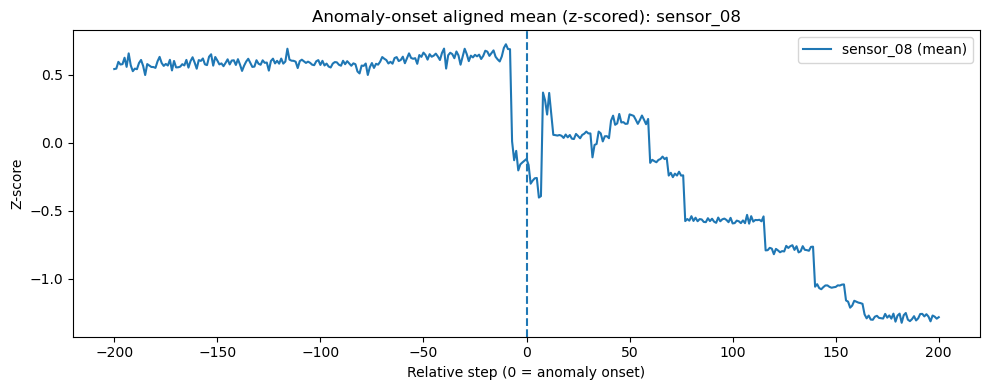

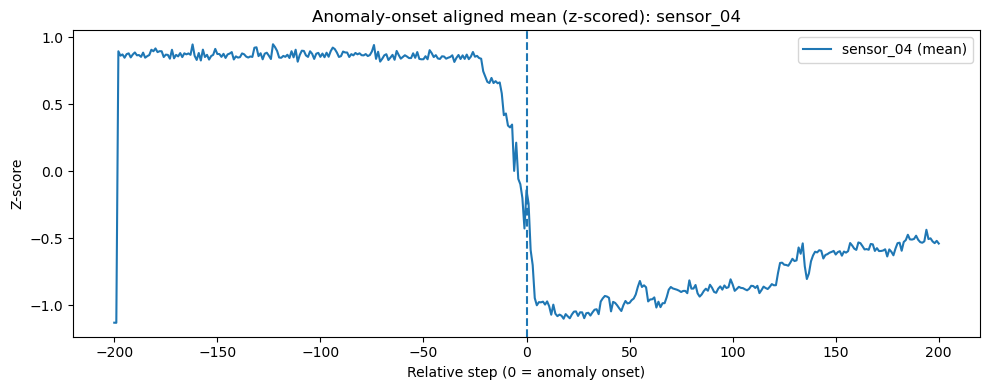

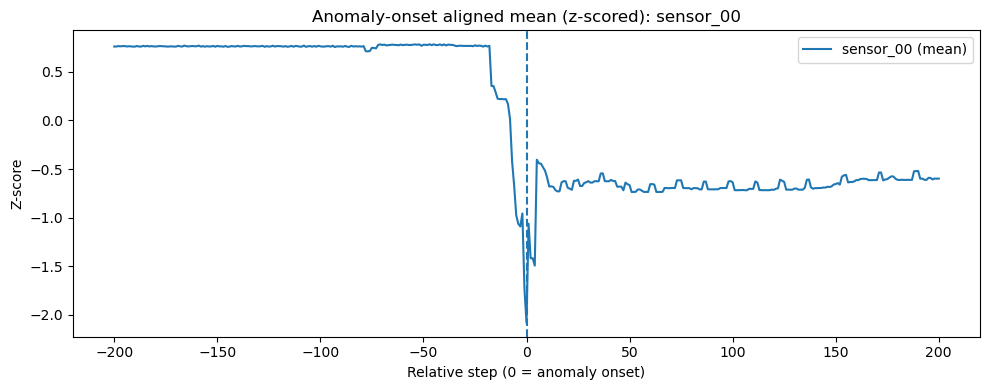

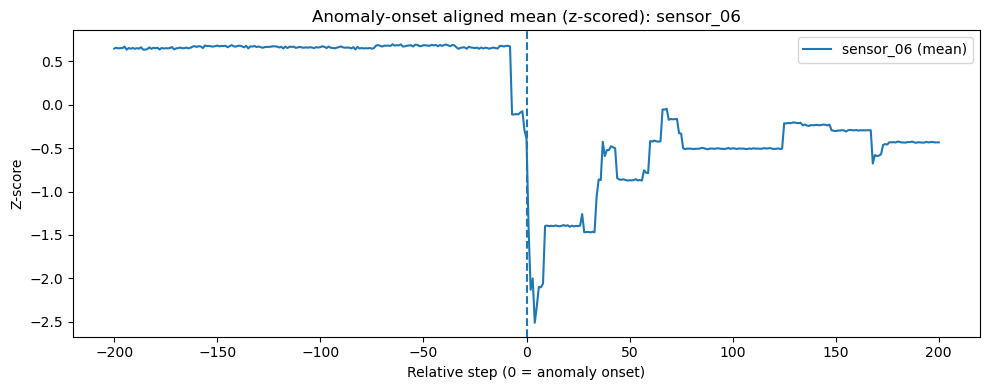

(['sensor_07',
  'sensor_09',
  'sensor_08',
  'sensor_04',
  'sensor_00',
  'sensor_06'],
 7)

In [ ]:
def find_anomaly_onsets(dataframe: pd.DataFrame) -> pd.DataFrame:
    if "anomaly_flag" not in dataframe.columns:
        return pd.DataFrame(columns=["meta__asset_id", "meta__run_id", "time_index", "event_step"])

    grouping_columns = []
    if "meta__asset_id" in dataframe.columns:
        grouping_columns.append("meta__asset_id")
    if "meta__run_id" in dataframe.columns:
        grouping_columns.append("meta__run_id")

    working = dataframe.copy()

    if "event_step" not in working.columns and "time_index" in working.columns:
        working["event_step"] = working["time_index"]

    if "time_index" not in working.columns:
        working["time_index"] = np.arange(len(working), dtype=np.int64)

    # Ensure sorted within group for consistent onset detection
    if len(grouping_columns) > 0:
        working = working.sort_values(grouping_columns + ["event_step"]).reset_index(drop=True)
        shifted = working.groupby(grouping_columns, dropna=False)["anomaly_flag"].shift(1)
    else:
        working = working.sort_values(["event_step"]).reset_index(drop=True)
        shifted = working["anomaly_flag"].shift(1)

    onset_mask = (working["anomaly_flag"] == 1) & (shifted.fillna(0) == 0)
    onsets = working.loc[onset_mask, grouping_columns + ["time_index", "event_step"]].copy()
    return onsets.reset_index(drop=True)

def sample_onsets_evenly(onsets: pd.DataFrame, max_count: int) -> pd.DataFrame:
    if len(onsets) <= max_count:
        return onsets
    indices = np.linspace(0, len(onsets) - 1, num=max_count)
    indices = [int(round(value)) for value in indices]
    indices = sorted(list(set(indices)))
    return onsets.iloc[indices].reset_index(drop=True)

onsets_table = find_anomaly_onsets(dataframe)
onsets_table = sample_onsets_evenly(onsets_table, MAX_ONSETS_TO_USE)

onsets_path = SILVER_EDA_ARTIFACTS_PATH / "anomaly_onsets__table.csv"
onsets_table.to_csv(onsets_path, index=False)
wandb.save(str(onsets_path))

logger.info("Anomaly onsets found: %d", len(onsets_table))

# Choose features to align (use TOP_FEATURES if you already computed them; otherwise fallback)
aligned_features = []
for feature_name in TOP_FEATURES if "TOP_FEATURES" in globals() else FEATURE_COLUMNS:
    if feature_name in dataframe.columns and pd.api.types.is_numeric_dtype(dataframe[feature_name]):
        aligned_features.append(feature_name)
    if len(aligned_features) >= 6:
        break

if len(aligned_features) == 0 or len(onsets_table) == 0:
    logger.info("Skipping anomaly-onset alignment (no onsets or no numeric aligned features).")
else:
    relative_steps = np.arange(-PRE_WINDOW_STEPS, POST_WINDOW_STEPS + 1, dtype=np.int64)

    # Build aligned matrices: one matrix per feature, rows = onsets, cols = relative steps
    aligned_mean_rows = []

    for feature_name in aligned_features:
        aligned_values = []

        for onset_index in range(len(onsets_table)):
            onset_row = onsets_table.iloc[onset_index]

            # Filter to the onset's group if asset/run exist
            subset = dataframe
            if "meta__asset_id" in onsets_table.columns:
                subset = subset[subset["meta__asset_id"] == onset_row["meta__asset_id"]]
            if "meta__run_id" in onsets_table.columns:
                subset = subset[subset["meta__run_id"] == onset_row["meta__run_id"]]

            # Ensure ordering by event_step
            if "event_step" in subset.columns:
                subset = subset.sort_values("event_step")
            else:
                subset = subset.sort_values("time_index")

            onset_step = int(onset_row["event_step"])
            start_step = onset_step - PRE_WINDOW_STEPS
            end_step = onset_step + POST_WINDOW_STEPS

            window = subset[(subset["event_step"] >= start_step) & (subset["event_step"] <= end_step)].copy()
            if len(window) == 0:
                continue

            # Reindex to complete relative step range (so we can average across onsets)
            window["relative_step"] = window["event_step"].astype(int) - onset_step
            window = window.set_index("relative_step")

            # Build full aligned vector with NaNs where missing
            aligned_vector = pd.Series(index=relative_steps, dtype=float)
            feature_series = window[feature_name].astype(float)

            # Fill aligned_vector values
            for step_value in feature_series.index:
                if int(step_value) in aligned_vector.index:
                    aligned_vector.loc[int(step_value)] = float(feature_series.loc[step_value])

            # Normalize within-window (z-score) after filling with median to avoid NaN explosion
            filled = aligned_vector.copy()
            median_value = float(np.nanmedian(filled.values))
            filled = filled.fillna(median_value)
            normalized = z_score(filled)

            aligned_values.append(normalized.values)

        if len(aligned_values) == 0:
            continue

        aligned_matrix = np.vstack(aligned_values)
        mean_curve = aligned_matrix.mean(axis=0)

        aligned_mean_rows.append({
            "feature": feature_name,
            "onsets_used": int(aligned_matrix.shape[0]),
        })

        # Plot mean curve
        plt.figure(figsize=(10, 4))
        plt.plot(relative_steps, mean_curve, label=f"{feature_name} (mean)")
        plt.axvline(0, linestyle="--")  # onset marker
        plt.title(f"Anomaly-onset aligned mean (z-scored): {feature_name}")
        plt.xlabel("Relative step (0 = anomaly onset)")
        plt.ylabel("Z-score")
        plt.legend()
        plt.tight_layout()

        plot_path = SILVER_EDA_ARTIFACTS_PATH / f"aligned_onset__mean__{feature_name}.png"
        plt.savefig(plot_path, dpi=200)
        plt.show()
        wandb.save(str(plot_path))

    aligned_summary = pd.DataFrame(aligned_mean_rows)
    aligned_summary_path = SILVER_EDA_ARTIFACTS_PATH / "aligned_onset__summary.csv"
    aligned_summary.to_csv(aligned_summary_path, index=False)
    wandb.save(str(aligned_summary_path))

aligned_features, len(onsets_table)

### Ask

Why is onset alignment useful in this project?

### Answer

Because this project is not only about separating normal rows from abnormal rows after the fact. It is also about early warning behavior.

If certain features tend to move in a repeatable way just before or right at anomaly onset, that pattern can support the later Gold anomaly-screening logic and the project’s early-warning argument.

So this section is helping me look for repeated transition behavior, not just state differences.

----

## Build a PCA View of the Numeric Feature Space

This section creates a two-dimensional PCA projection from the numeric Silver features.

The goal is not to build a final model here. It is to get a quick structure view of the feature space and see whether normal and abnormal rows show any visible separation after basic scaling and imputation.

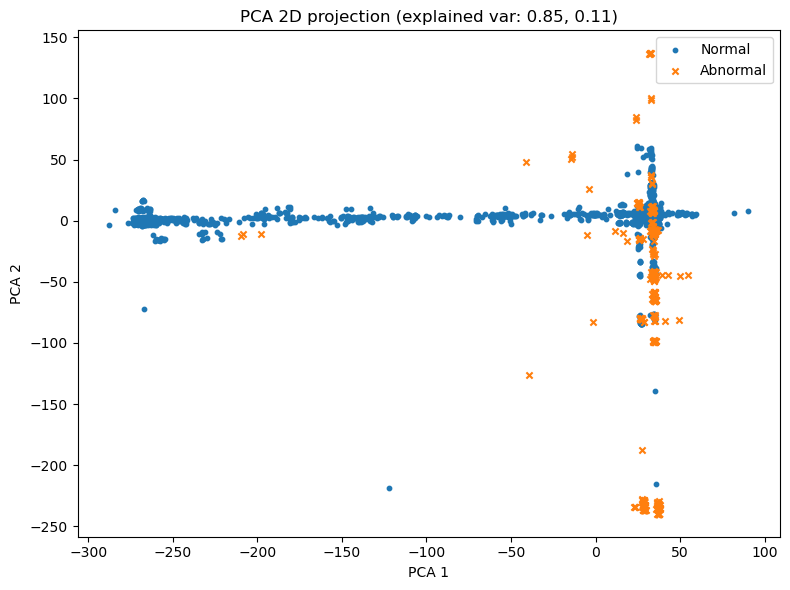

2026-03-22 07:42:44,476 | INFO | capstone.silver_eda | LEDGER | {'ts_utc': '2026-03-22T07:42:44.476644+00:00', 'stage': 'silver_eda', 'recipe': 'silver_eda__v001', 'kind': 'step', 'step': 'pca_2d_projection', 'message': 'Computed PCA(2) projection for separation check.', 'why': None, 'consequence': None, 'data': {'numeric_feature_count': 50, 'rows_used': 8000, 'scaler': 'RobustScaler', 'explained_variance_ratio': [0.8520313514930179, 0.11306601074922507], 'pca_table_path': '/workspace/artifacts/silver_eda/pump/pca_2d__table.csv', 'pca_plot_path': '/workspace/artifacts/silver_eda/pump/pca_2d__scatter.png'}}


In [ ]:


# Collect numeric feature columns that exist
numeric_feature_columns = []
for feature_name in FEATURE_COLUMNS:
    if feature_name in dataframe.columns and pd.api.types.is_numeric_dtype(dataframe[feature_name]):
        numeric_feature_columns.append(feature_name)

if len(numeric_feature_columns) == 0:
    logger.info("No numeric feature columns available for PCA.")
else:
    modeling_frame = dataframe[numeric_feature_columns + (["anomaly_flag"] if "anomaly_flag" in dataframe.columns else [])].copy()

    # Optional sampling (keeps PCA fast)
    if len(modeling_frame) > PCA_SAMPLE_ROW_COUNT:
        modeling_frame = modeling_frame.sample(n=PCA_SAMPLE_ROW_COUNT, random_state=42).reset_index(drop=True)

    feature_matrix = modeling_frame[numeric_feature_columns].copy()

    # Median imputation (simple, stable)
    for feature_name in numeric_feature_columns:
        median_value = float(feature_matrix[feature_name].median(skipna=True))
        feature_matrix[feature_name] = feature_matrix[feature_name].fillna(median_value)

    # Scaling
    scaler = RobustScaler() if USE_ROBUST_SCALER else StandardScaler()
    scaled_matrix = scaler.fit_transform(feature_matrix.values)

    # PCA
    pca_model = PCA(n_components=2, random_state=42)
    pca_values = pca_model.fit_transform(scaled_matrix)

    pca_dataframe = pd.DataFrame({
        "pca_1": pca_values[:, 0],
        "pca_2": pca_values[:, 1],
    })

    if "anomaly_flag" in modeling_frame.columns:
        pca_dataframe["anomaly_flag"] = modeling_frame["anomaly_flag"].astype(int).values
    else:
        pca_dataframe["anomaly_flag"] = 0

    # Save PCA table
    pca_table_path = SILVER_EDA_ARTIFACTS_PATH / "pca_2d__table.csv"
    pca_dataframe.to_csv(pca_table_path, index=False)
    wandb.save(str(pca_table_path))

    # Plot normal and abnormal as separate scatters (matplotlib assigns colors automatically)
    plt.figure(figsize=(8, 6))
    normal_points = pca_dataframe[pca_dataframe["anomaly_flag"] == 0]
    abnormal_points = pca_dataframe[pca_dataframe["anomaly_flag"] == 1]

    plt.scatter(normal_points["pca_1"], normal_points["pca_2"], s=10, label="Normal")
    if len(abnormal_points) > 0:
        plt.scatter(abnormal_points["pca_1"], abnormal_points["pca_2"], s=20, marker="x", label="Abnormal")

    explained = pca_model.explained_variance_ratio_
    plt.title(f"PCA 2D projection (explained var: {explained[0]:.2f}, {explained[1]:.2f})")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.legend()
    plt.tight_layout()

    pca_plot_path = SILVER_EDA_ARTIFACTS_PATH / "pca_2d__scatter.png"
    plt.savefig(pca_plot_path, dpi=200)
    plt.show()
    wandb.save(str(pca_plot_path))

    ledger.add(
        kind="step",
        step="pca_2d_projection",
        message="Computed PCA(2) projection for separation check.",
        data={
            "numeric_feature_count": int(len(numeric_feature_columns)),
            "rows_used": int(len(pca_dataframe)),
            "scaler": "RobustScaler" if USE_ROBUST_SCALER else "StandardScaler",
            "explained_variance_ratio": [float(explained[0]), float(explained[1])],
            "pca_table_path": str(pca_table_path),
            "pca_plot_path": str(pca_plot_path),
        },
        logger=logger,
    )



### Ask

How should I interpret the PCA plot?

### Answer

I should treat it as a quick structure check, not as proof that the classes are perfectly separable.

If normal and abnormal rows show some visible separation, that suggests the feature space contains useful signal. If they overlap heavily, that does not automatically mean the features are useless. It may just mean the separation is more local, nonlinear, or dependent on time context.

So PCA here is a helpful summary view, not the final decision-maker.

----

## Compare Simple Imputation Strategies

This section compares several explainable imputation strategies across the numeric feature set:
- global median
- global mean
- forward fill within ordered groups, then median fallback

The goal is not to declare one strategy universally perfect. The goal is to see which approach best matches the structure of this dataset while staying simple and explainable.

In [ ]:

# Pick numeric features only
numeric_feature_columns = []
for feature_name in FEATURE_COLUMNS:
    if feature_name in dataframe.columns and pd.api.types.is_numeric_dtype(dataframe[feature_name]):
        numeric_feature_columns.append(feature_name)

if len(numeric_feature_columns) == 0:
    logger.info("No numeric feature columns available for imputation comparison.")
else:
    working = dataframe[numeric_feature_columns + (["meta__asset_id", "meta__run_id", "event_step"] if "event_step" in dataframe.columns else [])].copy()

    if len(working) > IMPUTE_SAMPLE_ROW_COUNT:
        working = working.sample(n=IMPUTE_SAMPLE_ROW_COUNT, random_state=42).reset_index(drop=True)

    # Strategy A: median imputation (global)
    median_imputed = working[numeric_feature_columns].copy()
    for feature_name in numeric_feature_columns:
        median_value = float(median_imputed[feature_name].median(skipna=True))
        median_imputed[feature_name] = median_imputed[feature_name].fillna(median_value)

    # Strategy B: mean imputation (global)
    mean_imputed = working[numeric_feature_columns].copy()
    for feature_name in numeric_feature_columns:
        mean_value = float(mean_imputed[feature_name].mean(skipna=True))
        mean_imputed[feature_name] = mean_imputed[feature_name].fillna(mean_value)

    # Strategy C: forward fill within (asset, run) if available, then median
    ffill_imputed = working.copy()
    grouping_columns = []
    if "meta__asset_id" in ffill_imputed.columns:
        grouping_columns.append("meta__asset_id")
    if "meta__run_id" in ffill_imputed.columns:
        grouping_columns.append("meta__run_id")

    if len(grouping_columns) > 0 and "event_step" in ffill_imputed.columns:
        ffill_imputed = ffill_imputed.sort_values(grouping_columns + ["event_step"]).reset_index(drop=True)
        for feature_name in numeric_feature_columns:
            ffill_imputed[feature_name] = ffill_imputed.groupby(grouping_columns, dropna=False)[feature_name].ffill()
    # finish with median for any remaining missing
    for feature_name in numeric_feature_columns:
        median_value = float(ffill_imputed[feature_name].median(skipna=True))
        ffill_imputed[feature_name] = ffill_imputed[feature_name].fillna(median_value)

    # Compare strategies on: percent filled and mean absolute change on originally-missing positions
    comparison_rows = []
    for feature_name in numeric_feature_columns:
        original_series = working[feature_name]
        missing_mask = original_series.isna()

        missing_count = int(missing_mask.sum())
        if missing_count == 0:
            continue

        # Values that got filled at missing positions
        filled_median = median_imputed.loc[missing_mask, feature_name].astype(float)
        filled_mean = mean_imputed.loc[missing_mask, feature_name].astype(float)
        filled_ffill = ffill_imputed.loc[missing_mask, feature_name].astype(float)

        # Compare filled values to the non-missing distribution center (median)
        non_missing = original_series.dropna().astype(float)
        baseline_median = float(non_missing.median()) if len(non_missing) > 0 else 0.0

        median_abs_shift = float((filled_median - baseline_median).abs().mean())
        mean_abs_shift = float((filled_mean - baseline_median).abs().mean())
        ffill_abs_shift = float((filled_ffill - baseline_median).abs().mean())

        comparison_rows.append({
            "feature": feature_name,
            "missing_count": missing_count,
            "missing_percent": float((missing_count / len(working)) * 100.0),
            "baseline_median": baseline_median,
            "median_impute_mean_abs_shift_from_median": median_abs_shift,
            "mean_impute_mean_abs_shift_from_median": mean_abs_shift,
            "ffill_then_median_mean_abs_shift_from_median": ffill_abs_shift,
        })

    impute_compare_table = pd.DataFrame(comparison_rows).sort_values("missing_percent", ascending=False)

    impute_compare_path = SILVER_EDA_ARTIFACTS_PATH / "imputation__comparison.csv"
    impute_compare_table.to_csv(impute_compare_path, index=False)
    wandb.save(str(impute_compare_path))

    # Recommendation logic (simple, explainable)
    # If time-ordered groups exist, ffill+median is often best for time series continuity.
    # Otherwise, median is the safest global method.
    has_groups = ("meta__asset_id" in dataframe.columns) and ("meta__run_id" in dataframe.columns)
    has_event_step = "event_step" in dataframe.columns

    if has_groups and has_event_step:
        recommendation = "forward_fill_within_group_then_median"
        recommendation_reason = (
            "Dataset has (asset,run) grouping and event_step ordering; forward fill preserves short gaps "
            "in time series while median handles leading gaps and long missing runs."
        )
    else:
        recommendation = "global_median"
        recommendation_reason = (
            "Dataset does not clearly support within-group forward fill; global median is robust to outliers "
            "and stable for Isolation Forest and One-Class SVM."
        )

    recommendation_payload = {
        "recommendation": recommendation,
        "reason": recommendation_reason,
        "has_grouping_columns": bool(has_groups),
        "has_event_step": bool(has_event_step),
        "comparison_csv": str(impute_compare_path),
    }

    save_json(recommendation_payload, file_path=SILVER_EDA_ARTIFACTS_PATH, file_name="imputation__recommendation.json")
    wandb.save(str(SILVER_EDA_ARTIFACTS_PATH / "imputation__recommendation.json"))

    ledger.add(
        kind="decision",
        step="imputation_recommendation",
        message="Compared basic imputation strategies and recorded recommendation for Gold layer.",
        data=recommendation_payload,
        logger=logger,
    )

    impute_compare_table.head(15), recommendation_payload

2026-03-22 07:42:45,910 | INFO | capstone.file_io | Saved JSON: /workspace/artifacts/silver_eda/pump/imputation__recommendation.json
2026-03-22 07:42:45,942 | INFO | capstone.silver_eda | LEDGER | {'ts_utc': '2026-03-22T07:42:45.942901+00:00', 'stage': 'silver_eda', 'recipe': 'silver_eda__v001', 'kind': 'decision', 'step': 'imputation_recommendation', 'message': 'Compared basic imputation strategies and recorded recommendation for Gold layer.', 'why': None, 'consequence': None, 'data': {'recommendation': 'forward_fill_within_group_then_median', 'reason': 'Dataset has (asset,run) grouping and event_step ordering; forward fill preserves short gaps in time series while median handles leading gaps and long missing runs.', 'has_grouping_columns': True, 'has_event_step': True, 'comparison_csv': '/workspace/artifacts/silver_eda/pump/imputation__comparison.csv'}}


### Ask

What am I really trying to learn from this imputation comparison?

### Answer

I want to know which simple strategy makes the most sense for this dataset’s structure.

For a time-ordered grouped dataset like this one, forward fill within the correct group may preserve short gaps better than a pure global fill. But I still want a fallback method for leading gaps or cases where that grouped structure is not enough.

So this comparison is helping me justify a practical Gold imputation choice instead of choosing one by habit.

----

In [ ]:
dataframe.columns

Index(['meta__asset_id', 'meta__dataset', 'meta__episode_id', 'meta__event_id', 'meta__ingested_at_utc', 'meta__parent_truth_hash', 'meta__pipeline_mode', 'meta__record_id', 'meta__run_id',
       'meta__source_file', 'meta__source_row_id', 'meta__split', 'meta__truth_hash', 'event_time', 'event_step', 'time_index', 'event_date', 'anomaly_flag', 'is_anomaly', 'is_normal',
       'status_normal_value', 'sensor_00', 'sensor_01', 'sensor_02', 'sensor_03', 'sensor_04', 'sensor_05', 'sensor_06', 'sensor_07', 'sensor_08', 'sensor_09', 'sensor_10', 'sensor_11', 'sensor_12',
       'sensor_13', 'sensor_14', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21', 'sensor_22', 'sensor_23', 'sensor_24', 'sensor_25', 'sensor_26', 'sensor_27',
       'sensor_28', 'sensor_29', 'sensor_30', 'sensor_31', 'sensor_32', 'sensor_33', 'sensor_34', 'sensor_35', 'sensor_36', 'sensor_37', 'sensor_38', 'sensor_39', 'sensor_40', 'sensor_41',
       'sensor_42', 'sensor_43', 'sensor_44', 's

----

## Revisit the Dropped Sensors from Silver Pre-EDA

This section looks back at the sensors that were quarantined or dropped earlier in Silver Pre-EDA.

I am doing this because dropping a feature in preprocessing does not automatically mean it has no interesting behavior. It just means it was not retained in the final Silver feature set. By profiling the dropped sensors here, I can still document what they looked like and whether they showed any useful state-specific patterns.

In [ ]:
# ---------------------------
# 1) Load Silver Pre-EDA truth and dropped parquet
# ---------------------------

SILVER_PREEDA_TRUTH_HASH = get_truth_hash(silver_truth)

silver_preeda_truth = load_truth_record_by_hash(
    truth_dir=TRUTHS_PATH,
    layer_name="silver",
    dataset_name=DATASET_NAME,
    truth_hash=str(SILVER_PREEDA_TRUTH_HASH).strip(),
)

print("Loaded truth record layer_name:", silver_preeda_truth.get("layer_name"))
print("Loaded truth hash:", silver_preeda_truth.get("truth_hash"))
print("Loaded parent truth hash:", silver_preeda_truth.get("parent_truth_hash"))
print("Artifact paths keys:", list((silver_preeda_truth.get("artifact_paths", {}) or {}).keys()))
print("Runtime facts keys:", list((silver_preeda_truth.get("runtime_facts", {}) or {}).keys()))
print("Sensor drop audit:", (silver_preeda_truth.get("runtime_facts", {}) or {}).get("sensor_drop_audit", {}))

Loaded truth record layer_name: silver
Loaded truth hash: 150ec91684fac04d2ee1c41c1b9297bde4fcd92fa30a2f7fe5bcb2129fb76a22
Loaded parent truth hash: 2b8644b616dda6148777160805e0e8cfba5a2aaf08fc568f0adbb09d873ba557
Artifact paths keys: ['bronze_source_path', 'feature_registry_dir', 'silver_output_dir', 'silver_output_file_name', 'silver_preeda_dropped_sensors_parquet', 'silver_preeda_dropped_sensors_path']
Runtime facts keys: ['canonical_info', 'cleaning_recipe_id', 'dataset_name_from_parent_truth', 'dataset_validation', 'feature_set', 'label_resolution', 'missingness_quarantine', 'parent_layer_name', 'parent_truth_hash', 'processed_at_utc', 'quality_info', 'sensor_drop_audit', 'silver_version', 'source_run_ids']
Sensor drop audit: {'drop_reasons': {'sensor_15': 'all_null', 'sensor_50': 'missing_rate_above_threshold'}, 'dropped_features': ['sensor_15', 'sensor_50'], 'dropped_missing_pct': {'sensor_15': 100.0, 'sensor_50': 34.95688090050835}, 'kept_features': ['sensor_00', 'sensor_01', '

In [ ]:

drop_audit = (silver_preeda_truth.get("runtime_facts", {}) or {}).get("sensor_drop_audit", {}) or {}
dropped_sensors = drop_audit.get("dropped_features", []) or []

dropped_parquet_path = (silver_preeda_truth.get("artifact_paths", {}) or {}).get("silver_preeda_dropped_sensors_parquet")

print("Silver Pre-EDA truth hash:", SILVER_PREEDA_TRUTH_HASH)
print("Dropped sensors:", dropped_sensors)
print("Dropped parquet path:", dropped_parquet_path)


Silver Pre-EDA truth hash: 150ec91684fac04d2ee1c41c1b9297bde4fcd92fa30a2f7fe5bcb2129fb76a22
Dropped sensors: ['sensor_15', 'sensor_50']
Dropped parquet path: /workspace/artifacts/silver/pump/pump__silver_preeda__dropped_sensors.parquet


In [ ]:

HAS_DROPPED = bool(dropped_sensors) and bool(dropped_parquet_path)

if not HAS_DROPPED:
    print("No dropped sensors detected; skipped dropped-sensor profiling.")
else:
    dropped_df = pd.read_parquet(Path(dropped_parquet_path))
    print("Dropped df shape:", dropped_df.shape)
    JOIN_KEY = "meta__record_id"

    # ---------------------------
    # 2) Attach state column to dropped_df using meta__record_id
    # ---------------------------
    if JOIN_KEY not in dropped_df.columns:
        raise KeyError(f"Dropped parquet missing '{JOIN_KEY}'. Pre-EDA must save dropped parquet with meta__record_id.")

    if JOIN_KEY not in dataframe.columns:
        raise KeyError(f"Silver EDA dataframe missing '{JOIN_KEY}'. Can't align dropped rows to states.")

    # Resolve the state column exactly like your Silver EDA does
    FALLBACK_STATE_COL = "machine_status"
    label_resolution = (silver_truth.get("runtime_facts", {}) or {}).get("label_resolution", {}) or {}
    truth_state_col = label_resolution.get("label_source_column")

    state_col = str(truth_state_col).strip() if truth_state_col and str(truth_state_col).strip() else FALLBACK_STATE_COL
    if state_col not in dataframe.columns:
        raise KeyError(f"Resolved state_col='{state_col}' not found in Silver EDA dataframe columns.")

    # Merge the state col onto the dropped sensors df
    state_df = dataframe[[JOIN_KEY, state_col]].drop_duplicates(subset=[JOIN_KEY]).copy()
    dropped_df = dropped_df.merge(state_df, on=JOIN_KEY, how="left")

    # Build state_col_synth for dropped_df
    state_col_synth = f"{state_col}__synthetic"
    state_map = {"normal": "normal", "broken": "abnormal", "recovering": "recovery"}

    dropped_df[state_col_synth] = (
        dropped_df[state_col]
        .astype(str)
        .str.strip()
        .str.lower()
        .map(state_map)
    )

    unmapped = dropped_df[state_col_synth].isna()
    dropped_df.loc[unmapped, state_col_synth] = (
        dropped_df.loc[unmapped, state_col]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    print("Dropped synthetic states:", sorted(dropped_df[state_col_synth].dropna().unique()))

    # ---------------------------
    # 3) Profiling Function, same as above
    # ---------------------------

    def profile_sensor_state_table(
        df: pd.DataFrame,
        *,
        sensors: list[str],
        state_values: list[str],
    ) -> pd.DataFrame:
        rows = []

        for state in state_values:
            w = df.loc[df[state_col_synth].astype(str) == str(state)].copy()

            for sensor in sensors:
                if sensor not in w.columns:
                    continue
                if not pd.api.types.is_numeric_dtype(w[sensor]):
                    continue

                series_raw = pd.to_numeric(w[sensor], errors="coerce").replace([np.inf, -np.inf], np.nan)
                missing_pct = float(series_raw.isna().mean() * 100.0)

                series = series_raw.dropna()
                if series.empty:
                    # safeguard: still record sensor & missing pct for this state
                    rows.append({
                        "sensor": sensor,
                        "state_scope": state,
                        "count": 0,
                        "missing_pct": missing_pct,
                        "mean": np.nan,
                        "std": np.nan,
                        "min": np.nan,
                        "max": np.nan,
                        "median": np.nan,
                        "iqr": np.nan,
                        "p01": np.nan,
                        "p05": np.nan,
                        "p25": np.nan,
                        "p50": np.nan,
                        "p75": np.nan,
                        "p95": np.nan,
                        "p99": np.nan,
                        "skewness": np.nan,
                        "kurtosis": np.nan,
                        "robust_std": np.nan,
                        "distribution_family": "no_values",
                        "lower_bound": np.nan,
                        "upper_bound": np.nan,
                    })
                    continue

                p25 = float(series.quantile(0.25))
                p75 = float(series.quantile(0.75))
                iqr = float(p75 - p25)
                robust_std = float(iqr / 1.349) if iqr > 0 else 0.0

                p01 = float(series.quantile(0.01))
                p99 = float(series.quantile(0.99))

                skewness = float(scipy_skew(series.values, bias=False)) if series.shape[0] > 2 else np.nan
                kurt = float(scipy_kurtosis(series.values, bias=False, fisher=True)) if series.shape[0] > 3 else np.nan

                std_val = float(series.std(ddof=1)) if series.shape[0] > 1 else 0.0

                if std_val <= 1e-8:
                    family = "near_constant"
                elif np.isfinite(skewness) and skewness >= 1.0:
                    family = "right_skewed"
                elif np.isfinite(skewness) and skewness <= -1.0:
                    family = "left_skewed"
                else:
                    family = "bounded_normal"

                rows.append({
                    "sensor": sensor,
                    "state_scope": state,
                    "count": int(series.shape[0]),
                    "missing_pct": missing_pct,
                    "mean": float(series.mean()),
                    "std": std_val,
                    "min": float(series.min()),
                    "max": float(series.max()),
                    "median": float(series.median()),
                    "iqr": iqr,
                    "p01": p01,
                    "p05": float(series.quantile(0.05)),
                    "p25": p25,
                    "p50": float(series.quantile(0.50)),
                    "p75": p75,
                    "p95": float(series.quantile(0.95)),
                    "p99": p99,
                    "skewness": skewness,
                    "kurtosis": kurt,
                    "robust_std": robust_std,
                    "distribution_family": family,
                    "lower_bound": p01,
                    "upper_bound": p99,
                })

        return pd.DataFrame(rows)
    
    # ---------------------------
    # 4) Run profiling + save artifacts
    # ---------------------------
    dropped_present = [s for s in dropped_sensors if s in dropped_df.columns]
    if not dropped_present:
        raise ValueError("Dropped parquet contains none of the dropped sensors from truth.")

    state_list = ["normal", "abnormal", "recovery"]
    dropped_profiles_df = profile_sensor_state_table(
        dropped_df,
        sensors=dropped_present,
        state_values=state_list,
    )

    out_dir = SILVER_EDA_ARTIFACTS_PATH
    out_dir.mkdir(parents=True, exist_ok=True)

    dropped_profile_paths = {}

    combined_path = out_dir / f"{DATASET_NAME}__silver_eda__dropped_feature_profiles__all_states.csv"
    dropped_profiles_df.to_csv(combined_path, index=False)
    dropped_profile_paths["dropped_feature_profiles_all_states_path"] = str(combined_path)

    for state in state_list:
        sub = dropped_profiles_df.loc[dropped_profiles_df["state_scope"] == state].copy()
        p = out_dir / f"{DATASET_NAME}__silver_eda__dropped_feature_profiles__{state}.csv"
        sub.to_csv(p, index=False)
        dropped_profile_paths[f"dropped_feature_profiles_{state}_path"] = str(p)

    print("Saved dropped profiles:", combined_path)
    display(dropped_profiles_df.head(20))

    # ---------------------------
    # 5) Truth store: add artifact paths
    # ---------------------------
    '''
    silver_truth = update_truth_section(
        silver_truth,
        "artifact_paths",
        {
            "dropped_sensors_parquet_path": str(dropped_parquet_path),
            "dropped_feature_profiles_all_states_path": dropped_profile_paths["dropped_feature_profiles_all_states_path"],
            "dropped_feature_profiles_normal_path": dropped_profile_paths["dropped_feature_profiles_normal_path"],
            "dropped_feature_profiles_abnormal_path": dropped_profile_paths["dropped_feature_profiles_abnormal_path"],
            "dropped_feature_profiles_recovery_path": dropped_profile_paths["dropped_feature_profiles_recovery_path"],
        },
    )
    '''

Dropped df shape: (220320, 3)
Dropped synthetic states: ['abnormal', 'normal', 'recovery']
Saved dropped profiles: /workspace/artifacts/silver_eda/pump/pump__silver_eda__dropped_feature_profiles__all_states.csv


,sensor,state_scope,count,missing_pct,mean,std,min,max,median,iqr,p01,p05,p25,p50,p75,p95,p99,skewness,kurtosis,robust_std,distribution_family,lower_bound,upper_bound
0,sensor_15,normal,0,100.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no_values,NaN,NaN
1,sensor_50,normal,128900,37.377330,199.021829,45.394732,30.960650,1000.0000,198.49540,46.585700,41.087963,140.625000,176.504600,198.49540,223.090300,266.203700,297.164300,1.369689,36.300624,34.533506,right_skewed,41.087963,297.164300
2,sensor_15,abnormal,0,100.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no_values,NaN,NaN
3,sensor_50,abnormal,6,14.285714,211.757318,119.274664,32.407406,401.9097,206.16320,58.449100,39.670136,68.721054,181.278900,206.16320,239.728000,362.991875,394.126135,0.194633,1.860477,43.327724,bounded_normal,39.670136,394.126135
4,sensor_15,recovery,0,100.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no_values,NaN,NaN
5,sensor_50,recovery,14397,0.552601,40.030832,34.583243,27.488426,483.5069,32.98611,6.944445,27.777779,28.067129,30.381945,32.98611,37.326389,67.129630,195.138844,7.719838,71.778119,5.147846,right_skewed,27.777779,195.138844


In [ ]:
silver_truth

{'artifact_paths': {'bronze_source_path': '/workspace/data/bronze/train/pump__bronze__train.parquet',
  'feature_registry_dir': '/workspace/artifacts/silver/pump',
  'silver_output_dir': '/workspace/data/silver/train',
  'silver_output_file_name': 'pump__silver__train.parquet',
  'silver_preeda_dropped_sensors_parquet': '/workspace/artifacts/silver/pump/pump__silver_preeda__dropped_sensors.parquet',
  'silver_preeda_dropped_sensors_path': '/workspace/artifacts/silver/pump/pump__silver_preeda__dropped_sensors.parquet'},
 'column_count': 73,
 'config_snapshot': {'cleaning_recipe_id': 'silver__clean__dataset__agnostic__v001',
  'dataset_name_config': 'pump',
  'dataset_name_parent_truth': 'pump',
  'min_step_parse_success_percent': 95.0,
  'min_time_parse_success_percent': 95.0,
  'pipeline_mode': 'batch',
  'quarantine_missing_pct': 30.0,
  'run_id_default_fallback': 'run__001',
  'silver_version': 'silver__001'},
 'created_at_utc': '2026-03-22T01:15:03+00:00',
 'dataset_name': 'pump',
 

### Ask

Why bother profiling dropped sensors if they were already removed from the main feature set?

### Answer

Because feature removal and feature irrelevance are not always the same thing.

A sensor may be dropped for missingness or stability reasons and still show recognizable behavior by state. That can still be useful for documentation, future tuning, or synthetic-data planning.

So this section helps preserve the reasoning around what was dropped instead of making those columns disappear without explanation.

----

## Define a Helper to Read Episode-State Summary Details from Truth

This helper function pulls the saved episode-state summary payload back out of the Silver EDA truth record.

The reason I like having this helper is that it makes the saved truth artifact easier to inspect later without having to manually dig through nested JSON every time.

In [ ]:
def pull_episode_status_state_stats_from_truth(truth_record: dict) -> dict:
    runtime_facts = (truth_record or {}).get("runtime_facts", {}) or {}
    artifact_paths = (truth_record or {}).get("artifact_paths", {}) or {}

    payload = runtime_facts.get("episode_status_state_stats", {}) or {}
    episode_status_counts_path = artifact_paths.get("episode_status_counts_path")

    episode_status_counts_records = []
    if episode_status_counts_path:
        path_obj = Path(episode_status_counts_path)
        if path_obj.exists():
            with open(path_obj, "r", encoding="utf-8") as file:
                episode_status_counts_records = json.load(file)

    return {
        "status_column": payload.get("status_column"),
        "episode_column": payload.get("episode_column"),
        "episode_count": int(payload.get("episode_count", 0) or 0),
        "mean_total_rows_per_episode": float(
            payload.get("mean_total_rows_per_episode", 0.0) or 0.0
        ),
        "global_status_stats": payload.get("global_status_stats", []) or [],
        "episode_status_means": payload.get("episode_status_means", []) or [],
        "episode_status_percent_means": payload.get("episode_status_percent_means", []) or [],
        "episode_totals": payload.get("episode_totals", []) or [],
        "episode_status_mean_lookup": payload.get("episode_status_mean_lookup", {}) or {},
        "episode_status_percent_mean_lookup": payload.get("episode_status_percent_mean_lookup", {}) or {},
        "global_status_count_lookup": payload.get("global_status_count_lookup", {}) or {},
        "global_status_percent_lookup": payload.get("global_status_percent_lookup", {}) or {},
        "episode_status_counts_path": episode_status_counts_path,
        "episode_status_counts_records": episode_status_counts_records,
    }

## Finalize the Silver EDA Ledger and Save the Silver EDA Truth Record

Now I wrap the notebook into a formal Silver EDA artifact set.

This section does several important things:
- saves the ledger
- builds the Silver EDA truth record
- records runtime facts
- records the paths to the generated artifacts
- saves the truth record
- appends the truth index
- closes the W&B run

At this point, the EDA notebook output becomes more than just charts and tables inside the notebook. It becomes a tracked pipeline artifact.

In [ ]:
ledger_path = SILVER_EDA_ARTIFACTS_PATH / f"ledger__{DATASET_NAME}__{STAGE}.json"

ledger.add(
    kind="step",
    step="finalize",
    message="Saved Silver EDA ledger and finalized W&B run.",
    data={"ledger_path": str(ledger_path)},
    logger=logger,
)

ledger.write_json(ledger_path)

silver_eda_dataset_name = (
    str(DATASET_NAME).strip().lower()
    if DATASET_NAME is not None
    else str(silver_truth.get("dataset_name", "pump")).strip().lower()
)

silver_eda_process_run_id = (
    SILVER_PROCESS_RUN_ID
    if "SILVER_PROCESS_RUN_ID" in globals()
    else make_process_run_id("silver_eda_process")
)

silver_eda_truth_layer_name = "silver_eda"

truth_config_snapshot = (
    TRUTH_CONFIG
    if "TRUTH_CONFIG" in globals()
    else {
        "runtime": {
            "stage": "silver_eda",
            "dataset": silver_eda_dataset_name,
            "mode": RUN_MODE if "RUN_MODE" in globals() else None,
            "profile": CONFIG_PROFILE if "CONFIG_PROFILE" in globals() else "default",
        }
    }
)

silver_eda_artifact_files = sorted(
    str(path)
    for path in SILVER_EDA_ARTIFACTS_PATH.glob("*")
    if path.is_file()
)

silver_eda_truth = initialize_layer_truth(
    truth_version=TRUTH_VERSION,
    dataset_name=silver_eda_dataset_name,
    layer_name=silver_eda_truth_layer_name,
    process_run_id=silver_eda_process_run_id,
    pipeline_mode=PIPELINE_MODE,
    parent_truth_hash=SILVER_TRUTH_HASH,
)

silver_eda_truth = update_truth_section(
    silver_eda_truth,
    "config_snapshot",
    truth_config_snapshot,
)

silver_eda_truth = update_truth_section(
    silver_eda_truth,
    "runtime_facts",
    {
        "input_row_count": int(len(dataframe)),
        "input_column_count": int(dataframe.shape[1]),
        "feature_column_count": int(len(FEATURE_COLUMNS)) if "FEATURE_COLUMNS" in globals() else 0,
        "top_feature_count": int(len(TOP_FEATURES)) if "TOP_FEATURES" in globals() else 0,
        "numeric_feature_count": int(len(numeric_feature_columns)) if "numeric_feature_columns" in globals() else 0,
        "max_onsets_used": int(MAX_ONSETS_TO_USE) if "MAX_ONSETS_TO_USE" in globals() else None,
        "pca_sample_row_count": int(PCA_SAMPLE_ROW_COUNT) if "PCA_SAMPLE_ROW_COUNT" in globals() else None,
        "impute_sample_row_count": int(IMPUTE_SAMPLE_ROW_COUNT) if "IMPUTE_SAMPLE_ROW_COUNT" in globals() else None,
        "parent_truth_hash": SILVER_TRUTH_HASH,
        "episode_status_state_stats": (
            EPISODE_STATUS_STATE_STATS_PAYLOAD
                if "EPISODE_STATUS_STATE_STATS_PAYLOAD" in globals()
                else None
        ),
    },
)



artifact_paths_payload = {
    "silver_truth_path": str(SILVER_TRUTH_PATH),
    "silver_eda_artifacts_dir": str(SILVER_EDA_ARTIFACTS_PATH),
    "silver_eda_ledger_path": str(ledger_path),
    "silver_eda_output_files": silver_eda_artifact_files,

    "effect_size_table_path": str(effect_path) if "effect_path" in globals() else None,
    "correlation_table_path": str(corr_path) if "corr_path" in globals() else None,
    "correlation_heatmap_path": str(heatmap_path) if "heatmap_path" in globals() else None,
    "top_feature_overlay_path": str(overlay_path) if "overlay_path" in globals() else None,
    "cluster_table_path": str(cluster_path) if "cluster_path" in globals() else None,
    "anomaly_onsets_path": str(onsets_path) if "onsets_path" in globals() else None,
    "pca_table_path": str(pca_table_path) if "pca_table_path" in globals() else None,
    "pca_plot_path": str(pca_plot_path) if "pca_plot_path" in globals() else None,

    "episode_status_counts_path": str(episode_status_counts_path)
        if "episode_status_counts_path" in globals() else None,

    # Base state profiles
    "feature_profile_normal_path": str(feature_profile_normal_path),
    "feature_profile_abnormal_path": str(feature_profile_abnormal_path),
    "feature_profile_recovery_path": str(feature_profile_recovery_path),

    # Correlation/grouping/pairings
    "sensor_correlation_pairs_normal_path": str(sensor_correlation_pairs_normal_path),
    "sensor_group_map_normal_path": str(sensor_group_map_normal_path),
    "sensor_fault_pairings_normal_path": str(sensor_fault_pairings_normal_path),
}

# Adding dropped-sensor profile artifacts
if "dropped_profile_paths" in globals() and isinstance(dropped_profile_paths, dict):
    artifact_paths_payload.update(dropped_profile_paths)

# Remove None values
artifact_paths_payload = {key: value for key, value in artifact_paths_payload.items() if value is not None}

silver_eda_truth = update_truth_section(
    silver_eda_truth,
    "artifact_paths",
    artifact_paths_payload,
)


silver_eda_truth_record = build_truth_record(
    truth_base=silver_eda_truth,
    row_count=len(dataframe),
    column_count=dataframe.shape[1],
    meta_columns=identify_meta_columns(dataframe),
    feature_columns=identify_feature_columns(dataframe),
)

SILVER_EDA_TRUTH_HASH = silver_eda_truth_record["truth_hash"]

silver_eda_truth_path = save_truth_record(
    silver_eda_truth_record,
    truth_dir=TRUTHS_PATH,
    dataset_name=silver_eda_dataset_name,
    layer_name=silver_eda_truth_layer_name,
)

append_truth_index(
    silver_eda_truth_record,
    truth_index_path=TRUTH_INDEX_PATH,
)

wandb.save(str(ledger_path))
wandb.save(str(silver_eda_truth_path))

logger.info("Silver EDA truth hash: %s", SILVER_EDA_TRUTH_HASH)
logger.info("Silver EDA truth path: %s", silver_eda_truth_path)

print("Silver EDA truth hash:", SILVER_EDA_TRUTH_HASH)
print("Silver EDA truth path:", silver_eda_truth_path)

wandb_run.finish()

2026-03-22 07:42:50,106 | INFO | capstone.silver_eda | LEDGER | {'ts_utc': '2026-03-22T07:42:50.106505+00:00', 'stage': 'silver_eda', 'recipe': 'silver_eda__v001', 'kind': 'step', 'step': 'finalize', 'message': 'Saved Silver EDA ledger and finalized W&B run.', 'why': None, 'consequence': None, 'data': {'ledger_path': '/workspace/artifacts/silver_eda/pump/ledger__pump__silver_eda.json'}}


2026-03-22 07:42:50,736 | INFO | capstone.silver_eda | Silver EDA truth hash: dcb25577bcf8156ab2ad2a3f32f5f0943be6644f304b8c570928280787490fc8
2026-03-22 07:42:50,739 | INFO | capstone.silver_eda | Silver EDA truth path: /workspace/artifacts/truths/silver_eda/pump__silver_eda__truth__dcb25577bcf8156ab2ad2a3f32f5f0943be6644f304b8c570928280787490fc8.json


Silver EDA truth hash: dcb25577bcf8156ab2ad2a3f32f5f0943be6644f304b8c570928280787490fc8
Silver EDA truth path: /workspace/artifacts/truths/silver_eda/pump__silver_eda__truth__dcb25577bcf8156ab2ad2a3f32f5f0943be6644f304b8c570928280787490fc8.json


feature_registry_keys,▁
silver_cols,▁
silver_rows,▁
feature_registry_keys,17
silver_cols,73
silver_rows,220320


----

## Review the Saved Episode-State Summary from the Silver EDA Truth Record

After saving the Silver EDA truth record, I pull the episode-state summary back out so I can review the stored defaults and counts directly from the saved artifact.

This is a useful final check because it confirms that the episode-state information I built earlier was actually preserved in the truth record the way I expected.

In [ ]:
episode_status_payload = pull_episode_status_state_stats_from_truth(silver_eda_truth)

mean_row_lookup = episode_status_payload["episode_status_mean_lookup"]
mean_percent_lookup = episode_status_payload["episode_status_percent_mean_lookup"]

normal_rows_default = int(round(mean_row_lookup.get("NORMAL", 0)))
broken_rows_default = int(round(mean_row_lookup.get("BROKEN", 1)))
recovering_rows_default = int(round(mean_row_lookup.get("RECOVERING", 0)))

normal_percent_default = float(mean_percent_lookup.get("NORMAL", 0.0))
broken_percent_default = float(mean_percent_lookup.get("BROKEN", 0.0))
recovering_percent_default = float(mean_percent_lookup.get("RECOVERING", 0.0))

In [ ]:
episode_status_payload = pull_episode_status_state_stats_from_truth(silver_eda_truth_record)

episode_status_counts_df = pd.DataFrame(
    episode_status_payload["episode_status_counts_records"]
)

display(episode_status_counts_df)

,meta__episode_id,normal,normal_percent,failure,failure_percent,recovery,recovery_percent,episode_total_rows
0,0,17155,0.947790,1,0.000055,944,0.052155,18100
1,1,6410,0.673249,1,0.000105,3110,0.326646,9521
2,2,41697,0.969472,1,0.000023,1312,0.030505,43010
3,3,7159,0.921958,1,0.000129,605,0.077914,7765
4,4,49644,0.855415,1,0.000017,8390,0.144568,58035
5,5,4700,0.991143,1,0.000211,41,0.008646,4742
6,6,25267,0.997001,1,0.000039,75,0.002959,25343
7,7,53804,1.000000,0,0.000000,0,0.000000,53804


### Ask

What does this final truth-based review confirm?

### Answer

It confirms that the exploratory outputs were not only computed in the notebook, but also preserved in the saved Silver EDA artifact record.

That matters because I want the key EDA findings and support tables to stay traceable and reusable later, especially when they feed into Gold decisions or the project write-up.

So this is both a trust check and a reusability check.

----

## Optional PostgreSQL Write for Silver EDA Outputs

This section is for writing the Silver EDA dataframe into PostgreSQL.

I am treating this as an optional persistence step rather than part of the core Silver EDA deliverable. The main outputs from this notebook are still the saved EDA artifacts, tables, plots, ledger, and Silver EDA truth record. Writing to SQL is useful when I want the Silver EDA artifact available for querying, validation, or downstream integration work.

SQL_SCHEMAS = {
    "bronze": "bronze",
    "silver": "silver",
    "gold": "gold",
    "synthetic": "synthetic",
    "truth": "truth",
    "audit": "audit",
}

GOLD_ARTIFACT_TABLES = {
    "baseline_results": "baseline_results",
    "baseline_summary": "baseline_summary",
    "baseline_thresholds": "baseline_thresholds",
    "cascade_results": "cascade_results",
    "cascade_summary": "cascade_summary",
    "cascade_thresholds": "cascade_thresholds",
    "comparison_summary": "comparison_summary",
}

SYNTHETIC_ARTIFACT_TABLES = {
    "batch": "batch",
    "stream": "stream",
    "sensor_messages": "sensor_messages",
}

SILVER_SCHEMA = SQL_SCHEMAS["silver"]

engine = get_engine_from_env()

silver_sql_dataframe = prepare_layer_dataframe(
    dataframe,
    truth_hash=SILVER_TRUTH_HASH,
    parent_truth_hash=SILVER_PARENT_TRUTH_HASH,
    pipeline_mode=PIPELINE_MODE,
    process_run_id=SILVER_PROCESS_RUN_ID,
    add_loaded_at_column=True,
)

silver_table_name = write_layer_dataframe(
    engine=engine,
    dataframe=silver_sql_dataframe,
    schema=SILVER_SCHEMA,
    dataset_name=DATASET_NAME,
    if_exists="replace",
    index=False,
)

print(f"Wrote table: {SILVER_SCHEMA}.{silver_table_name}.eda")